In [22]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 — LOAD ROUND 5 DATA
# ════════════════════════════════════════════════════════════════════════════

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROUND = 5
DAYS = [2, 3, 4]

DATA_DIR = Path("Data/round5")

ALGO_PRODUCTS = [
    # Galaxy Sounds Recorders
    "GALAXY_SOUNDS_DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES",

    # Vertical Sleeping Pods
    "SLEEP_POD_SUEDE",
    "SLEEP_POD_LAMB_WOOL",
    "SLEEP_POD_POLYESTER",
    "SLEEP_POD_NYLON",
    "SLEEP_POD_COTTON",

    # Organic Microchips
    "MICROCHIP_CIRCLE",
    "MICROCHIP_OVAL",
    "MICROCHIP_SQUARE",
    "MICROCHIP_RECTANGLE",
    "MICROCHIP_TRIANGLE",

    # Purification Pebbles
    "PEBBLES_XS",
    "PEBBLES_S",
    "PEBBLES_M",
    "PEBBLES_L",
    "PEBBLES_XL",

    # Domestic Robots
    "ROBOT_VACUUMING",
    "ROBOT_MOPPING",
    "ROBOT_DISHES",
    "ROBOT_LAUNDRY",
    "ROBOT_IRONING",

    # UV-Visors
    "UV_VISOR_YELLOW",
    "UV_VISOR_AMBER",
    "UV_VISOR_ORANGE",
    "UV_VISOR_RED",
    "UV_VISOR_MAGENTA",

    # Instant Translators
    "TRANSLATOR_SPACE_GRAY",
    "TRANSLATOR_ASTRO_BLACK",
    "TRANSLATOR_ECLIPSE_CHARCOAL",
    "TRANSLATOR_GRAPHITE_MIST",
    "TRANSLATOR_VOID_BLUE",

    # Construction Panels
    "PANEL_1X2",
    "PANEL_2X2",
    "PANEL_1X4",
    "PANEL_2X4",
    "PANEL_4X4",

    # Liquid Breath Oxygen Shakes
    "OXYGEN_SHAKE_MORNING_BREATH",
    "OXYGEN_SHAKE_EVENING_BREATH",
    "OXYGEN_SHAKE_MINT",
    "OXYGEN_SHAKE_CHOCOLATE",
    "OXYGEN_SHAKE_GARLIC",

    # Protein Snack Packs
    "SNACKPACK_CHOCOLATE",
    "SNACKPACK_VANILLA",
    "SNACKPACK_PISTACHIO",
    "SNACKPACK_STRAWBERRY",
    "SNACKPACK_RASPBERRY",
]

POSITION_LIMITS = {product: 10 for product in ALGO_PRODUCTS}

prices_parts = []
trades_parts = []

for day in DAYS:
    price_path = DATA_DIR / f"prices_round_{ROUND}_day_{day}.csv"
    trade_path = DATA_DIR / f"trades_round_{ROUND}_day_{day}.csv"

    p = pd.read_csv(price_path, sep=";")
    t = pd.read_csv(trade_path, sep=";")

    p["file_day"] = day
    t["file_day"] = day

    prices_parts.append(p)
    trades_parts.append(t)

prices = pd.concat(prices_parts, ignore_index=True)
trades = pd.concat(trades_parts, ignore_index=True)

# Standardise trade product column name.
if "symbol" in trades.columns and "product" not in trades.columns:
    trades = trades.rename(columns={"symbol": "product"})

# Keep only valid Round 5 algorithmic products.
prices = prices[prices["product"].isin(ALGO_PRODUCTS)].copy()
trades = trades[trades["product"].isin(ALGO_PRODUCTS)].copy()

# Useful global time index across days.
# Assumes timestamp resets each day.
min_day = min(DAYS)
prices["global_ts"] = (prices["file_day"] - min_day) * 1_000_000 + prices["timestamp"]
trades["global_ts"] = (trades["file_day"] - min_day) * 1_000_000 + trades["timestamp"]

prices = prices.sort_values(["product", "global_ts"]).reset_index(drop=True)
trades = trades.sort_values(["product", "global_ts"]).reset_index(drop=True)

# Basic sanity checks.
price_products = sorted(prices["product"].unique())
trade_products = sorted(trades["product"].unique())

missing_in_prices = sorted(set(ALGO_PRODUCTS) - set(price_products))
missing_in_trades = sorted(set(ALGO_PRODUCTS) - set(trade_products))

print("prices shape:", prices.shape)
print("trades shape:", trades.shape)
print()
print("Price products:", price_products)
print("Trade products:", trade_products)
print()
print("Missing in prices:", missing_in_prices)
print("Missing in trades:", missing_in_trades)
print()
print("Price days:", sorted(prices["file_day"].unique()))
print("Trade days:", sorted(trades["file_day"].unique()))
print()
print("Position limits:", POSITION_LIMITS)

display(prices.head())
display(trades.head())

prices shape: (1500000, 19)
trades shape: (35385, 9)

Price products: ['GALAXY_SOUNDS_BLACK_HOLES', 'GALAXY_SOUNDS_DARK_MATTER', 'GALAXY_SOUNDS_PLANETARY_RINGS', 'GALAXY_SOUNDS_SOLAR_FLAMES', 'GALAXY_SOUNDS_SOLAR_WINDS', 'MICROCHIP_CIRCLE', 'MICROCHIP_OVAL', 'MICROCHIP_RECTANGLE', 'MICROCHIP_SQUARE', 'MICROCHIP_TRIANGLE', 'OXYGEN_SHAKE_CHOCOLATE', 'OXYGEN_SHAKE_EVENING_BREATH', 'OXYGEN_SHAKE_GARLIC', 'OXYGEN_SHAKE_MINT', 'OXYGEN_SHAKE_MORNING_BREATH', 'PANEL_1X2', 'PANEL_1X4', 'PANEL_2X2', 'PANEL_2X4', 'PANEL_4X4', 'PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XL', 'PEBBLES_XS', 'ROBOT_DISHES', 'ROBOT_IRONING', 'ROBOT_LAUNDRY', 'ROBOT_MOPPING', 'ROBOT_VACUUMING', 'SLEEP_POD_COTTON', 'SLEEP_POD_LAMB_WOOL', 'SLEEP_POD_NYLON', 'SLEEP_POD_POLYESTER', 'SLEEP_POD_SUEDE', 'SNACKPACK_CHOCOLATE', 'SNACKPACK_PISTACHIO', 'SNACKPACK_RASPBERRY', 'SNACKPACK_STRAWBERRY', 'SNACKPACK_VANILLA', 'TRANSLATOR_ASTRO_BLACK', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_GRAPHITE_MIST', 'TRANSLATOR_SPACE_GRAY'

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,file_day,global_ts
0,2,0,GALAXY_SOUNDS_BLACK_HOLES,9994,22,9992.0,26.0,NaN,NaN,10006,22,10008.0,26.0,NaN,NaN,10000.0,0.0,2,0
1,2,100,GALAXY_SOUNDS_BLACK_HOLES,10001,18,10000.0,25.0,NaN,NaN,10014,18,10016.0,25.0,NaN,NaN,10007.5,0.0,2,100
2,2,200,GALAXY_SOUNDS_BLACK_HOLES,9996,19,9995.0,31.0,NaN,NaN,10009,19,10011.0,31.0,NaN,NaN,10002.5,0.0,2,200
3,2,300,GALAXY_SOUNDS_BLACK_HOLES,9994,25,9993.0,33.0,NaN,NaN,10007,25,10009.0,33.0,NaN,NaN,10000.5,0.0,2,300
4,2,400,GALAXY_SOUNDS_BLACK_HOLES,9999,14,9997.0,32.0,NaN,NaN,10012,14,10013.0,32.0,NaN,NaN,10005.5,0.0,2,400


,timestamp,buyer,seller,product,currency,price,quantity,file_day,global_ts
0,1700,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9969.0,4,2,1700
1,14500,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9749.0,1,2,14500
2,15100,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9764.0,2,2,15100
3,26500,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9656.0,4,2,26500
4,36400,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9675.0,4,2,36400


galaxy_mid shape: (30000, 5)


product             GALAXY_SOUNDS_DARK_MATTER  GALAXY_SOUNDS_BLACK_HOLES  \
file_day timestamp                                                         
2        0                            10000.0                    10000.0   
         100                           9988.5                    10007.5   
         200                          10003.5                    10002.5   
         300                           9994.5                    10000.5   
         400                           9986.5                    10005.5   

product             GALAXY_SOUNDS_PLANETARY_RINGS  GALAXY_SOUNDS_SOLAR_WINDS  \
file_day timestamp                                                             
2        0                                10000.0                    10000.0   
         100                               9988.5                    10000.5   
         200                               9995.5                    10007.5   
         300                               9997.5                    10021.5   
         400                              10008.5                    10013.5   

product             GALAXY_SOUNDS_SOLAR_FLAMES  
file_day timestamp                              
2        0                             10000.0  
         100                           10002.5  
         200                           10003.5  
         300                           10012.5  
         400                           10012.5

,day,product,start,end,drift,min,max,range,diff_std,mean_abs_diff,max_abs_diff
0,2,GALAXY_SOUNDS_DARK_MATTER,10000.0,10417.0,417.0,9614.0,10695.0,1081.0,10.067367,8.017502,36.5
1,2,GALAXY_SOUNDS_BLACK_HOLES,10000.0,11446.5,1446.5,9608.5,11791.5,2183.0,10.597998,8.416992,44.0
2,2,GALAXY_SOUNDS_PLANETARY_RINGS,10000.0,11249.0,1249.0,9253.0,11279.0,2026.0,10.157218,8.128113,46.0
3,2,GALAXY_SOUNDS_SOLAR_WINDS,10000.0,9583.5,-416.5,9320.0,10992.0,1672.0,10.231221,8.146465,41.5
4,2,GALAXY_SOUNDS_SOLAR_FLAMES,10000.0,11345.5,1345.5,9837.5,11970.5,2133.0,11.116588,8.866737,43.0
5,3,GALAXY_SOUNDS_DARK_MATTER,10409.5,10872.0,462.5,9662.0,11186.0,1524.0,10.482851,8.380388,40.0
6,3,GALAXY_SOUNDS_BLACK_HOLES,11444.5,12133.0,688.5,10592.0,12220.0,1628.0,11.125828,8.837434,50.0
7,3,GALAXY_SOUNDS_PLANETARY_RINGS,11249.5,11407.5,158.0,11100.0,12182.0,1082.0,11.635062,9.233523,47.0
8,3,GALAXY_SOUNDS_SOLAR_WINDS,9591.5,10767.0,1175.5,9372.0,11325.5,1953.5,10.374702,8.275778,40.5
9,3,GALAXY_SOUNDS_SOLAR_FLAMES,11338.5,10645.0,-693.5,10367.5,12210.0,1842.5,11.226610,8.955446,42.0


Same-time diff correlation across all Galaxy products:


product,GALAXY_SOUNDS_DARK_MATTER,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_PLANETARY_RINGS,GALAXY_SOUNDS_SOLAR_WINDS,GALAXY_SOUNDS_SOLAR_FLAMES
product,,,,,
GALAXY_SOUNDS_DARK_MATTER,1.000000,0.000048,0.006470,-0.001073,0.004279
GALAXY_SOUNDS_BLACK_HOLES,0.000048,1.000000,0.001581,0.010315,0.002143
GALAXY_SOUNDS_PLANETARY_RINGS,0.006470,0.001581,1.000000,0.000015,0.013676
GALAXY_SOUNDS_SOLAR_WINDS,-0.001073,0.010315,0.000015,1.000000,0.004200
GALAXY_SOUNDS_SOLAR_FLAMES,0.004279,0.002143,0.013676,0.004200,1.000000


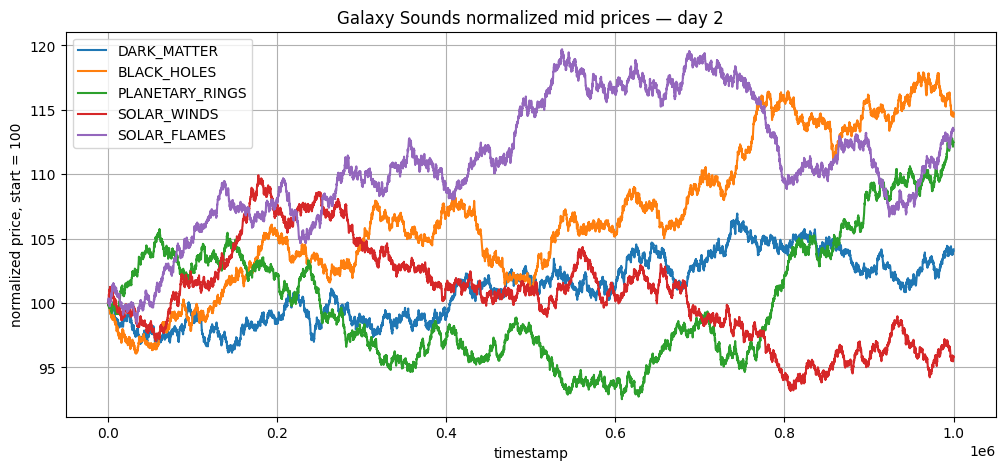

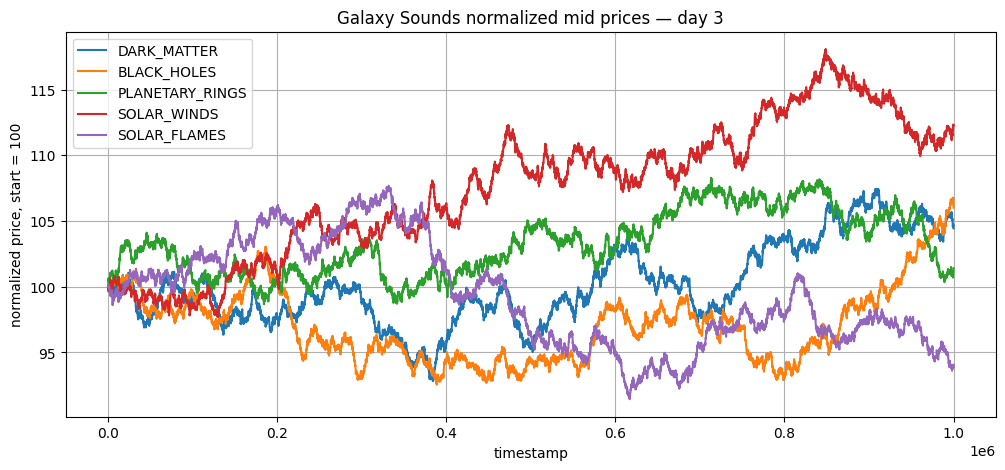

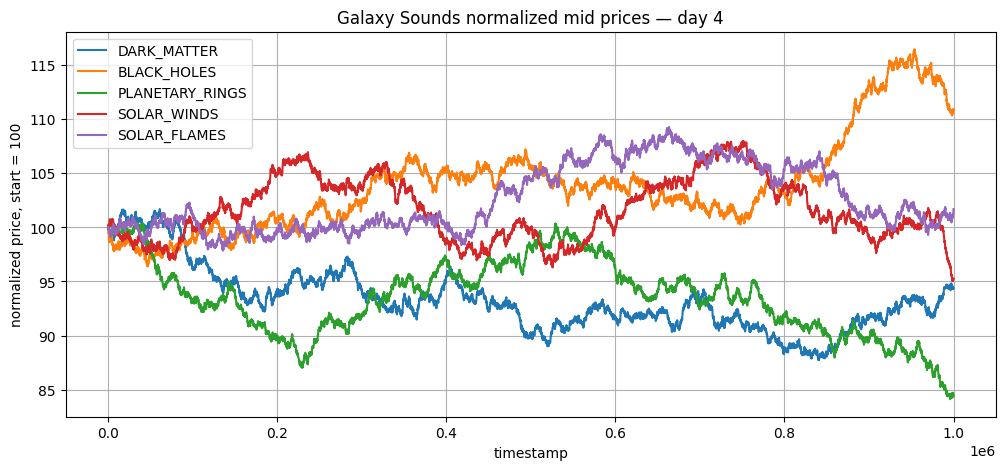

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 — GALAXY SOUNDS ONLY: MID MATRIX + BASIC SANITY
# ════════════════════════════════════════════════════════════════════════════

GALAXY_PRODUCTS = [
    "GALAXY_SOUNDS_DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES",
]

def ensure_mid_price(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensures df has a numeric mid_price column.
    Uses existing mid_price if available, otherwise computes from bid_price_1 and ask_price_1.
    """
    out = df.copy()

    if "mid_price" in out.columns:
        out["mid_price"] = pd.to_numeric(out["mid_price"], errors="coerce")
        return out

    bid_cols = [c for c in out.columns if c.lower() in ["bid_price_1", "bid_price"]]
    ask_cols = [c for c in out.columns if c.lower() in ["ask_price_1", "ask_price"]]

    if not bid_cols or not ask_cols:
        raise ValueError(
            "Could not find mid_price, bid_price_1, or ask_price_1 columns. "
            f"Available columns: {list(out.columns)}"
        )

    bid_col = bid_cols[0]
    ask_col = ask_cols[0]

    out[bid_col] = pd.to_numeric(out[bid_col], errors="coerce")
    out[ask_col] = pd.to_numeric(out[ask_col], errors="coerce")
    out["mid_price"] = (out[bid_col] + out[ask_col]) / 2.0

    return out


galaxy_prices = prices[prices["product"].isin(GALAXY_PRODUCTS)].copy()
galaxy_prices = ensure_mid_price(galaxy_prices)

galaxy_mid = (
    galaxy_prices
    .pivot_table(
        index=["file_day", "timestamp"],
        columns="product",
        values="mid_price",
        aggfunc="last",
    )
    .sort_index()
)

galaxy_mid = galaxy_mid[GALAXY_PRODUCTS]

print("galaxy_mid shape:", galaxy_mid.shape)
display(galaxy_mid.head())

# Basic daily stats.
daily_stats_rows = []

for day in sorted(galaxy_mid.index.get_level_values("file_day").unique()):
    day_mid = galaxy_mid.xs(day, level="file_day")
    day_diff = day_mid.diff()

    for product in GALAXY_PRODUCTS:
        s = day_mid[product].dropna()
        d = day_diff[product].dropna()

        daily_stats_rows.append({
            "day": day,
            "product": product,
            "start": s.iloc[0],
            "end": s.iloc[-1],
            "drift": s.iloc[-1] - s.iloc[0],
            "min": s.min(),
            "max": s.max(),
            "range": s.max() - s.min(),
            "diff_std": d.std(),
            "mean_abs_diff": d.abs().mean(),
            "max_abs_diff": d.abs().max(),
        })

galaxy_daily_stats = pd.DataFrame(daily_stats_rows)
display(galaxy_daily_stats)

# Same-time return/diff correlation.
galaxy_diff = galaxy_mid.groupby(level="file_day").diff()

print("Same-time diff correlation across all Galaxy products:")
display(galaxy_diff.corr())

# Plot normalized Galaxy paths per day.
for day in sorted(galaxy_mid.index.get_level_values("file_day").unique()):
    day_mid = galaxy_mid.xs(day, level="file_day")
    norm = day_mid / day_mid.iloc[0] * 100.0

    plt.figure(figsize=(12, 5))
    for product in GALAXY_PRODUCTS:
        plt.plot(norm.index, norm[product], label=product.replace("GALAXY_SOUNDS_", ""))
    plt.title(f"Galaxy Sounds normalized mid prices — day {day}")
    plt.xlabel("timestamp")
    plt.ylabel("normalized price, start = 100")
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 — SIGNAL HELPERS
# ════════════════════════════════════════════════════════════════════════════

def rolling_zscore(s: pd.Series, window: int, min_periods: int | None = None) -> pd.Series:
    if min_periods is None:
        min_periods = max(10, window // 2)

    mean = s.rolling(window=window, min_periods=min_periods).mean()
    std = s.rolling(window=window, min_periods=min_periods).std()

    z = (s - mean) / std.replace(0, np.nan)
    return z.replace([np.inf, -np.inf], np.nan)


def make_signal(mid_day: pd.DataFrame, config: dict) -> pd.Series:
    """
    Returns standardized signal for one config on one day.

    Supported families:
      - leadlag_same
      - basket_spread
      - pair_spread
    """
    family = config["family"]
    window = int(config["window"])

    if family == "leadlag_same":
        lead = config["lead_product"]
        lag = int(config["lag"])
        return_type = config.get("return_type", "diff")

        if return_type == "log":
            raw = np.log(mid_day[lead]).diff(lag)
        else:
            raw = mid_day[lead].diff(lag)

        return rolling_zscore(raw, window=window)

    if family == "basket_spread":
        target = config["target_product"]
        spread_type = config.get("spread_type", "diff")
        others = [p for p in GALAXY_PRODUCTS if p != target]

        if spread_type == "logratio":
            raw = np.log(mid_day[target]) - np.log(mid_day[others]).mean(axis=1)
        else:
            raw = mid_day[target] - mid_day[others].mean(axis=1)

        return rolling_zscore(raw, window=window)

    if family == "pair_spread":
        target = config["target_product"]
        anchor = config["lead_product"]
        spread_type = config.get("spread_type", "diff")

        if spread_type == "logratio":
            raw = np.log(mid_day[target]) - np.log(mid_day[anchor])
        else:
            raw = mid_day[target] - mid_day[anchor]

        return rolling_zscore(raw, window=window)

    raise ValueError(f"Unknown family: {family}")


def entry_side_from_signal(signal_value: float, mode: str, entry_z: float) -> str | None:
    """
    mode = momentum:
        signal high  -> BUY target
        signal low   -> SELL target

    mode = reversion:
        signal high  -> SELL target
        signal low   -> BUY target
    """
    if pd.isna(signal_value):
        return None

    if abs(signal_value) < entry_z:
        return None

    if mode == "momentum":
        return "BUY" if signal_value > 0 else "SELL"

    if mode == "reversion":
        return "SELL" if signal_value > 0 else "BUY"

    raise ValueError(f"Unknown mode: {mode}")


def config_name(config: dict) -> str:
    family = config["family"]

    if family == "leadlag_same":
        return (
            f"leadlag::{config['lead_product']}_to_{config['target_product']}"
            f"::lag{config['lag']}::w{config['window']}"
            f"::{config.get('return_type', 'diff')}::{config['mode']}"
        )

    if family == "basket_spread":
        return (
            f"basket::{config['target_product']}"
            f"::w{config['window']}::{config.get('spread_type', 'diff')}"
            f"::{config['mode']}"
        )

    if family == "pair_spread":
        return (
            f"pairspread::{config['lead_product']}_anchor_{config['target_product']}"
            f"::w{config['window']}::{config.get('spread_type', 'diff')}"
            f"::{config['mode']}"
        )

    return str(config)

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 — STRICT SINGLE-CONFIG BACKTESTER
# ════════════════════════════════════════════════════════════════════════════

def run_single_strict_config(
    category_mid: pd.DataFrame,
    config: dict,
    days: list[int] | None = None,
):
    """
    Strict one-strategy backtest:
      - trades only target_product
      - max one position at a time
      - position is +qty, 0, or -qty
      - exits on max_hold or signal crossing back through zero
      - flattens at end of day
      - uses mid_price approximation
    """
    if days is None:
        days = sorted(category_mid.index.get_level_values("file_day").unique())

    target = config["target_product"]
    qty = int(config.get("qty", 10))
    entry_z = float(config.get("entry_z", 2.5))
    exit_z = float(config.get("exit_z", 0.0))
    max_hold = int(config.get("max_hold", 1000))
    mode = config["mode"]

    all_trades = []
    day_rows = []

    for day in days:
        mid_day = category_mid.xs(day, level="file_day").copy()
        mid_day = mid_day.dropna(how="all")

        signal = make_signal(mid_day, config)
        price_series = mid_day[target]

        pos = 0
        entry_price = None
        entry_i = None
        entry_signal_sign = None

        day_pnl = 0.0
        trades_count = 0
        wins = 0

        timestamps = list(price_series.index)

        for i, ts in enumerate(timestamps):
            price = price_series.loc[ts]
            sig = signal.loc[ts] if ts in signal.index else np.nan

            if pd.isna(price) or pd.isna(sig):
                continue

            # 1) Exit existing position first.
            if pos != 0:
                hold = i - entry_i

                reason = None

                # Prioritise max_hold if both max_hold and signal exit happen together.
                if hold >= max_hold:
                    reason = "max_hold"
                elif entry_signal_sign is not None and entry_signal_sign * sig <= exit_z:
                    reason = "signal_exit"

                if reason is not None:
                    exit_side = "SELL" if pos > 0 else "BUY"
                    trade_pnl = (price - entry_price) * pos

                    day_pnl += trade_pnl
                    trades_count += 1
                    if trade_pnl > 0:
                        wins += 1

                    all_trades.append({
                        "day": day,
                        "timestamp": ts,
                        "product": target,
                        "side": exit_side,
                        "quantity": abs(pos),
                        "price": price,
                        "reason": reason,
                        "signal": sig,
                        "position_after": 0,
                        "trade_pnl": trade_pnl,
                        "candidate": config_name(config),
                        "family": config["family"],
                        "mode": mode,
                        "lead_product": config.get("lead_product"),
                        "target_product": target,
                        "lag": config.get("lag"),
                        "window": config.get("window"),
                        "entry_z": entry_z,
                        "exit_z": exit_z,
                        "max_hold": max_hold,
                        "return_type": config.get("return_type"),
                        "spread_type": config.get("spread_type"),
                    })

                    pos = 0
                    entry_price = None
                    entry_i = None
                    entry_signal_sign = None

            # 2) Enter new position if flat.
            if pos == 0:
                side = entry_side_from_signal(sig, mode=mode, entry_z=entry_z)

                if side is not None:
                    pos = qty if side == "BUY" else -qty
                    entry_price = price
                    entry_i = i
                    entry_signal_sign = np.sign(sig)

                    all_trades.append({
                        "day": day,
                        "timestamp": ts,
                        "product": target,
                        "side": side,
                        "quantity": qty,
                        "price": price,
                        "reason": "entry",
                        "signal": sig,
                        "position_after": pos,
                        "trade_pnl": np.nan,
                        "candidate": config_name(config),
                        "family": config["family"],
                        "mode": mode,
                        "lead_product": config.get("lead_product"),
                        "target_product": target,
                        "lag": config.get("lag"),
                        "window": config.get("window"),
                        "entry_z": entry_z,
                        "exit_z": exit_z,
                        "max_hold": max_hold,
                        "return_type": config.get("return_type"),
                        "spread_type": config.get("spread_type"),
                    })

        # 3) End-of-day flatten.
        if pos != 0:
            final_ts = price_series.dropna().index[-1]
            final_price = price_series.loc[final_ts]
            final_sig = signal.loc[final_ts] if final_ts in signal.index else np.nan

            exit_side = "SELL" if pos > 0 else "BUY"
            trade_pnl = (final_price - entry_price) * pos

            day_pnl += trade_pnl
            trades_count += 1
            if trade_pnl > 0:
                wins += 1

            all_trades.append({
                "day": day,
                "timestamp": final_ts,
                "product": target,
                "side": exit_side,
                "quantity": abs(pos),
                "price": final_price,
                "reason": "end_of_day_flatten",
                "signal": final_sig,
                "position_after": 0,
                "trade_pnl": trade_pnl,
                "candidate": config_name(config),
                "family": config["family"],
                "mode": mode,
                "lead_product": config.get("lead_product"),
                "target_product": target,
                "lag": config.get("lag"),
                "window": config.get("window"),
                "entry_z": entry_z,
                "exit_z": exit_z,
                "max_hold": max_hold,
                "return_type": config.get("return_type"),
                "spread_type": config.get("spread_type"),
            })

            pos = 0

        hit_rate = wins / trades_count if trades_count else np.nan

        day_rows.append({
            "candidate": config_name(config),
            "day": day,
            "day_pnl": day_pnl,
            "trades": trades_count,
            "wins": wins,
            "hit_rate": hit_rate,
            "final_abs_position": abs(pos),
        })

    trades_df = pd.DataFrame(all_trades)
    day_df = pd.DataFrame(day_rows)

    day_pnls = dict(zip(day_df["day"], day_df["day_pnl"]))
    total_pnl = day_df["day_pnl"].sum()
    min_day_pnl = day_df["day_pnl"].min()
    positive_days = int((day_df["day_pnl"] > 0).sum())
    num_days = len(day_df)
    total_trades = int(day_df["trades"].sum())
    mean_hit_rate = day_df["hit_rate"].mean()

    result = {
        "candidate": config_name(config),
        "family": config["family"],
        "mode": config["mode"],
        "lead_product": config.get("lead_product"),
        "target_product": config["target_product"],
        "lag": config.get("lag"),
        "window": config.get("window"),
        "entry_z": config.get("entry_z"),
        "exit_z": config.get("exit_z"),
        "qty": config.get("qty"),
        "max_hold": config.get("max_hold"),
        "return_type": config.get("return_type"),
        "spread_type": config.get("spread_type"),
        "total_pnl": total_pnl,
        "min_day_pnl": min_day_pnl,
        "positive_days": positive_days,
        "num_days": num_days,
        "total_trades": total_trades,
        "mean_hit_rate": mean_hit_rate,
        "day_pnls": day_pnls,
        "robust_score": total_pnl + 2 * min_day_pnl,
    }

    return result, day_df, trades_df

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 — LEAD-LAG INFORMATION SCAN
# ════════════════════════════════════════════════════════════════════════════

def safe_corr(a: pd.Series, b: pd.Series) -> float:
    valid = pd.concat([a, b], axis=1).dropna()
    if len(valid) < 30:
        return np.nan
    if valid.iloc[:, 0].std() == 0 or valid.iloc[:, 1].std() == 0:
        return np.nan
    return valid.iloc[:, 0].corr(valid.iloc[:, 1])


def directional_hit_rate(signal: pd.Series, future_move: pd.Series, expected_mode: str) -> float:
    valid = pd.concat([signal, future_move], axis=1).dropna()
    if len(valid) < 30:
        return np.nan

    sig = valid.iloc[:, 0]
    fut = valid.iloc[:, 1]

    nonzero = (sig != 0) & (fut != 0)
    sig = sig[nonzero]
    fut = fut[nonzero]

    if len(sig) < 30:
        return np.nan

    if expected_mode == "momentum":
        return (np.sign(sig) == np.sign(fut)).mean()

    if expected_mode == "reversion":
        return (np.sign(sig) != np.sign(fut)).mean()

    raise ValueError(expected_mode)


def scan_leadlag_ic(
    category_mid: pd.DataFrame,
    products: list[str],
    lags: list[int],
    horizons: list[int],
    return_types: tuple[str, ...] = ("diff", "log"),
) -> pd.DataFrame:
    rows = []

    days = sorted(category_mid.index.get_level_values("file_day").unique())

    for return_type in return_types:
        for lead in products:
            for target in products:
                if lead == target:
                    continue

                for lag in lags:
                    for horizon in horizons:
                        day_ics = {}
                        day_mom_hits = {}
                        day_rev_hits = {}

                        for day in days:
                            mid_day = category_mid.xs(day, level="file_day").copy()

                            if return_type == "log":
                                signal = np.log(mid_day[lead]).diff(lag)
                            else:
                                signal = mid_day[lead].diff(lag)

                            future_move = mid_day[target].shift(-horizon) - mid_day[target]

                            ic = safe_corr(signal, future_move)
                            mom_hit = directional_hit_rate(signal, future_move, "momentum")
                            rev_hit = directional_hit_rate(signal, future_move, "reversion")

                            day_ics[day] = ic
                            day_mom_hits[day] = mom_hit
                            day_rev_hits[day] = rev_hit

                        valid_ics = [v for v in day_ics.values() if not pd.isna(v)]

                        if len(valid_ics) == 0:
                            continue

                        mean_ic = float(np.mean(valid_ics))
                        min_abs_ic = float(np.min(np.abs(valid_ics)))
                        same_sign_days = int(np.sum(np.sign(valid_ics) == np.sign(mean_ic)))
                        valid_days = len(valid_ics)

                        implied_mode = "momentum" if mean_ic > 0 else "reversion"
                        mean_mom_hit = np.nanmean(list(day_mom_hits.values()))
                        mean_rev_hit = np.nanmean(list(day_rev_hits.values()))

                        rows.append({
                            "lead_product": lead,
                            "target_product": target,
                            "lag": lag,
                            "horizon": horizon,
                            "return_type": return_type,
                            "mean_ic": mean_ic,
                            "abs_mean_ic": abs(mean_ic),
                            "min_abs_ic": min_abs_ic,
                            "same_sign_days": same_sign_days,
                            "valid_days": valid_days,
                            "implied_mode": implied_mode,
                            "mean_momentum_hit": mean_mom_hit,
                            "mean_reversion_hit": mean_rev_hit,
                            "day_ics": day_ics,
                            "robust_ic_score": abs(mean_ic) + min_abs_ic + 0.02 * same_sign_days,
                        })

    return pd.DataFrame(rows)


LEADLAG_LAGS = [1, 2, 5, 10, 20, 50, 100, 150, 200, 300, 500, 750, 1000]
LEADLAG_HORIZONS = [5, 10, 20, 50, 100, 200, 500]

leadlag_ic = scan_leadlag_ic(
    category_mid=galaxy_mid,
    products=GALAXY_PRODUCTS,
    lags=LEADLAG_LAGS,
    horizons=LEADLAG_HORIZONS,
    return_types=("diff", "log"),
)

leadlag_ic_top = (
    leadlag_ic
    .query("valid_days == 3")
    .sort_values(["robust_ic_score", "abs_mean_ic"], ascending=False)
    .reset_index(drop=True)
)

print("Top lead-lag IC candidates:")
display(leadlag_ic_top.head(50))

Top lead-lag IC candidates:


,lead_product,target_product,lag,horizon,return_type,mean_ic,abs_mean_ic,min_abs_ic,same_sign_days,valid_days,implied_mode,mean_momentum_hit,mean_reversion_hit,day_ics,robust_ic_score
0,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,750,500,diff,-0.258236,0.258236,0.176922,3,3,reversion,0.480911,0.519089,"{2: -0.380607217755034, 3: -0.2171791020129715...",0.495159
1,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,750,500,log,-0.256990,0.256990,0.177497,3,3,reversion,0.480911,0.519089,"{2: -0.3816671025797458, 3: -0.211807309261196...",0.494487
2,GALAXY_SOUNDS_PLANETARY_RINGS,GALAXY_SOUNDS_SOLAR_FLAMES,500,500,log,0.228478,0.228478,0.178932,3,3,momentum,0.562170,0.437830,"{2: 0.2175038022728544, 3: 0.17893236956112793...",0.467410
3,GALAXY_SOUNDS_PLANETARY_RINGS,GALAXY_SOUNDS_SOLAR_FLAMES,500,500,diff,0.227105,0.227105,0.176897,3,3,momentum,0.562170,0.437830,"{2: 0.2143669623454575, 3: 0.17689740433350512...",0.464002
4,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS_BLACK_HOLES,1000,500,log,-0.118479,0.118479,0.292498,2,3,reversion,0.466793,0.533207,"{2: 0.29249797052796284, 3: -0.305841683654831...",0.450977
5,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS_BLACK_HOLES,1000,500,diff,-0.120436,0.120436,0.289334,2,3,reversion,0.466793,0.533207,"{2: 0.2893343996377932, 3: -0.3048252953712028...",0.449771
6,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS_SOLAR_WINDS,1000,500,diff,0.214658,0.214658,0.167661,3,3,momentum,0.554716,0.445284,"{2: 0.21328700391422817, 3: 0.2630245632302522...",0.442319
7,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS_SOLAR_WINDS,1000,500,log,0.220565,0.220565,0.158010,3,3,momentum,0.554716,0.445284,"{2: 0.23351960417390016, 3: 0.2701657216069416...",0.438575
8,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS_PLANETARY_RINGS,750,500,log,-0.155333,0.155333,0.236985,2,3,reversion,0.440107,0.559893,"{2: -0.390187343176677, 3: -0.3127971375480642...",0.432318
9,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS_PLANETARY_RINGS,750,500,diff,-0.160209,0.160209,0.231147,2,3,reversion,0.440107,0.559893,"{2: -0.39695824636739746, 3: -0.31481458100020...",0.431356


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 — STRICT LEAD-LAG STRATEGY SCAN
# ════════════════════════════════════════════════════════════════════════════

TOP_IC_N = 40

LEADLAG_WINDOWS = [50, 100, 200, 500]
ENTRY_ZS = [2.0, 2.25, 2.5, 2.75, 3.0]
MAX_HOLDS = [100, 250, 500, 750, 1000, 1500]

leadlag_scan_configs = []
leadlag_scan_results = []

seed_rows = leadlag_ic_top.head(TOP_IC_N).copy()

for _, seed in seed_rows.iterrows():
    for window in LEADLAG_WINDOWS:
        for entry_z in ENTRY_ZS:
            for max_hold in MAX_HOLDS:
                for mode in ["momentum", "reversion"]:
                    cfg = {
                        "family": "leadlag_same",
                        "lead_product": seed["lead_product"],
                        "target_product": seed["target_product"],
                        "lag": int(seed["lag"]),
                        "window": int(window),
                        "entry_z": float(entry_z),
                        "exit_z": 0.0,
                        "qty": 10,
                        "max_hold": int(max_hold),
                        "return_type": seed["return_type"],
                        "mode": mode,
                        "position_limit": 10,
                        "diagnostic_horizon": int(seed["horizon"]),
                        "diagnostic_mean_ic": float(seed["mean_ic"]),
                        "diagnostic_implied_mode": seed["implied_mode"],
                    }

                    result, day_result, trade_log = run_single_strict_config(
                        category_mid=galaxy_mid,
                        config=cfg,
                    )

                    config_id = len(leadlag_scan_configs)
                    result["config_id"] = config_id
                    result["diagnostic_horizon"] = int(seed["horizon"])
                    result["diagnostic_mean_ic"] = float(seed["mean_ic"])
                    result["diagnostic_implied_mode"] = seed["implied_mode"]

                    leadlag_scan_configs.append(cfg)
                    leadlag_scan_results.append(result)

leadlag_strict = (
    pd.DataFrame(leadlag_scan_results)
    .sort_values(["robust_score", "total_pnl", "min_day_pnl"], ascending=False)
    .reset_index(drop=True)
)

print("Top strict lead-lag Galaxy candidates:")
display(leadlag_strict.head(50))

print("Positive 3/3 lead-lag candidates:")
display(
    leadlag_strict
    .query("positive_days == 3 and total_pnl > 0 and total_trades >= 5")
    .head(50)
)

KeyboardInterrupt: 

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 — BASKET + PAIR SPREAD STRICT SCAN
# ════════════════════════════════════════════════════════════════════════════

SPREAD_WINDOWS = [50, 100, 200, 500, 1000]
SPREAD_ENTRY_ZS = [1.5, 2.0, 2.5, 3.0]
SPREAD_MAX_HOLDS = [100, 250, 500, 750, 1000]
SPREAD_TYPES = ["diff", "logratio"]

spread_scan_configs = []
spread_scan_results = []

# 1) Target vs average of other Galaxy products.
for target in GALAXY_PRODUCTS:
    for spread_type in SPREAD_TYPES:
        for window in SPREAD_WINDOWS:
            for entry_z in SPREAD_ENTRY_ZS:
                for max_hold in SPREAD_MAX_HOLDS:
                    for mode in ["reversion", "momentum"]:
                        cfg = {
                            "family": "basket_spread",
                            "target_product": target,
                            "window": int(window),
                            "entry_z": float(entry_z),
                            "exit_z": 0.0,
                            "qty": 10,
                            "max_hold": int(max_hold),
                            "spread_type": spread_type,
                            "mode": mode,
                            "position_limit": 10,
                        }

                        result, day_result, trade_log = run_single_strict_config(
                            category_mid=galaxy_mid,
                            config=cfg,
                        )

                        config_id = len(spread_scan_configs)
                        result["config_id"] = config_id

                        spread_scan_configs.append(cfg)
                        spread_scan_results.append(result)

# 2) Target vs one anchor product.
for anchor in GALAXY_PRODUCTS:
    for target in GALAXY_PRODUCTS:
        if anchor == target:
            continue

        for spread_type in SPREAD_TYPES:
            for window in SPREAD_WINDOWS:
                for entry_z in SPREAD_ENTRY_ZS:
                    for max_hold in SPREAD_MAX_HOLDS:
                        for mode in ["reversion", "momentum"]:
                            cfg = {
                                "family": "pair_spread",
                                "lead_product": anchor,
                                "target_product": target,
                                "window": int(window),
                                "entry_z": float(entry_z),
                                "exit_z": 0.0,
                                "qty": 10,
                                "max_hold": int(max_hold),
                                "spread_type": spread_type,
                                "mode": mode,
                                "position_limit": 10,
                            }

                            result, day_result, trade_log = run_single_strict_config(
                                category_mid=galaxy_mid,
                                config=cfg,
                            )

                            config_id = len(spread_scan_configs)
                            result["config_id"] = config_id

                            spread_scan_configs.append(cfg)
                            spread_scan_results.append(result)

spread_strict = (
    pd.DataFrame(spread_scan_results)
    .sort_values(["robust_score", "total_pnl", "min_day_pnl"], ascending=False)
    .reset_index(drop=True)
)

print("Top strict spread Galaxy candidates:")
display(spread_strict.head(50))

print("Positive 3/3 spread candidates:")
display(
    spread_strict
    .query("positive_days == 3 and total_pnl > 0 and total_trades >= 5")
    .head(50)
)

KeyboardInterrupt: 

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 — BASKET + PAIR SPREAD STRICT SCAN
# ════════════════════════════════════════════════════════════════════════════

SPREAD_WINDOWS = [50, 100, 200, 500, 1000]
SPREAD_ENTRY_ZS = [1.5, 2.0, 2.5, 3.0]
SPREAD_MAX_HOLDS = [100, 250, 500, 750, 1000]
SPREAD_TYPES = ["diff", "logratio"]

spread_scan_configs = []
spread_scan_results = []

# 1) Target vs average of other Galaxy products.
for target in GALAXY_PRODUCTS:
    for spread_type in SPREAD_TYPES:
        for window in SPREAD_WINDOWS:
            for entry_z in SPREAD_ENTRY_ZS:
                for max_hold in SPREAD_MAX_HOLDS:
                    for mode in ["reversion", "momentum"]:
                        cfg = {
                            "family": "basket_spread",
                            "target_product": target,
                            "window": int(window),
                            "entry_z": float(entry_z),
                            "exit_z": 0.0,
                            "qty": 10,
                            "max_hold": int(max_hold),
                            "spread_type": spread_type,
                            "mode": mode,
                            "position_limit": 10,
                        }

                        result, day_result, trade_log = run_single_strict_config(
                            category_mid=galaxy_mid,
                            config=cfg,
                        )

                        config_id = len(spread_scan_configs)
                        result["config_id"] = config_id

                        spread_scan_configs.append(cfg)
                        spread_scan_results.append(result)

# 2) Target vs one anchor product.
for anchor in GALAXY_PRODUCTS:
    for target in GALAXY_PRODUCTS:
        if anchor == target:
            continue

        for spread_type in SPREAD_TYPES:
            for window in SPREAD_WINDOWS:
                for entry_z in SPREAD_ENTRY_ZS:
                    for max_hold in SPREAD_MAX_HOLDS:
                        for mode in ["reversion", "momentum"]:
                            cfg = {
                                "family": "pair_spread",
                                "lead_product": anchor,
                                "target_product": target,
                                "window": int(window),
                                "entry_z": float(entry_z),
                                "exit_z": 0.0,
                                "qty": 10,
                                "max_hold": int(max_hold),
                                "spread_type": spread_type,
                                "mode": mode,
                                "position_limit": 10,
                            }

                            result, day_result, trade_log = run_single_strict_config(
                                category_mid=galaxy_mid,
                                config=cfg,
                            )

                            config_id = len(spread_scan_configs)
                            result["config_id"] = config_id

                            spread_scan_configs.append(cfg)
                            spread_scan_results.append(result)

spread_strict = (
    pd.DataFrame(spread_scan_results)
    .sort_values(["robust_score", "total_pnl", "min_day_pnl"], ascending=False)
    .reset_index(drop=True)
)

print("Top strict spread Galaxy candidates:")
display(spread_strict.head(50))

print("Positive 3/3 spread candidates:")
display(
    spread_strict
    .query("positive_days == 3 and total_pnl > 0 and total_trades >= 5")
    .head(50)
)

KeyboardInterrupt: 

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# FAST GALAXY SOUNDS SCAN — VECTORISED BASKET / LEAD-LAG NOTEBOOK CELL
# ════════════════════════════════════════════════════════════════════════════

import time
import numpy as np
import pandas as pd

T0_ALL = time.perf_counter()

# ───────────────────────────────────────────────────────────────────────────
# USER-TUNABLE GRID
# ───────────────────────────────────────────────────────────────────────────

GALAXY_PRODUCTS = [
    "GALAXY_SOUNDS_DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES",
]

SHORT = {
    "GALAXY_SOUNDS_DARK_MATTER": "DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES": "BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS": "PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS": "SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES": "SOLAR_FLAMES",
}

# Keep this moderate. Expand only if the first scan looks promising.
WINDOWS = [50, 100, 200, 500, 1000]
HORIZONS = [50, 100, 200, 500, 750, 1000]
ENTRY_ZS = [1.5, 2.0, 2.5, 3.0]
MODES = ["reversion", "momentum"]

# Lead-lag is included because your preliminary Galaxy scan showed lead-lag IC.
ENABLE_LEADLAG_SCAN = True
LEADLAG_LAGS = [20, 50, 100, 200, 300, 500, 750, 1000]
LEADLAG_RETURN_TYPES = ["diff", "log"]

TOP_N_FOR_STAGE_2 = 10


# ───────────────────────────────────────────────────────────────────────────
# STAGE 0 — PIVOT ONCE, ALIGN ONCE, CONVERT EACH DAY TO NUMPY ONCE
# ───────────────────────────────────────────────────────────────────────────

print("STAGE 0 — building aligned wide matrices...")

prices_fast = prices.copy()

if "day" not in prices_fast.columns:
    assert "file_day" in prices_fast.columns, "Need either `day` or `file_day` in prices."
    prices_fast["day"] = prices_fast["file_day"]

# Robust bid/ask column detection.
if "bid_price_1" in prices_fast.columns:
    BID_COL = "bid_price_1"
elif "bid_price" in prices_fast.columns:
    BID_COL = "bid_price"
else:
    raise ValueError("Could not find bid column. Expected bid_price_1 or bid_price.")

if "ask_price_1" in prices_fast.columns:
    ASK_COL = "ask_price_1"
elif "ask_price" in prices_fast.columns:
    ASK_COL = "ask_price"
else:
    raise ValueError("Could not find ask column. Expected ask_price_1 or ask_price.")

if "mid_price" not in prices_fast.columns:
    prices_fast["mid_price"] = (prices_fast[BID_COL] + prices_fast[ASK_COL]) / 2.0

# Requirement 1: pivot once.
mid = prices_fast.pivot_table(
    index=["day", "timestamp"],
    columns="product",
    values="mid_price",
    aggfunc="last",
).sort_index()

bid = prices_fast.pivot_table(
    index=["day", "timestamp"],
    columns="product",
    values=BID_COL,
    aggfunc="last",
).sort_index()

ask = prices_fast.pivot_table(
    index=["day", "timestamp"],
    columns="product",
    values=ASK_COL,
    aggfunc="last",
).sort_index()

missing = sorted(set(GALAXY_PRODUCTS) - set(mid.columns))
assert not missing, f"Missing Galaxy products in prices: {missing}"

# Drop rows where any required product is missing from mid/bid/ask.
aligned = pd.concat(
    {
        "mid": mid[GALAXY_PRODUCTS],
        "bid": bid[GALAXY_PRODUCTS],
        "ask": ask[GALAXY_PRODUCTS],
    },
    axis=1,
).dropna()

mid = aligned["mid"]
bid = aligned["bid"]
ask = aligned["ask"]

print("Aligned mid shape:", mid.shape)
print("Aligned bid shape:", bid.shape)
print("Aligned ask shape:", ask.shape)
print("Days:", sorted(mid.index.get_level_values("day").unique()))

# Requirement 2: convert each day's data to NumPy arrays once.
DAY_DATA = {}

for day in sorted(mid.index.get_level_values("day").unique()):
    mid_day = mid.xs(day, level="day")[GALAXY_PRODUCTS]
    bid_day = bid.xs(day, level="day")[GALAXY_PRODUCTS]
    ask_day = ask.xs(day, level="day")[GALAXY_PRODUCTS]

    X = mid_day.to_numpy(float)
    B = bid_day.to_numpy(float)
    A = ask_day.to_numpy(float)
    ts = mid_day.index.to_numpy()

    assert X.shape == B.shape == A.shape
    assert X.shape[1] == len(GALAXY_PRODUCTS)
    assert np.all(np.diff(ts) >= 0), f"Timestamps not sorted for day {day}"
    assert len(np.unique(ts)) == len(ts), f"Duplicate timestamps in aligned day {day}"

    DAY_DATA[day] = {
        "timestamp": ts,
        "X": X,
        "B": B,
        "A": A,
    }

print("Per-day NumPy shapes:")
for day, d in DAY_DATA.items():
    print(f"  day {day}: X={d['X'].shape}, B={d['B'].shape}, A={d['A'].shape}")

assert len(DAY_DATA) >= 1, "No aligned day data found."
print(f"Stage 0 done in {time.perf_counter() - T0_ALL:.2f}s")


# ───────────────────────────────────────────────────────────────────────────
# HELPERS
# ───────────────────────────────────────────────────────────────────────────

PRODUCT_TO_I = {p: i for i, p in enumerate(GALAXY_PRODUCTS)}


def q_to_str(q):
    parts = []
    for p, v in zip(GALAXY_PRODUCTS, q):
        if abs(v) > 1e-12:
            parts.append(f"{SHORT[p]}:{v:g}")
    return " | ".join(parts)


def rolling_z(spread, window):
    # Requirement 4: pandas rolling only on the spread.
    s = pd.Series(spread)
    mean = s.rolling(window=window, min_periods=window).mean().to_numpy()
    std = s.rolling(window=window, min_periods=window).std().to_numpy()

    z = (spread - mean) / std
    z[~np.isfinite(z)] = np.nan
    return z


def vectorised_pnl_for_q(X, B, A, q, h):
    """
    Requirement 5:
      For long basket q:
      - entry uses ask where q > 0, bid where q < 0
      - exit uses bid where q > 0, ask where q < 0
      - all timestamps calculated by NumPy slicing.
    """
    assert h > 0
    assert h < len(X), "Horizon must be inside one day only."

    # Requirement: no cross-day horizon leakage. This function is only passed one day.
    X0 = X[:-h]
    X1 = X[h:]

    B0 = B[:-h]
    A0 = A[:-h]
    B1 = B[h:]
    A1 = A[h:]

    entry_px = np.where(q > 0, A0, B0)
    exit_px = np.where(q > 0, B1, A1)

    exec_pnl = ((exit_px - entry_px) * q).sum(axis=1)
    mid_pnl = ((X1 - X0) * q).sum(axis=1)

    cost = mid_pnl - exec_pnl

    # Sanity: cost identity.
    assert np.allclose(mid_pnl - exec_pnl, cost, atol=1e-9), "Cost identity failed."

    return mid_pnl, exec_pnl, cost


def build_signal(candidate, X):
    kind = candidate["kind"]

    if kind in {"pair_spread", "basket_vs_rest"}:
        q_signal = candidate["signal_q"]

        # Requirement 3: basket spread = X @ q.
        spread = X @ q_signal
        return spread

    if kind == "leadlag":
        lead_i = candidate["lead_i"]
        lag = candidate["lag"]
        return_type = candidate["return_type"]

        x = X[:, lead_i].astype(float)
        signal = np.full(len(x), np.nan)

        if return_type == "log":
            lx = np.log(x)
            signal[lag:] = lx[lag:] - lx[:-lag]
        else:
            signal[lag:] = x[lag:] - x[:-lag]

        return signal

    raise ValueError(f"Unknown candidate kind: {kind}")


def masks_from_z(z0, entry_z, mode):
    valid = np.isfinite(z0)

    if mode == "reversion":
        # Basket is cheap -> long q. Basket is rich -> short q.
        long_mask = valid & (z0 <= -entry_z)
        short_mask = valid & (z0 >= entry_z)

    elif mode == "momentum":
        # Positive signal continues -> long q. Negative signal continues -> short q.
        long_mask = valid & (z0 >= entry_z)
        short_mask = valid & (z0 <= -entry_z)

    else:
        raise ValueError(mode)

    return long_mask, short_mask


def summarise_signal_pnls(long_mask, short_mask, long_mid, long_exec, long_cost, short_mid, short_exec, short_cost):
    long_count = int(long_mask.sum())
    short_count = int(short_mask.sum())
    trades = long_count + short_count

    if trades == 0:
        return {
            "long_count": 0,
            "short_count": 0,
            "signal_count": 0,
            "mid_pnl": 0.0,
            "exec_pnl": 0.0,
            "cost": 0.0,
            "wins": 0,
            "hit_rate": np.nan,
            "avg_trade_pnl": np.nan,
        }

    exec_parts = []
    mid_parts = []
    cost_parts = []

    if long_count:
        exec_parts.append(long_exec[long_mask])
        mid_parts.append(long_mid[long_mask])
        cost_parts.append(long_cost[long_mask])

    if short_count:
        exec_parts.append(short_exec[short_mask])
        mid_parts.append(short_mid[short_mask])
        cost_parts.append(short_cost[short_mask])

    trade_exec = np.concatenate(exec_parts)
    trade_mid = np.concatenate(mid_parts)
    trade_cost = np.concatenate(cost_parts)

    return {
        "long_count": long_count,
        "short_count": short_count,
        "signal_count": trades,
        "mid_pnl": float(trade_mid.sum()),
        "exec_pnl": float(trade_exec.sum()),
        "cost": float(trade_cost.sum()),
        "wins": int((trade_exec > 0).sum()),
        "hit_rate": float((trade_exec > 0).mean()),
        "avg_trade_pnl": float(trade_exec.mean()),
    }


# ───────────────────────────────────────────────────────────────────────────
# STAGE 1A — BUILD CANDIDATE BASKETS / SIGNALS
# ───────────────────────────────────────────────────────────────────────────

print("\nSTAGE 1A — building candidate baskets/signals...")

CANDIDATES = []

# Pair spreads: +10 one Galaxy product, -10 another.
for i, p1 in enumerate(GALAXY_PRODUCTS):
    for j, p2 in enumerate(GALAXY_PRODUCTS):
        if j <= i:
            continue

        q = np.zeros(len(GALAXY_PRODUCTS))
        q[i] = 10.0
        q[j] = -10.0

        CANDIDATES.append({
            "kind": "pair_spread",
            "candidate_name": f"PAIR::{SHORT[p1]}_minus_{SHORT[p2]}",
            "lead_product": p1,
            "target_product": p2,
            "signal_q": q.copy(),
            "trade_q": q.copy(),
            "q_str": q_to_str(q),
            "lag": np.nan,
            "return_type": None,
        })

# Basket-vs-rest: +10 target, -2.5 each other product.
# Fractional q is for diagnostics; implementation can later round/translate if needed.
for p in GALAXY_PRODUCTS:
    q = np.zeros(len(GALAXY_PRODUCTS))
    i = PRODUCT_TO_I[p]
    q[i] = 10.0
    for other in GALAXY_PRODUCTS:
        if other != p:
            q[PRODUCT_TO_I[other]] = -10.0 / (len(GALAXY_PRODUCTS) - 1)

    CANDIDATES.append({
        "kind": "basket_vs_rest",
        "candidate_name": f"BASKET::{SHORT[p]}_minus_rest_avg",
        "lead_product": None,
        "target_product": p,
        "signal_q": q.copy(),
        "trade_q": q.copy(),
        "q_str": q_to_str(q),
        "lag": np.nan,
        "return_type": None,
    })

# Lead-lag signals from preliminary Galaxy work:
# signal = lead return over lag; trade q = target product only.
if ENABLE_LEADLAG_SCAN:
    for lead in GALAXY_PRODUCTS:
        for target in GALAXY_PRODUCTS:
            if lead == target:
                continue

            for lag in LEADLAG_LAGS:
                for return_type in LEADLAG_RETURN_TYPES:
                    q = np.zeros(len(GALAXY_PRODUCTS))
                    q[PRODUCT_TO_I[target]] = 10.0

                    CANDIDATES.append({
                        "kind": "leadlag",
                        "candidate_name": f"LEADLAG::{SHORT[lead]}_to_{SHORT[target]}::lag{lag}::{return_type}",
                        "lead_product": lead,
                        "target_product": target,
                        "lead_i": PRODUCT_TO_I[lead],
                        "signal_q": None,
                        "trade_q": q.copy(),
                        "q_str": q_to_str(q),
                        "lag": int(lag),
                        "return_type": return_type,
                    })

print(f"Number of candidate baskets/signals: {len(CANDIDATES):,}")
print("  pair_spread:", sum(c["kind"] == "pair_spread" for c in CANDIDATES))
print("  basket_vs_rest:", sum(c["kind"] == "basket_vs_rest" for c in CANDIDATES))
print("  leadlag:", sum(c["kind"] == "leadlag" for c in CANDIDATES))


# ───────────────────────────────────────────────────────────────────────────
# STAGE 1B — BROAD FAST VECTORISED SCAN
# ───────────────────────────────────────────────────────────────────────────

print("\nSTAGE 1B — broad fast vectorised scan...")

stage1_start = time.perf_counter()

day_rows = []
CONFIGS = {}
next_config_id = 0

for cand_i, cand in enumerate(CANDIDATES, start=1):
    if cand_i == 1 or cand_i % 10 == 0 or cand_i == len(CANDIDATES):
        elapsed = time.perf_counter() - stage1_start
        print(f"  processed {cand_i:,}/{len(CANDIDATES):,} baskets/signals | elapsed {elapsed:.1f}s")

    for day, d in DAY_DATA.items():
        X = d["X"]
        B = d["B"]
        A = d["A"]

        raw_signal = build_signal(cand, X)

        for window in WINDOWS:
            z = rolling_z(raw_signal, window)

            for h in HORIZONS:
                if h >= len(X):
                    continue

                # No cross-day leakage: horizon is always within this one day's X/B/A arrays.
                assert h < len(X)
                assert len(z[:-h]) == len(X) - h

                trade_q = cand["trade_q"]

                long_mid, long_exec, long_cost = vectorised_pnl_for_q(X, B, A, trade_q, h)
                short_mid, short_exec, short_cost = vectorised_pnl_for_q(X, B, A, -trade_q, h)

                z0 = z[:-h]

                for mode in MODES:
                    for entry_z in ENTRY_ZS:
                        cfg_key = (
                            cand_i - 1,
                            int(window),
                            int(h),
                            float(entry_z),
                            mode,
                        )

                        if cfg_key not in CONFIGS:
                            CONFIGS[cfg_key] = {
                                "config_id": next_config_id,
                                "candidate_i": cand_i - 1,
                                "candidate_name": cand["candidate_name"],
                                "kind": cand["kind"],
                                "mode": mode,
                                "lead_product": cand["lead_product"],
                                "target_product": cand["target_product"],
                                "q_str": cand["q_str"],
                                "window": int(window),
                                "horizon": int(h),
                                "entry_z": float(entry_z),
                                "lag": cand["lag"],
                                "return_type": cand["return_type"],
                            }
                            next_config_id += 1

                        cfg = CONFIGS[cfg_key]

                        long_mask, short_mask = masks_from_z(z0, entry_z, mode)

                        stats = summarise_signal_pnls(
                            long_mask=long_mask,
                            short_mask=short_mask,
                            long_mid=long_mid,
                            long_exec=long_exec,
                            long_cost=long_cost,
                            short_mid=short_mid,
                            short_exec=short_exec,
                            short_cost=short_cost,
                        )

                        day_rows.append({
                            **cfg,
                            "day": day,
                            **stats,
                        })

FAST_DAY_BASE = pd.DataFrame(day_rows)

assert not FAST_DAY_BASE.empty, "Stage 1 produced no rows."
assert FAST_DAY_BASE["day"].nunique() == len(DAY_DATA), "Not all days were handled separately."

# Aggregate to config-level summary.
group_cols = [
    "config_id",
    "candidate_i",
    "candidate_name",
    "kind",
    "mode",
    "lead_product",
    "target_product",
    "q_str",
    "window",
    "horizon",
    "entry_z",
    "lag",
    "return_type",
]

g = FAST_DAY_BASE.groupby(group_cols, dropna=False)

FAST_BASE_SUMMARY = g.agg(
    total_pnl=("exec_pnl", "sum"),
    total_mid_pnl=("mid_pnl", "sum"),
    total_cost=("cost", "sum"),
    min_day_pnl=("exec_pnl", "min"),
    max_day_pnl=("exec_pnl", "max"),
    positive_days=("exec_pnl", lambda s: int((s > 0).sum())),
    num_days=("day", "nunique"),
    total_trades=("signal_count", "sum"),
    total_longs=("long_count", "sum"),
    total_shorts=("short_count", "sum"),
    total_wins=("wins", "sum"),
    avg_trade_pnl=("avg_trade_pnl", "mean"),
).reset_index()

FAST_BASE_SUMMARY["mean_hit_rate"] = np.where(
    FAST_BASE_SUMMARY["total_trades"] > 0,
    FAST_BASE_SUMMARY["total_wins"] / FAST_BASE_SUMMARY["total_trades"],
    np.nan,
)

day_pnls = g.apply(lambda x: dict(zip(x["day"], x["exec_pnl"]))).rename("day_pnls").reset_index()
FAST_BASE_SUMMARY = FAST_BASE_SUMMARY.merge(day_pnls, on=group_cols, how="left")

# Robustness score: total plus penalty/reward for worst day.
FAST_BASE_SUMMARY["robust_score"] = (
    FAST_BASE_SUMMARY["total_pnl"] + 2.0 * FAST_BASE_SUMMARY["min_day_pnl"]
)

FAST_BASE_SUMMARY = FAST_BASE_SUMMARY.sort_values(
    ["robust_score", "total_pnl", "min_day_pnl", "total_trades"],
    ascending=False,
).reset_index(drop=True)

FAST_BEST_PER_BASKET = (
    FAST_BASE_SUMMARY
    .sort_values(["robust_score", "total_pnl", "min_day_pnl"], ascending=False)
    .groupby("candidate_name", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print(f"\nStage 1 done in {time.perf_counter() - stage1_start:.2f}s")
print("FAST_DAY_BASE shape:", FAST_DAY_BASE.shape)
print("FAST_BASE_SUMMARY shape:", FAST_BASE_SUMMARY.shape)
print("FAST_BEST_PER_BASKET shape:", FAST_BEST_PER_BASKET.shape)

print("\nTop broad scan candidates:")
display(FAST_BASE_SUMMARY.head(50))

print("\nBest per basket/signal:")
display(FAST_BEST_PER_BASKET.head(50))

print("\nTop candidates with 3/3 positive days and at least 10 signals:")
display(
    FAST_BASE_SUMMARY
    .query("positive_days == num_days and total_pnl > 0 and total_trades >= 10")
    .head(50)
)


# ───────────────────────────────────────────────────────────────────────────
# STAGE 2 — NARROW EVENT-LEVEL DIAGNOSTICS ON TOP 5–10 ONLY
# This avoids pretending overlapping vectorised signals are deployable.
# It keeps only one active fixed-horizon position per config/day.
# ───────────────────────────────────────────────────────────────────────────

print("\nSTAGE 2 — narrow non-overlap diagnostics on top candidates only...")

stage2_start = time.perf_counter()

CONFIG_BY_ID = {}
for cfg in CONFIGS.values():
    CONFIG_BY_ID[cfg["config_id"]] = cfg

def get_candidate_from_config_id(config_id):
    cfg = CONFIG_BY_ID[int(config_id)]
    return CANDIDATES[int(cfg["candidate_i"])], cfg


top_for_stage2 = (
    FAST_BASE_SUMMARY
    .query("total_trades >= 5")
    .head(TOP_N_FOR_STAGE_2)
    .copy()
)

print("Top configs selected for Stage 2:", len(top_for_stage2))
display(top_for_stage2[
    [
        "config_id", "candidate_name", "kind", "mode", "q_str",
        "window", "horizon", "entry_z", "total_pnl", "min_day_pnl",
        "positive_days", "total_trades", "day_pnls", "robust_score"
    ]
])

diag_day_rows = []
signal_rows = []

for _, top_row in top_for_stage2.iterrows():
    config_id = int(top_row["config_id"])
    cand, cfg = get_candidate_from_config_id(config_id)

    for day, d in DAY_DATA.items():
        X = d["X"]
        B = d["B"]
        A = d["A"]
        ts = d["timestamp"]

        h = int(cfg["horizon"])
        if h >= len(X):
            continue

        raw_signal = build_signal(cand, X)
        z = rolling_z(raw_signal, int(cfg["window"]))
        z0 = z[:-h]

        trade_q = cand["trade_q"]

        long_mid, long_exec, long_cost = vectorised_pnl_for_q(X, B, A, trade_q, h)
        short_mid, short_exec, short_cost = vectorised_pnl_for_q(X, B, A, -trade_q, h)

        long_mask, short_mask = masks_from_z(z0, float(cfg["entry_z"]), cfg["mode"])

        event_idx = np.flatnonzero(long_mask | short_mask)

        selected_pnls = []
        selected_mid_pnls = []
        selected_costs = []
        selected_count = 0
        skipped_overlap = 0
        wins = 0
        next_available_i = 0

        for i in event_idx:
            if i < next_available_i:
                skipped_overlap += 1
                continue

            if long_mask[i]:
                direction = "LONG_Q"
                exec_pnl = float(long_exec[i])
                mid_pnl = float(long_mid[i])
                cost = float(long_cost[i])
                q_used = trade_q
            else:
                direction = "SHORT_Q"
                exec_pnl = float(short_exec[i])
                mid_pnl = float(short_mid[i])
                cost = float(short_cost[i])
                q_used = -trade_q

            selected_pnls.append(exec_pnl)
            selected_mid_pnls.append(mid_pnl)
            selected_costs.append(cost)
            selected_count += 1
            wins += int(exec_pnl > 0)

            if len(signal_rows) < 20_000:
                signal_rows.append({
                    "config_id": config_id,
                    "day": day,
                    "entry_timestamp": ts[i],
                    "exit_timestamp": ts[i + h],
                    "candidate_name": cfg["candidate_name"],
                    "kind": cfg["kind"],
                    "mode": cfg["mode"],
                    "direction": direction,
                    "z": float(z0[i]),
                    "horizon": h,
                    "entry_z": float(cfg["entry_z"]),
                    "exec_pnl": exec_pnl,
                    "mid_pnl": mid_pnl,
                    "cost": cost,
                    "q_str_used": q_to_str(q_used),
                })

            # Fixed-horizon non-overlap. This is a Stage 2 diagnostic only.
            next_available_i = i + h

        day_pnl = float(np.sum(selected_pnls)) if selected_pnls else 0.0
        day_mid_pnl = float(np.sum(selected_mid_pnls)) if selected_mid_pnls else 0.0
        day_cost = float(np.sum(selected_costs)) if selected_costs else 0.0

        diag_day_rows.append({
            "config_id": config_id,
            "candidate_name": cfg["candidate_name"],
            "kind": cfg["kind"],
            "mode": cfg["mode"],
            "q_str": cfg["q_str"],
            "window": cfg["window"],
            "horizon": cfg["horizon"],
            "entry_z": cfg["entry_z"],
            "day": day,
            "nonoverlap_pnl": day_pnl,
            "nonoverlap_mid_pnl": day_mid_pnl,
            "nonoverlap_cost": day_cost,
            "selected_signals": selected_count,
            "skipped_overlap": skipped_overlap,
            "wins": wins,
            "hit_rate": wins / selected_count if selected_count else np.nan,
        })

FAST_TOP_DAY_DIAGNOSTICS = pd.DataFrame(diag_day_rows)
FAST_SIGNALS_TOP_ONLY = pd.DataFrame(signal_rows)

if not FAST_TOP_DAY_DIAGNOSTICS.empty:
    gd = FAST_TOP_DAY_DIAGNOSTICS.groupby(
        [
            "config_id", "candidate_name", "kind", "mode", "q_str",
            "window", "horizon", "entry_z"
        ],
        dropna=False,
    )

    FAST_TOP_DIAGNOSTICS = gd.agg(
        total_pnl=("nonoverlap_pnl", "sum"),
        total_mid_pnl=("nonoverlap_mid_pnl", "sum"),
        total_cost=("nonoverlap_cost", "sum"),
        min_day_pnl=("nonoverlap_pnl", "min"),
        positive_days=("nonoverlap_pnl", lambda s: int((s > 0).sum())),
        num_days=("day", "nunique"),
        selected_signals=("selected_signals", "sum"),
        skipped_overlap=("skipped_overlap", "sum"),
        wins=("wins", "sum"),
    ).reset_index()

    FAST_TOP_DIAGNOSTICS["hit_rate"] = np.where(
        FAST_TOP_DIAGNOSTICS["selected_signals"] > 0,
        FAST_TOP_DIAGNOSTICS["wins"] / FAST_TOP_DIAGNOSTICS["selected_signals"],
        np.nan,
    )

    diag_day_pnls = gd.apply(
        lambda x: dict(zip(x["day"], x["nonoverlap_pnl"]))
    ).rename("day_pnls").reset_index()

    FAST_TOP_DIAGNOSTICS = FAST_TOP_DIAGNOSTICS.merge(
        diag_day_pnls,
        on=[
            "config_id", "candidate_name", "kind", "mode", "q_str",
            "window", "horizon", "entry_z"
        ],
        how="left",
    )

    FAST_TOP_DIAGNOSTICS["robust_score"] = (
        FAST_TOP_DIAGNOSTICS["total_pnl"] + 2.0 * FAST_TOP_DIAGNOSTICS["min_day_pnl"]
    )

    FAST_TOP_DIAGNOSTICS = FAST_TOP_DIAGNOSTICS.sort_values(
        ["robust_score", "total_pnl", "min_day_pnl"],
        ascending=False,
    ).reset_index(drop=True)

else:
    FAST_TOP_DIAGNOSTICS = pd.DataFrame()

print(f"Stage 2 done in {time.perf_counter() - stage2_start:.2f}s")
print("FAST_TOP_DAY_DIAGNOSTICS shape:", FAST_TOP_DAY_DIAGNOSTICS.shape)
print("FAST_TOP_DIAGNOSTICS shape:", FAST_TOP_DIAGNOSTICS.shape)
print("FAST_SIGNALS_TOP_ONLY shape:", FAST_SIGNALS_TOP_ONLY.shape)

print("\nStage 2 non-overlap diagnostics:")
display(FAST_TOP_DIAGNOSTICS)

print("\nSignal counts per day for Stage 2 candidates:")
display(
    FAST_TOP_DAY_DIAGNOSTICS[
        [
            "config_id", "day", "candidate_name", "mode",
            "nonoverlap_pnl", "selected_signals", "skipped_overlap", "wins", "hit_rate"
        ]
    ].sort_values(["config_id", "day"])
)

print("\nTop-only signal event sample:")
display(FAST_SIGNALS_TOP_ONLY.head(100))


# ───────────────────────────────────────────────────────────────────────────
# STAGE 3 — IMPLEMENTATION TRANSLATION TABLE
# No trader implementation yet; this is the compact handoff table.
# ───────────────────────────────────────────────────────────────────────────

print("\nSTAGE 3 — implementation translation candidates...")

if not FAST_TOP_DIAGNOSTICS.empty:
    FAST_IMPLEMENTATION_CANDIDATES = FAST_TOP_DIAGNOSTICS.head(10).copy()
else:
    FAST_IMPLEMENTATION_CANDIDATES = FAST_BASE_SUMMARY.head(10).copy()

display(
    FAST_IMPLEMENTATION_CANDIDATES[
        [
            "config_id", "candidate_name", "kind", "mode", "q_str",
            "window", "horizon", "entry_z",
            "total_pnl", "min_day_pnl", "positive_days",
            "selected_signals" if "selected_signals" in FAST_IMPLEMENTATION_CANDIDATES.columns else "total_trades",
            "hit_rate" if "hit_rate" in FAST_IMPLEMENTATION_CANDIDATES.columns else "mean_hit_rate",
            "day_pnls", "robust_score"
        ]
    ]
)

print("\nNamed outputs saved:")
print("  FAST_DAY_BASE")
print("  FAST_BASE_SUMMARY")
print("  FAST_BEST_PER_BASKET")
print("  FAST_TOP_DAY_DIAGNOSTICS")
print("  FAST_TOP_DIAGNOSTICS")
print("  FAST_SIGNALS_TOP_ONLY")
print("  FAST_IMPLEMENTATION_CANDIDATES")

print(f"\nFINAL RUNTIME: {time.perf_counter() - T0_ALL:.2f}s")

STAGE 0 — building aligned wide matrices...
Aligned mid shape: (30000, 5)
Aligned bid shape: (30000, 5)
Aligned ask shape: (30000, 5)
Days: [2, 3, 4]
Per-day NumPy shapes:
  day 2: X=(10000, 5), B=(10000, 5), A=(10000, 5)
  day 3: X=(10000, 5), B=(10000, 5), A=(10000, 5)
  day 4: X=(10000, 5), B=(10000, 5), A=(10000, 5)
Stage 0 done in 1.90s

STAGE 1A — building candidate baskets/signals...
Number of candidate baskets/signals: 335
  pair_spread: 10
  basket_vs_rest: 5
  leadlag: 320

STAGE 1B — broad fast vectorised scan...
  processed 1/335 baskets/signals | elapsed 0.0s
  processed 10/335 baskets/signals | elapsed 2.2s
  processed 20/335 baskets/signals | elapsed 4.5s
  processed 30/335 baskets/signals | elapsed 6.9s
  processed 40/335 baskets/signals | elapsed 9.2s
  processed 50/335 baskets/signals | elapsed 11.4s
  processed 60/335 baskets/signals | elapsed 13.8s
  processed 70/335 baskets/signals | elapsed 16.3s
  processed 80/335 baskets/signals | elapsed 18.5s
  processed 90/33

,config_id,candidate_i,candidate_name,kind,mode,lead_product,target_product,q_str,window,horizon,...,positive_days,num_days,total_trades,total_longs,total_shorts,total_wins,avg_trade_pnl,mean_hit_rate,day_pnls,robust_score
0,34312,142,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,1000,1000,...,3,3,7578,4211,3367,5449,1919.304306,0.719055,"{2: 6801310.0, 3: 3545820.0, 4: 4386630.0}",21825400.0
1,34072,141,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,1000,1000,...,3,3,7586,4174,3412,5454,1912.409176,0.718956,"{2: 6754950.0, 3: 3508880.0, 4: 4437890.0}",21719480.0
2,34264,142,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,500,1000,...,3,3,7793,3726,4067,5356,1737.888173,0.687283,"{2: 5656250.0, 3: 5027830.0, 4: 3067730.0}",19887270.0
3,34024,141,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,500,1000,...,3,3,7798,3707,4091,5354,1736.064450,0.686586,"{2: 5573950.0, 3: 5099610.0, 4: 3065120.0}",19868920.0
4,952,3,PAIR::DARK_MATTER_minus_SOLAR_FLAMES,pair_spread,reversion,GALAXY_SOUNDS_DARK_MATTER,GALAXY_SOUNDS_SOLAR_FLAMES,DARK_MATTER:10 | SOLAR_FLAMES:-10,1000,1000,...,3,3,8870,4661,4209,5622,1421.487321,0.633822,"{2: 4315400.0, 3: 3381240.0, 4: 4797640.0}",19256760.0
5,34304,142,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,1000,750,...,3,3,7718,4211,3507,5494,1591.541793,0.711842,"{2: 5627990.0, 3: 3700570.0, 4: 3126420.0}",18707820.0
6,34064,141,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,1000,750,...,3,3,7734,4174,3560,5502,1580.340488,0.711404,"{2: 5574890.0, 3: 3685090.0, 4: 3123200.0}",18629580.0
7,33832,140,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,1000,1000,...,3,3,7272,3419,3853,4914,1715.808170,0.675743,"{2: 4997580.0, 3: 4662610.0, 4: 2924920.0}",18434950.0
8,33592,139,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,1000,1000,...,3,3,7320,3395,3925,4939,1693.813977,0.674727,"{2: 4940010.0, 3: 4603760.0, 4: 2939350.0}",18361820.0
9,1436,5,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,pair_spread,momentum,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_WINDS,BLACK_HOLES:10 | SOLAR_WINDS:-10,1000,1000,...,3,3,8788,4677,4111,5065,1385.243251,0.576354,"{2: 2195300.0, 3: 2286830.0, 4: 8716940.0}",17589670.0



Best per basket/signal:


,config_id,candidate_i,candidate_name,kind,mode,lead_product,target_product,q_str,window,horizon,...,positive_days,num_days,total_trades,total_longs,total_shorts,total_wins,avg_trade_pnl,mean_hit_rate,day_pnls,robust_score
0,34312,142,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,1000,1000,...,3,3,7578,4211,3367,5449,1919.304306,0.719055,"{2: 6801310.0, 3: 3545820.0, 4: 4386630.0}",21825400.0
1,34072,141,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,1000,1000,...,3,3,7586,4174,3412,5454,1912.409176,0.718956,"{2: 6754950.0, 3: 3508880.0, 4: 4437890.0}",21719480.0
2,952,3,PAIR::DARK_MATTER_minus_SOLAR_FLAMES,pair_spread,reversion,GALAXY_SOUNDS_DARK_MATTER,GALAXY_SOUNDS_SOLAR_FLAMES,DARK_MATTER:10 | SOLAR_FLAMES:-10,1000,1000,...,3,3,8870,4661,4209,5622,1421.487321,0.633822,"{2: 4315400.0, 3: 3381240.0, 4: 4797640.0}",19256760.0
3,33832,140,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,1000,1000,...,3,3,7272,3419,3853,4914,1715.808170,0.675743,"{2: 4997580.0, 3: 4662610.0, 4: 2924920.0}",18434950.0
4,33592,139,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,leadlag,reversion,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_FLAMES,SOLAR_FLAMES:10,1000,1000,...,3,3,7320,3395,3925,4939,1693.813977,0.674727,"{2: 4940010.0, 3: 4603760.0, 4: 2939350.0}",18361820.0
5,1436,5,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,pair_spread,momentum,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS_SOLAR_WINDS,BLACK_HOLES:10 | SOLAR_WINDS:-10,1000,1000,...,3,3,8788,4677,4111,5065,1385.243251,0.576354,"{2: 2195300.0, 3: 2286830.0, 4: 8716940.0}",17589670.0
6,2632,10,BASKET::DARK_MATTER_minus_rest_avg,basket_vs_rest,reversion,NaN,GALAXY_SOUNDS_DARK_MATTER,DARK_MATTER:10 | BLACK_HOLES:-2.5 | PLANETARY_...,1000,1000,...,3,3,7896,4268,3628,5639,1560.653900,0.714159,"{2: 1411645.0, 3: 8168045.0, 4: 3292572.5}",15695552.5
7,57104,237,LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag1000::...,leadlag,reversion,GALAXY_SOUNDS_SOLAR_WINDS,GALAXY_SOUNDS_BLACK_HOLES,BLACK_HOLES:10,1000,750,...,3,3,7222,3850,3372,4850,1548.904489,0.671559,"{2: 915680.0, 3: 1494640.0, 4: 10014100.0}",14255780.0
8,57344,238,LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag1000::log,leadlag,reversion,GALAXY_SOUNDS_SOLAR_WINDS,GALAXY_SOUNDS_BLACK_HOLES,BLACK_HOLES:10,1000,750,...,3,3,7232,3916,3316,4855,1563.234141,0.671322,"{2: 825040.0, 3: 1553910.0, 4: 10112180.0}",14141210.0
9,56872,236,LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag750::log,leadlag,reversion,GALAXY_SOUNDS_SOLAR_WINDS,GALAXY_SOUNDS_BLACK_HOLES,BLACK_HOLES:10,1000,1000,...,3,3,6707,3743,2964,4532,1605.628629,0.675712,"{2: 1872950.0, 3: 1030870.0, 4: 8124900.0}",13090460.0



Top candidates with 3/3 positive days and at least 10 signals:


...


Top-only signal event sample:


,config_id,day,entry_timestamp,exit_timestamp,candidate_name,kind,mode,direction,z,horizon,entry_z,exec_pnl,mid_pnl,cost,q_str_used
0,34312,2,225500,325500,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,LONG_Q,-1.529063,1000,1.5,3040.0,3175.0,135.0,SOLAR_FLAMES:10
1,34312,2,336700,436700,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,SHORT_Q,1.535623,1000,1.5,-660.0,-515.0,145.0,SOLAR_FLAMES:-10
2,34312,2,436700,536700,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,LONG_Q,-2.233944,1000,1.5,7870.0,8020.0,150.0,SOLAR_FLAMES:10
3,34312,2,536700,636700,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,SHORT_Q,2.496453,1000,1.5,2680.0,2830.0,150.0,SOLAR_FLAMES:-10
4,34312,2,636700,736700,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,LONG_Q,-2.059962,1000,1.5,1010.0,1160.0,150.0,SOLAR_FLAMES:10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,952,3,503300,603300,PAIR::DARK_MATTER_minus_SOLAR_FLAMES,pair_spread,reversion,SHORT_Q,1.597438,1000,1.5,-8250.0,-8050.0,200.0,DARK_MATTER:-10 | SOLAR_FLAMES:10
96,952,3,603300,703300,PAIR::DARK_MATTER_minus_SOLAR_FLAMES,pair_spread,reversion,SHORT_Q,2.091588,1000,1.5,5260.0,5535.0,275.0,DARK_MATTER:-10 | SOLAR_FLAMES:10
97,952,3,703300,803300,PAIR::DARK_MATTER_minus_SOLAR_FLAMES,pair_spread,reversion,LONG_Q,-2.071954,1000,1.5,2320.0,2600.0,280.0,DARK_MATTER:10 | SOLAR_FLAMES:-10
98,952,3,814200,914200,PAIR::DARK_MATTER_minus_SOLAR_FLAMES,pair_spread,reversion,LONG_Q,-1.514520,1000,1.5,7160.0,7450.0,290.0,DARK_MATTER:10 | SOLAR_FLAMES:-10



STAGE 3 — implementation translation candidates...


,config_id,candidate_name,kind,mode,q_str,window,horizon,entry_z,total_pnl,min_day_pnl,positive_days,selected_signals,hit_rate,day_pnls,robust_score
0,33592,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,leadlag,reversion,SOLAR_FLAMES:10,1000,1000,1.5,40520.0,7470.0,3,21,0.666667,"{2: 12390.0, 3: 20660.0, 4: 7470.0}",55460.0
1,33832,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,leadlag,reversion,SOLAR_FLAMES:10,1000,1000,1.5,39910.0,7470.0,3,21,0.666667,"{2: 12390.0, 3: 20050.0, 4: 7470.0}",54850.0
2,34064,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,SOLAR_FLAMES:10,1000,750,1.5,39180.0,7710.0,3,26,0.692308,"{2: 19970.0, 3: 11500.0, 4: 7710.0}",54600.0
3,34304,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,SOLAR_FLAMES:10,1000,750,1.5,39150.0,7640.0,3,26,0.692308,"{2: 19770.0, 3: 11740.0, 4: 7640.0}",54430.0
4,34072,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,SOLAR_FLAMES:10,1000,1000,1.5,38450.0,3820.0,3,21,0.714286,"{2: 17510.0, 3: 3820.0, 4: 17120.0}",46090.0
5,34312,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,SOLAR_FLAMES:10,1000,1000,1.5,35320.0,1580.0,3,21,0.714286,"{2: 17350.0, 3: 1580.0, 4: 16390.0}",38480.0
6,34264,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,SOLAR_FLAMES:10,500,1000,1.5,32350.0,-240.0,2,21,0.809524,"{2: 17610.0, 3: -240.0, 4: 14980.0}",31870.0
7,34024,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,SOLAR_FLAMES:10,500,1000,1.5,30890.0,-240.0,2,21,0.809524,"{2: 16150.0, 3: -240.0, 4: 14980.0}",30410.0
8,1436,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,pair_spread,momentum,BLACK_HOLES:10 | SOLAR_WINDS:-10,1000,1000,1.5,16170.0,-2790.0,2,24,0.625000,"{2: 9520.0, 3: 9440.0, 4: -2790.0}",10590.0
9,952,PAIR::DARK_MATTER_minus_SOLAR_FLAMES,pair_spread,reversion,DARK_MATTER:10 | SOLAR_FLAMES:-10,1000,1000,1.5,-5300.0,-7500.0,1,23,0.565217,"{2: -7500.0, 3: -480.0, 4: 2680.0}",-20300.0



Named outputs saved:
  FAST_DAY_BASE
  FAST_BASE_SUMMARY
  FAST_BEST_PER_BASKET
  FAST_TOP_DAY_DIAGNOSTICS
  FAST_TOP_DIAGNOSTICS
  FAST_SIGNALS_TOP_ONLY
  FAST_IMPLEMENTATION_CANDIDATES

FINAL RUNTIME: 87.46s


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# GALAXY DEEP TEST SETUP — shared helpers
# Run this first, after CELL 1 has loaded `prices`
# ════════════════════════════════════════════════════════════════════════════

import time
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

GALAXY_PRODUCTS = [
    "GALAXY_SOUNDS_DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES",
]

SHORT = {
    "GALAXY_SOUNDS_DARK_MATTER": "DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES": "BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS": "PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS": "SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES": "SOLAR_FLAMES",
}
FULL = {v: k for k, v in SHORT.items()}

BH = FULL["BLACK_HOLES"]
SF = FULL["SOLAR_FLAMES"]
SW = FULL["SOLAR_WINDS"]
DM = FULL["DARK_MATTER"]
PR = FULL["PLANETARY_RINGS"]

def q_to_str(q, products=GALAXY_PRODUCTS):
    parts = []
    for prod, val in zip(products, q):
        if abs(val) > 1e-12:
            parts.append(f"{SHORT[prod]}:{val:g}")
    return " | ".join(parts)

def make_q(legs):
    """
    legs: dict product -> signed quantity
    """
    q = np.zeros(len(GALAXY_PRODUCTS), dtype=float)
    idx = {p: i for i, p in enumerate(GALAXY_PRODUCTS)}
    for prod, qty in legs.items():
        q[idx[prod]] = float(qty)
    return q

def rolling_z_np(x, window):
    """
    Uses pandas rolling on one 1D series only, as requested.
    """
    s = pd.Series(x)
    mu = s.rolling(window, min_periods=window).mean().to_numpy()
    sd = s.rolling(window, min_periods=window).std(ddof=1).to_numpy()
    z = (x - mu) / sd
    z[~np.isfinite(z)] = np.nan
    return z

def compute_signal(X, products, spec):
    """
    Returns raw signal series for a candidate.
    For leadlag:
      signal = lagged return of lead product.
      Target q is separate and traded according to z-score of this signal.
    For pair/basket:
      signal = X @ q
    """
    prod_idx = {p: i for i, p in enumerate(products)}
    kind = spec["kind"]

    if kind == "leadlag":
        lead = spec["lead_product"]
        lag = int(spec["lag"])
        return_type = spec.get("return_type", "diff")
        px = X[:, prod_idx[lead]].astype(float)

        sig = np.full(len(px), np.nan, dtype=float)
        if return_type == "diff":
            sig[lag:] = px[lag:] - px[:-lag]
        elif return_type == "log":
            sig[lag:] = np.log(px[lag:] / px[:-lag])
        else:
            raise ValueError(f"Unknown return_type: {return_type}")
        return sig

    elif kind in ("pair_spread", "basket_vs_rest"):
        q = spec["q"]
        return X @ q

    else:
        raise ValueError(f"Unknown kind: {kind}")

def select_entries_from_z(z, entry_z, trigger="continuous"):
    """
    continuous:
      Any timestamp where abs(z) >= entry_z can be selected if flat.
    crossing:
      Only first crossing from inside threshold to outside threshold.
    """
    z = np.asarray(z, dtype=float)

    if trigger == "continuous":
        long_idx = np.flatnonzero(z <= -entry_z)
        short_idx = np.flatnonzero(z >= entry_z)

    elif trigger == "crossing":
        z_prev = np.roll(z, 1)
        z_prev[0] = np.nan

        long_idx = np.flatnonzero((z <= -entry_z) & ~((z_prev <= -entry_z) & np.isfinite(z_prev)))
        short_idx = np.flatnonzero((z >= entry_z) & ~((z_prev >= entry_z) & np.isfinite(z_prev)))

    else:
        raise ValueError(f"Unknown trigger: {trigger}")

    return long_idx, short_idx

def backtest_one_spec_nonoverlap(
    spec,
    params,
    day_data,
    products=GALAXY_PRODUCTS,
    return_signals=False,
):
    """
    Strict non-overlap backtest.
    Each day handled separately.
    No cross-day horizon leakage.
    """
    window = int(params["window"])
    horizon = int(params["horizon"])
    entry_z = float(params["entry_z"])
    mode = params.get("mode", spec.get("mode", "reversion"))
    trigger = params.get("trigger", "continuous")
    extra_cost_ticks = float(params.get("extra_cost_ticks", 0.0))
    side_filter = params.get("side_filter", "both")  # both, long_only, short_only

    q_base = np.asarray(spec["q"], dtype=float)
    assert q_base.shape == (len(products),)
    assert np.any(np.abs(q_base) > 0), "q cannot be all zero"

    day_rows = []
    signal_rows = []

    for day, data in day_data.items():
        X = data["X"]
        B = data["B"]
        A = data["A"]
        ts = data["timestamp"]

        n = len(X)
        assert n == len(B) == len(A) == len(ts)
        assert horizon < n, f"horizon {horizon} too large for day {day}"

        raw = compute_signal(X, products, spec)
        z = rolling_z_np(raw, window)

        long_idx, short_idx = select_entries_from_z(z, entry_z, trigger=trigger)

        # Reversion: negative z => long q, positive z => short q.
        # Momentum: positive z => long q, negative z => short q.
        if mode == "reversion":
            candidate_entries = [(i, +1) for i in long_idx] + [(i, -1) for i in short_idx]
        elif mode == "momentum":
            candidate_entries = [(i, -1) for i in long_idx] + [(i, +1) for i in short_idx]
        else:
            raise ValueError(f"Unknown mode: {mode}")

        if side_filter == "long_only":
            candidate_entries = [(i, d) for i, d in candidate_entries if d == +1]
        elif side_filter == "short_only":
            candidate_entries = [(i, d) for i, d in candidate_entries if d == -1]
        elif side_filter == "both":
            pass
        else:
            raise ValueError(f"Unknown side_filter: {side_filter}")

        candidate_entries = sorted(candidate_entries, key=lambda x: x[0])

        selected = []
        skipped_overlap = 0
        next_allowed_i = 0

        for i, direction_scalar in candidate_entries:
            if i + horizon >= n:
                continue
            if i < next_allowed_i:
                skipped_overlap += 1
                continue

            selected.append((i, i + horizon, direction_scalar))
            next_allowed_i = i + horizon

        pnl = 0.0
        mid_pnl = 0.0
        cost = 0.0
        wins = 0

        longs = 0
        shorts = 0

        for entry_i, exit_i, direction_scalar in selected:
            q_trade = direction_scalar * q_base

            if direction_scalar == +1:
                longs += 1
                direction_label = "LONG_Q"
            else:
                shorts += 1
                direction_label = "SHORT_Q"

            B0 = B[entry_i]
            A0 = A[entry_i]
            B1 = B[exit_i]
            A1 = A[exit_i]
            X0 = X[entry_i]
            X1 = X[exit_i]

            # Long positive q: buy ask+slip, sell bid-slip.
            # Short negative q: sell bid-slip, buy ask+slip.
            entry_px = np.where(q_trade > 0, A0 + extra_cost_ticks, B0 - extra_cost_ticks)
            exit_px = np.where(q_trade > 0, B1 - extra_cost_ticks, A1 + extra_cost_ticks)

            exec_pnl = float(((exit_px - entry_px) * q_trade).sum())
            this_mid_pnl = float(((X1 - X0) * q_trade).sum())
            this_cost = this_mid_pnl - exec_pnl

            # Sanity: execution cost identity.
            assert np.isclose(this_mid_pnl - exec_pnl, this_cost, atol=1e-9)

            pnl += exec_pnl
            mid_pnl += this_mid_pnl
            cost += this_cost
            wins += int(exec_pnl > 0)

            if return_signals:
                signal_rows.append({
                    "config_name": spec.get("name", ""),
                    "day": day,
                    "entry_timestamp": int(ts[entry_i]),
                    "exit_timestamp": int(ts[exit_i]),
                    "direction": direction_label,
                    "z": float(z[entry_i]),
                    "entry_z": entry_z,
                    "window": window,
                    "horizon": horizon,
                    "mode": mode,
                    "trigger": trigger,
                    "side_filter": side_filter,
                    "extra_cost_ticks": extra_cost_ticks,
                    "exec_pnl": exec_pnl,
                    "mid_pnl": this_mid_pnl,
                    "cost": this_cost,
                    "q_str_used": q_to_str(q_trade, products),
                })

        trades = len(selected)
        hit_rate = wins / trades if trades else np.nan

        day_rows.append({
            "day": day,
            "day_pnl": pnl,
            "day_mid_pnl": mid_pnl,
            "day_cost": cost,
            "trades": trades,
            "longs": longs,
            "shorts": shorts,
            "wins": wins,
            "hit_rate": hit_rate,
            "skipped_overlap": skipped_overlap,
        })

    day_df = pd.DataFrame(day_rows).sort_values("day").reset_index(drop=True)

    total_pnl = float(day_df["day_pnl"].sum())
    total_mid_pnl = float(day_df["day_mid_pnl"].sum())
    total_cost = float(day_df["day_cost"].sum())
    min_day_pnl = float(day_df["day_pnl"].min())
    positive_days = int((day_df["day_pnl"] > 0).sum())
    total_trades = int(day_df["trades"].sum())
    total_wins = int(day_df["wins"].sum())
    hit_rate = total_wins / total_trades if total_trades else np.nan

    summary = {
        "name": spec.get("name", ""),
        "kind": spec["kind"],
        "mode": mode,
        "return_type": spec.get("return_type", np.nan),
        "lead_product": spec.get("lead_product", np.nan),
        "target_product": spec.get("target_product", np.nan),
        "q_str": q_to_str(q_base, products),
        "lag": spec.get("lag", np.nan),
        "window": window,
        "horizon": horizon,
        "entry_z": entry_z,
        "trigger": trigger,
        "side_filter": side_filter,
        "extra_cost_ticks": extra_cost_ticks,
        "total_pnl": total_pnl,
        "total_mid_pnl": total_mid_pnl,
        "total_cost": total_cost,
        "min_day_pnl": min_day_pnl,
        "positive_days": positive_days,
        "num_days": int(day_df.shape[0]),
        "total_trades": total_trades,
        "total_wins": total_wins,
        "hit_rate": hit_rate,
        "day_pnls": dict(zip(day_df["day"], day_df["day_pnl"])),
        "robust_score": total_pnl + 2 * min_day_pnl,
    }

    if return_signals:
        return summary, day_df, pd.DataFrame(signal_rows)

    return summary, day_df

# ───────────────────────────────────────────────────────────────────────────
# Build aligned wide matrices once
# ───────────────────────────────────────────────────────────────────────────

print("GALAXY SETUP — building aligned wide matrices...")
t0 = time.time()

p = prices.copy()

if "day" not in p.columns:
    assert "file_day" in p.columns, "Need either day or file_day column."
    p["day"] = p["file_day"]

if "mid_price" not in p.columns:
    assert "bid_price_1" in p.columns and "ask_price_1" in p.columns
    p["mid_price"] = (p["bid_price_1"] + p["ask_price_1"]) / 2

assert "bid_price_1" in p.columns and "ask_price_1" in p.columns

p = p[p["product"].isin(GALAXY_PRODUCTS)].copy()

mid = p.pivot_table(index=["day", "timestamp"], columns="product", values="mid_price", aggfunc="last")
bid = p.pivot_table(index=["day", "timestamp"], columns="product", values="bid_price_1", aggfunc="last")
ask = p.pivot_table(index=["day", "timestamp"], columns="product", values="ask_price_1", aggfunc="last")

mid = mid[GALAXY_PRODUCTS].dropna()
bid = bid.reindex(mid.index)[GALAXY_PRODUCTS].dropna()
ask = ask.reindex(mid.index)[GALAXY_PRODUCTS].dropna()

common_idx = mid.index.intersection(bid.index).intersection(ask.index)
mid = mid.loc[common_idx]
bid = bid.loc[common_idx]
ask = ask.loc[common_idx]

assert mid.shape == bid.shape == ask.shape
assert list(mid.columns) == GALAXY_PRODUCTS

days = sorted(mid.index.get_level_values("day").unique())
print("Aligned shape:", mid.shape)
print("Days:", days)

GALAXY_DAY_DATA = {}

for day in days:
    mid_day = mid.xs(day, level="day")
    bid_day = bid.xs(day, level="day")
    ask_day = ask.xs(day, level="day")

    # no cross-day leakage: every day gets its own arrays.
    X = mid_day[GALAXY_PRODUCTS].to_numpy(float)
    B = bid_day[GALAXY_PRODUCTS].to_numpy(float)
    A = ask_day[GALAXY_PRODUCTS].to_numpy(float)
    ts = mid_day.index.to_numpy()

    assert X.shape == B.shape == A.shape
    assert len(ts) == X.shape[0]

    GALAXY_DAY_DATA[day] = {"X": X, "B": B, "A": A, "timestamp": ts}
    print(f"  day {day}: X={X.shape}, B={B.shape}, A={A.shape}")

print(f"Setup done in {time.time() - t0:.2f}s")

GALAXY SETUP — building aligned wide matrices...
Aligned shape: (30000, 5)
Days: [2, 3, 4]
  day 2: X=(10000, 5), B=(10000, 5), A=(10000, 5)
  day 3: X=(10000, 5), B=(10000, 5), A=(10000, 5)
  day 4: X=(10000, 5), B=(10000, 5), A=(10000, 5)
Setup done in 0.53s


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# GALAXY DEEP TEST SETUP — shared helpers
# Run this first, after CELL 1 has loaded `prices`
# ════════════════════════════════════════════════════════════════════════════

import time
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

GALAXY_PRODUCTS = [
    "GALAXY_SOUNDS_DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES",
]

SHORT = {
    "GALAXY_SOUNDS_DARK_MATTER": "DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES": "BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS": "PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS": "SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES": "SOLAR_FLAMES",
}
FULL = {v: k for k, v in SHORT.items()}

BH = FULL["BLACK_HOLES"]
SF = FULL["SOLAR_FLAMES"]
SW = FULL["SOLAR_WINDS"]
DM = FULL["DARK_MATTER"]
PR = FULL["PLANETARY_RINGS"]

def q_to_str(q, products=GALAXY_PRODUCTS):
    parts = []
    for prod, val in zip(products, q):
        if abs(val) > 1e-12:
            parts.append(f"{SHORT[prod]}:{val:g}")
    return " | ".join(parts)

def make_q(legs):
    """
    legs: dict product -> signed quantity
    """
    q = np.zeros(len(GALAXY_PRODUCTS), dtype=float)
    idx = {p: i for i, p in enumerate(GALAXY_PRODUCTS)}
    for prod, qty in legs.items():
        q[idx[prod]] = float(qty)
    return q

def rolling_z_np(x, window):
    """
    Uses pandas rolling on one 1D series only, as requested.
    """
    s = pd.Series(x)
    mu = s.rolling(window, min_periods=window).mean().to_numpy()
    sd = s.rolling(window, min_periods=window).std(ddof=1).to_numpy()
    z = (x - mu) / sd
    z[~np.isfinite(z)] = np.nan
    return z

def compute_signal(X, products, spec):
    """
    Returns raw signal series for a candidate.
    For leadlag:
      signal = lagged return of lead product.
      Target q is separate and traded according to z-score of this signal.
    For pair/basket:
      signal = X @ q
    """
    prod_idx = {p: i for i, p in enumerate(products)}
    kind = spec["kind"]

    if kind == "leadlag":
        lead = spec["lead_product"]
        lag = int(spec["lag"])
        return_type = spec.get("return_type", "diff")
        px = X[:, prod_idx[lead]].astype(float)

        sig = np.full(len(px), np.nan, dtype=float)
        if return_type == "diff":
            sig[lag:] = px[lag:] - px[:-lag]
        elif return_type == "log":
            sig[lag:] = np.log(px[lag:] / px[:-lag])
        else:
            raise ValueError(f"Unknown return_type: {return_type}")
        return sig

    elif kind in ("pair_spread", "basket_vs_rest"):
        q = spec["q"]
        return X @ q

    else:
        raise ValueError(f"Unknown kind: {kind}")

def select_entries_from_z(z, entry_z, trigger="continuous"):
    """
    continuous:
      Any timestamp where abs(z) >= entry_z can be selected if flat.
    crossing:
      Only first crossing from inside threshold to outside threshold.
    """
    z = np.asarray(z, dtype=float)

    if trigger == "continuous":
        long_idx = np.flatnonzero(z <= -entry_z)
        short_idx = np.flatnonzero(z >= entry_z)

    elif trigger == "crossing":
        z_prev = np.roll(z, 1)
        z_prev[0] = np.nan

        long_idx = np.flatnonzero((z <= -entry_z) & ~((z_prev <= -entry_z) & np.isfinite(z_prev)))
        short_idx = np.flatnonzero((z >= entry_z) & ~((z_prev >= entry_z) & np.isfinite(z_prev)))

    else:
        raise ValueError(f"Unknown trigger: {trigger}")

    return long_idx, short_idx

def backtest_one_spec_nonoverlap(
    spec,
    params,
    day_data,
    products=GALAXY_PRODUCTS,
    return_signals=False,
):
    """
    Strict non-overlap backtest.
    Each day handled separately.
    No cross-day horizon leakage.
    """
    window = int(params["window"])
    horizon = int(params["horizon"])
    entry_z = float(params["entry_z"])
    mode = params.get("mode", spec.get("mode", "reversion"))
    trigger = params.get("trigger", "continuous")
    extra_cost_ticks = float(params.get("extra_cost_ticks", 0.0))
    side_filter = params.get("side_filter", "both")  # both, long_only, short_only

    q_base = np.asarray(spec["q"], dtype=float)
    assert q_base.shape == (len(products),)
    assert np.any(np.abs(q_base) > 0), "q cannot be all zero"

    day_rows = []
    signal_rows = []

    for day, data in day_data.items():
        X = data["X"]
        B = data["B"]
        A = data["A"]
        ts = data["timestamp"]

        n = len(X)
        assert n == len(B) == len(A) == len(ts)
        assert horizon < n, f"horizon {horizon} too large for day {day}"

        raw = compute_signal(X, products, spec)
        z = rolling_z_np(raw, window)

        long_idx, short_idx = select_entries_from_z(z, entry_z, trigger=trigger)

        # Reversion: negative z => long q, positive z => short q.
        # Momentum: positive z => long q, negative z => short q.
        if mode == "reversion":
            candidate_entries = [(i, +1) for i in long_idx] + [(i, -1) for i in short_idx]
        elif mode == "momentum":
            candidate_entries = [(i, -1) for i in long_idx] + [(i, +1) for i in short_idx]
        else:
            raise ValueError(f"Unknown mode: {mode}")

        if side_filter == "long_only":
            candidate_entries = [(i, d) for i, d in candidate_entries if d == +1]
        elif side_filter == "short_only":
            candidate_entries = [(i, d) for i, d in candidate_entries if d == -1]
        elif side_filter == "both":
            pass
        else:
            raise ValueError(f"Unknown side_filter: {side_filter}")

        candidate_entries = sorted(candidate_entries, key=lambda x: x[0])

        selected = []
        skipped_overlap = 0
        next_allowed_i = 0

        for i, direction_scalar in candidate_entries:
            if i + horizon >= n:
                continue
            if i < next_allowed_i:
                skipped_overlap += 1
                continue

            selected.append((i, i + horizon, direction_scalar))
            next_allowed_i = i + horizon

        pnl = 0.0
        mid_pnl = 0.0
        cost = 0.0
        wins = 0

        longs = 0
        shorts = 0

        for entry_i, exit_i, direction_scalar in selected:
            q_trade = direction_scalar * q_base

            if direction_scalar == +1:
                longs += 1
                direction_label = "LONG_Q"
            else:
                shorts += 1
                direction_label = "SHORT_Q"

            B0 = B[entry_i]
            A0 = A[entry_i]
            B1 = B[exit_i]
            A1 = A[exit_i]
            X0 = X[entry_i]
            X1 = X[exit_i]

            # Long positive q: buy ask+slip, sell bid-slip.
            # Short negative q: sell bid-slip, buy ask+slip.
            entry_px = np.where(q_trade > 0, A0 + extra_cost_ticks, B0 - extra_cost_ticks)
            exit_px = np.where(q_trade > 0, B1 - extra_cost_ticks, A1 + extra_cost_ticks)

            exec_pnl = float(((exit_px - entry_px) * q_trade).sum())
            this_mid_pnl = float(((X1 - X0) * q_trade).sum())
            this_cost = this_mid_pnl - exec_pnl

            # Sanity: execution cost identity.
            assert np.isclose(this_mid_pnl - exec_pnl, this_cost, atol=1e-9)

            pnl += exec_pnl
            mid_pnl += this_mid_pnl
            cost += this_cost
            wins += int(exec_pnl > 0)

            if return_signals:
                signal_rows.append({
                    "config_name": spec.get("name", ""),
                    "day": day,
                    "entry_timestamp": int(ts[entry_i]),
                    "exit_timestamp": int(ts[exit_i]),
                    "direction": direction_label,
                    "z": float(z[entry_i]),
                    "entry_z": entry_z,
                    "window": window,
                    "horizon": horizon,
                    "mode": mode,
                    "trigger": trigger,
                    "side_filter": side_filter,
                    "extra_cost_ticks": extra_cost_ticks,
                    "exec_pnl": exec_pnl,
                    "mid_pnl": this_mid_pnl,
                    "cost": this_cost,
                    "q_str_used": q_to_str(q_trade, products),
                })

        trades = len(selected)
        hit_rate = wins / trades if trades else np.nan

        day_rows.append({
            "day": day,
            "day_pnl": pnl,
            "day_mid_pnl": mid_pnl,
            "day_cost": cost,
            "trades": trades,
            "longs": longs,
            "shorts": shorts,
            "wins": wins,
            "hit_rate": hit_rate,
            "skipped_overlap": skipped_overlap,
        })

    day_df = pd.DataFrame(day_rows).sort_values("day").reset_index(drop=True)

    total_pnl = float(day_df["day_pnl"].sum())
    total_mid_pnl = float(day_df["day_mid_pnl"].sum())
    total_cost = float(day_df["day_cost"].sum())
    min_day_pnl = float(day_df["day_pnl"].min())
    positive_days = int((day_df["day_pnl"] > 0).sum())
    total_trades = int(day_df["trades"].sum())
    total_wins = int(day_df["wins"].sum())
    hit_rate = total_wins / total_trades if total_trades else np.nan

    summary = {
        "name": spec.get("name", ""),
        "kind": spec["kind"],
        "mode": mode,
        "return_type": spec.get("return_type", np.nan),
        "lead_product": spec.get("lead_product", np.nan),
        "target_product": spec.get("target_product", np.nan),
        "q_str": q_to_str(q_base, products),
        "lag": spec.get("lag", np.nan),
        "window": window,
        "horizon": horizon,
        "entry_z": entry_z,
        "trigger": trigger,
        "side_filter": side_filter,
        "extra_cost_ticks": extra_cost_ticks,
        "total_pnl": total_pnl,
        "total_mid_pnl": total_mid_pnl,
        "total_cost": total_cost,
        "min_day_pnl": min_day_pnl,
        "positive_days": positive_days,
        "num_days": int(day_df.shape[0]),
        "total_trades": total_trades,
        "total_wins": total_wins,
        "hit_rate": hit_rate,
        "day_pnls": dict(zip(day_df["day"], day_df["day_pnl"])),
        "robust_score": total_pnl + 2 * min_day_pnl,
    }

    if return_signals:
        return summary, day_df, pd.DataFrame(signal_rows)

    return summary, day_df

# ───────────────────────────────────────────────────────────────────────────
# Build aligned wide matrices once
# ───────────────────────────────────────────────────────────────────────────

print("GALAXY SETUP — building aligned wide matrices...")
t0 = time.time()

p = prices.copy()

if "day" not in p.columns:
    assert "file_day" in p.columns, "Need either day or file_day column."
    p["day"] = p["file_day"]

if "mid_price" not in p.columns:
    assert "bid_price_1" in p.columns and "ask_price_1" in p.columns
    p["mid_price"] = (p["bid_price_1"] + p["ask_price_1"]) / 2

assert "bid_price_1" in p.columns and "ask_price_1" in p.columns

p = p[p["product"].isin(GALAXY_PRODUCTS)].copy()

mid = p.pivot_table(index=["day", "timestamp"], columns="product", values="mid_price", aggfunc="last")
bid = p.pivot_table(index=["day", "timestamp"], columns="product", values="bid_price_1", aggfunc="last")
ask = p.pivot_table(index=["day", "timestamp"], columns="product", values="ask_price_1", aggfunc="last")

mid = mid[GALAXY_PRODUCTS].dropna()
bid = bid.reindex(mid.index)[GALAXY_PRODUCTS].dropna()
ask = ask.reindex(mid.index)[GALAXY_PRODUCTS].dropna()

common_idx = mid.index.intersection(bid.index).intersection(ask.index)
mid = mid.loc[common_idx]
bid = bid.loc[common_idx]
ask = ask.loc[common_idx]

assert mid.shape == bid.shape == ask.shape
assert list(mid.columns) == GALAXY_PRODUCTS

days = sorted(mid.index.get_level_values("day").unique())
print("Aligned shape:", mid.shape)
print("Days:", days)

GALAXY_DAY_DATA = {}

for day in days:
    mid_day = mid.xs(day, level="day")
    bid_day = bid.xs(day, level="day")
    ask_day = ask.xs(day, level="day")

    # no cross-day leakage: every day gets its own arrays.
    X = mid_day[GALAXY_PRODUCTS].to_numpy(float)
    B = bid_day[GALAXY_PRODUCTS].to_numpy(float)
    A = ask_day[GALAXY_PRODUCTS].to_numpy(float)
    ts = mid_day.index.to_numpy()

    assert X.shape == B.shape == A.shape
    assert len(ts) == X.shape[0]

    GALAXY_DAY_DATA[day] = {"X": X, "B": B, "A": A, "timestamp": ts}
    print(f"  day {day}: X={X.shape}, B={B.shape}, A={A.shape}")

print(f"Setup done in {time.time() - t0:.2f}s")

GALAXY SETUP — building aligned wide matrices...
Aligned shape: (30000, 5)
Days: [2, 3, 4]
  day 2: X=(10000, 5), B=(10000, 5), A=(10000, 5)
  day 3: X=(10000, 5), B=(10000, 5), A=(10000, 5)
  day 4: X=(10000, 5), B=(10000, 5), A=(10000, 5)
Setup done in 0.55s


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# TEST 2 — Diversified Stage 2 across unique signal families
# ════════════════════════════════════════════════════════════════════════════

print("TEST 2 — diversified Stage 2 across unique Galaxy signal families...")
t0 = time.time()

DIVERSIFIED_SPECS = [
    # Main candidate family.
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::diff",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "diff",
        "lag": 750,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "log",
        "lag": 750,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::diff",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "diff",
        "lag": 1000,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },

    # Possible second independent family.
    {
        "name": "LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag750::diff",
        "kind": "leadlag",
        "lead_product": SW,
        "target_product": BH,
        "return_type": "diff",
        "lag": 750,
        "mode": "reversion",
        "q": make_q({BH: 10}),
    },
    {
        "name": "LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag1000::log",
        "kind": "leadlag",
        "lead_product": SW,
        "target_product": BH,
        "return_type": "log",
        "lag": 1000,
        "mode": "reversion",
        "q": make_q({BH: 10}),
    },

    # Pair / basket ideas from broad scan.
    {
        "name": "PAIR::BLACK_HOLES_minus_SOLAR_WINDS",
        "kind": "pair_spread",
        "mode": "momentum",
        "lead_product": BH,
        "target_product": SW,
        "q": make_q({BH: 10, SW: -10}),
    },
    {
        "name": "PAIR::DARK_MATTER_minus_SOLAR_FLAMES",
        "kind": "pair_spread",
        "mode": "reversion",
        "lead_product": DM,
        "target_product": SF,
        "q": make_q({DM: 10, SF: -10}),
    },
    {
        "name": "BASKET::DARK_MATTER_minus_rest_avg",
        "kind": "basket_vs_rest",
        "mode": "reversion",
        "target_product": DM,
        "q": make_q({
            DM: 10,
            BH: -2.5,
            PR: -2.5,
            SW: -2.5,
            SF: -2.5,
        }),
    },

    # Other lead-lag families seen in IC/broad scan.
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_WINDS::lag750::diff",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SW,
        "return_type": "diff",
        "lag": 750,
        "mode": "reversion",
        "q": make_q({SW: 10}),
    },
    {
        "name": "LEADLAG::PLANETARY_RINGS_to_SOLAR_FLAMES::lag500::log",
        "kind": "leadlag",
        "lead_product": PR,
        "target_product": SF,
        "return_type": "log",
        "lag": 500,
        "mode": "momentum",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::SOLAR_FLAMES_to_SOLAR_WINDS::lag1000::diff",
        "kind": "leadlag",
        "lead_product": SF,
        "target_product": SW,
        "return_type": "diff",
        "lag": 1000,
        "mode": "momentum",
        "q": make_q({SW: 10}),
    },
    {
        "name": "LEADLAG::DARK_MATTER_to_PLANETARY_RINGS::lag750::diff",
        "kind": "leadlag",
        "lead_product": DM,
        "target_product": PR,
        "return_type": "diff",
        "lag": 750,
        "mode": "momentum",
        "q": make_q({PR: 10}),
    },
]

DIVERSIFIED_PARAM_GRID = [
    {"window": 500, "horizon": 750, "entry_z": 1.5},
    {"window": 500, "horizon": 1000, "entry_z": 1.5},
    {"window": 1000, "horizon": 750, "entry_z": 1.5},
    {"window": 1000, "horizon": 1000, "entry_z": 1.5},
    {"window": 1000, "horizon": 1000, "entry_z": 1.75},
    {"window": 1500, "horizon": 1000, "entry_z": 1.5},
]

rows = []
day_rows = []
signals_rows = []

print("Unique specs:", len(DIVERSIFIED_SPECS))
print("Param combos per spec:", len(DIVERSIFIED_PARAM_GRID))
print("Total tests:", len(DIVERSIFIED_SPECS) * len(DIVERSIFIED_PARAM_GRID))

for spec_i, spec in enumerate(DIVERSIFIED_SPECS):
    print(f"  {spec_i+1}/{len(DIVERSIFIED_SPECS)} {spec['name']} | elapsed {time.time() - t0:.1f}s")

    for params_base in DIVERSIFIED_PARAM_GRID:
        params = {
            "mode": spec["mode"],
            "window": params_base["window"],
            "horizon": params_base["horizon"],
            "entry_z": params_base["entry_z"],
            "trigger": "continuous",
            "extra_cost_ticks": 0.0,
        }

        summary, day_df, sig_df = backtest_one_spec_nonoverlap(
            spec=spec,
            params=params,
            day_data=GALAXY_DAY_DATA,
            return_signals=True,
        )

        rows.append(summary)

        d = day_df.copy()
        d["name"] = spec["name"]
        d["window"] = params["window"]
        d["horizon"] = params["horizon"]
        d["entry_z"] = params["entry_z"]
        day_rows.append(d)

        sig_df["name"] = spec["name"]
        signals_rows.append(sig_df)

DIVERSIFIED_STAGE2_ALL = pd.DataFrame(rows).sort_values(
    ["positive_days", "robust_score", "total_pnl"],
    ascending=[False, False, False],
).reset_index(drop=True)

DIVERSIFIED_STAGE2_DAY = pd.concat(day_rows, ignore_index=True)
DIVERSIFIED_STAGE2_SIGNALS = pd.concat(signals_rows, ignore_index=True)

# Best config per unique spec name.
DIVERSIFIED_STAGE2_BEST = (
    DIVERSIFIED_STAGE2_ALL
    .sort_values(["positive_days", "robust_score", "total_pnl"], ascending=[False, False, False])
    .groupby("name", as_index=False)
    .head(1)
    .sort_values(["positive_days", "robust_score", "total_pnl"], ascending=[False, False, False])
    .reset_index(drop=True)
)

print(f"Done in {time.time() - t0:.2f}s")
print("DIVERSIFIED_STAGE2_ALL shape:", DIVERSIFIED_STAGE2_ALL.shape)
print("DIVERSIFIED_STAGE2_BEST shape:", DIVERSIFIED_STAGE2_BEST.shape)
print("DIVERSIFIED_STAGE2_DAY shape:", DIVERSIFIED_STAGE2_DAY.shape)

print("\nBest config per unique family/spec:")
display(DIVERSIFIED_STAGE2_BEST[[
    "name", "kind", "mode", "return_type", "lag", "q_str",
    "window", "horizon", "entry_z",
    "total_pnl", "min_day_pnl", "positive_days", "total_trades",
    "hit_rate", "day_pnls", "robust_score"
]])

print("\nAll diversified tests, top 40:")
display(DIVERSIFIED_STAGE2_ALL.head(40)[[
    "name", "kind", "mode", "return_type", "lag", "q_str",
    "window", "horizon", "entry_z",
    "total_pnl", "min_day_pnl", "positive_days", "total_trades",
    "hit_rate", "day_pnls", "robust_score"
]])

TEST 2 — diversified Stage 2 across unique Galaxy signal families...
Unique specs: 12
Param combos per spec: 6
Total tests: 72
  1/12 LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::diff | elapsed 0.3s
  2/12 LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log | elapsed 0.4s
  3/12 LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::diff | elapsed 0.4s
  4/12 LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag750::diff | elapsed 0.4s
  5/12 LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag1000::log | elapsed 0.5s
  6/12 PAIR::BLACK_HOLES_minus_SOLAR_WINDS | elapsed 0.6s
  7/12 PAIR::DARK_MATTER_minus_SOLAR_FLAMES | elapsed 0.9s
  8/12 BASKET::DARK_MATTER_minus_rest_avg | elapsed 1.0s
  9/12 LEADLAG::BLACK_HOLES_to_SOLAR_WINDS::lag750::diff | elapsed 1.1s
  10/12 LEADLAG::PLANETARY_RINGS_to_SOLAR_FLAMES::lag500::log | elapsed 1.2s
  11/12 LEADLAG::SOLAR_FLAMES_to_SOLAR_WINDS::lag1000::diff | elapsed 1.2s
  12/12 LEADLAG::DARK_MATTER_to_PLANETARY_RINGS::lag750::diff | elapsed 1.3s
Done in 1.37s
DIVERSIFIED_STAGE2_AL

,name,kind,mode,return_type,lag,q_str,window,horizon,entry_z,total_pnl,min_day_pnl,positive_days,total_trades,hit_rate,day_pnls,robust_score
0,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,pair_spread,momentum,NaN,NaN,BLACK_HOLES:10 | SOLAR_WINDS:-10,500,750,1.50,54750.0,14040.0,3,34,0.588235,"{2: 14040.0, 3: 21090.0, 4: 19620.0}",82830.0
1,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,leadlag,reversion,log,750.0,SOLAR_FLAMES:10,1500,1000,1.50,52110.0,8000.0,3,19,0.736842,"{2: 17770.0, 3: 26340.0, 4: 8000.0}",68110.0
2,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,leadlag,reversion,diff,750.0,SOLAR_FLAMES:10,1500,1000,1.50,49200.0,8200.0,3,19,0.736842,"{2: 18870.0, 3: 22130.0, 4: 8200.0}",65600.0
3,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,diff,1000.0,SOLAR_FLAMES:10,1000,1000,1.75,40380.0,8540.0,3,21,0.714286,"{2: 17650.0, 3: 14190.0, 4: 8540.0}",57460.0
4,LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag750::diff,leadlag,reversion,diff,750.0,BLACK_HOLES:10,1000,1000,1.75,35980.0,7760.0,3,20,0.800000,"{2: 12330.0, 3: 7760.0, 4: 15890.0}",51500.0
5,BASKET::DARK_MATTER_minus_rest_avg,basket_vs_rest,reversion,NaN,NaN,DARK_MATTER:10 | BLACK_HOLES:-2.5 | PLANETARY_...,1000,1000,1.75,35237.5,2245.0,3,22,0.681818,"{2: 2245.0, 3: 25847.5, 4: 7145.0}",39727.5
6,LEADLAG::BLACK_HOLES_to_SOLAR_WINDS::lag750::diff,leadlag,reversion,diff,750.0,SOLAR_WINDS:10,1000,1000,1.50,22670.0,5240.0,3,21,0.761905,"{2: 9330.0, 3: 5240.0, 4: 8100.0}",33150.0
7,LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag1000::log,leadlag,reversion,log,1000.0,BLACK_HOLES:10,1000,750,1.50,24260.0,4290.0,3,27,0.592593,"{2: 4290.0, 3: 4370.0, 4: 15600.0}",32840.0
8,LEADLAG::PLANETARY_RINGS_to_SOLAR_FLAMES::lag5...,leadlag,momentum,log,500.0,SOLAR_FLAMES:10,500,750,1.50,16910.0,410.0,3,31,0.516129,"{2: 4770.0, 3: 11730.0, 4: 410.0}",17730.0
9,LEADLAG::DARK_MATTER_to_PLANETARY_RINGS::lag75...,leadlag,momentum,diff,750.0,PLANETARY_RINGS:10,500,750,1.50,13310.0,2090.0,3,31,0.548387,"{2: 2660.0, 3: 2090.0, 4: 8560.0}",17490.0



All diversified tests, top 40:


,name,kind,mode,return_type,lag,q_str,window,horizon,entry_z,total_pnl,min_day_pnl,positive_days,total_trades,hit_rate,day_pnls,robust_score
0,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,pair_spread,momentum,NaN,NaN,BLACK_HOLES:10 | SOLAR_WINDS:-10,500,750,1.50,54750.0,14040.0,3,34,0.588235,"{2: 14040.0, 3: 21090.0, 4: 19620.0}",82830.0
1,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,leadlag,reversion,log,750.0,SOLAR_FLAMES:10,1500,1000,1.50,52110.0,8000.0,3,19,0.736842,"{2: 17770.0, 3: 26340.0, 4: 8000.0}",68110.0
2,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,leadlag,reversion,diff,750.0,SOLAR_FLAMES:10,1500,1000,1.50,49200.0,8200.0,3,19,0.736842,"{2: 18870.0, 3: 22130.0, 4: 8200.0}",65600.0
3,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,diff,1000.0,SOLAR_FLAMES:10,1000,1000,1.75,40380.0,8540.0,3,21,0.714286,"{2: 17650.0, 3: 14190.0, 4: 8540.0}",57460.0
4,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,leadlag,reversion,log,750.0,SOLAR_FLAMES:10,1000,750,1.50,45840.0,5640.0,3,26,0.769231,"{2: 9680.0, 3: 30520.0, 4: 5640.0}",57120.0
5,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,leadlag,reversion,diff,750.0,SOLAR_FLAMES:10,1000,750,1.50,47650.0,4690.0,3,26,0.807692,"{2: 12120.0, 3: 30840.0, 4: 4690.0}",57030.0
6,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,leadlag,reversion,diff,750.0,SOLAR_FLAMES:10,1000,1000,1.50,40520.0,7470.0,3,21,0.666667,"{2: 12390.0, 3: 20660.0, 4: 7470.0}",55460.0
7,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,leadlag,reversion,log,750.0,SOLAR_FLAMES:10,1000,1000,1.50,39910.0,7470.0,3,21,0.666667,"{2: 12390.0, 3: 20050.0, 4: 7470.0}",54850.0
8,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,diff,1000.0,SOLAR_FLAMES:10,1000,750,1.50,39180.0,7710.0,3,26,0.692308,"{2: 19970.0, 3: 11500.0, 4: 7710.0}",54600.0
9,LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag750::diff,leadlag,reversion,diff,750.0,BLACK_HOLES:10,1000,1000,1.75,35980.0,7760.0,3,20,0.800000,"{2: 12330.0, 3: 7760.0, 4: 15890.0}",51500.0


In [14]:
# ════════════════════════════════════════════════════════════════════════════
# TEST 3 — BH → SF side asymmetry
# ════════════════════════════════════════════════════════════════════════════

print("TEST 3 — BH → SF side asymmetry...")
t0 = time.time()

SIDE_BHSF_SPECS = [
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::diff",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "diff",
        "lag": 750,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "log",
        "lag": 750,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::diff",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "diff",
        "lag": 1000,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::log",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "log",
        "lag": 1000,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
]

SIDE_PARAM_GRID = [
    {"window": 1000, "horizon": 750, "entry_z": 1.5},
    {"window": 1000, "horizon": 1000, "entry_z": 1.5},
    {"window": 500, "horizon": 1000, "entry_z": 1.5},
    {"window": 1000, "horizon": 1000, "entry_z": 1.75},
]

side_rows = []
side_day_rows = []

for spec in SIDE_BHSF_SPECS:
    for base in SIDE_PARAM_GRID:
        for side_filter in ["both", "long_only", "short_only"]:
            params = {
                "mode": "reversion",
                "window": base["window"],
                "horizon": base["horizon"],
                "entry_z": base["entry_z"],
                "trigger": "continuous",
                "side_filter": side_filter,
                "extra_cost_ticks": 0.0,
            }

            summary, day_df = backtest_one_spec_nonoverlap(
                spec=spec,
                params=params,
                day_data=GALAXY_DAY_DATA,
                return_signals=False,
            )

            side_rows.append(summary)

            d = day_df.copy()
            d["name"] = spec["name"]
            d["side_filter"] = side_filter
            d["window"] = base["window"]
            d["horizon"] = base["horizon"]
            d["entry_z"] = base["entry_z"]
            side_day_rows.append(d)

SIDE_ASYMMETRY_BHSF = pd.DataFrame(side_rows).sort_values(
    ["name", "window", "horizon", "entry_z", "side_filter"]
).reset_index(drop=True)

SIDE_ASYMMETRY_BHSF_DAY = pd.concat(side_day_rows, ignore_index=True)

SIDE_ASYMMETRY_BHSF_TOP = SIDE_ASYMMETRY_BHSF.sort_values(
    ["positive_days", "robust_score", "total_pnl"],
    ascending=[False, False, False],
).reset_index(drop=True)

print(f"Done in {time.time() - t0:.2f}s")
print("SIDE_ASYMMETRY_BHSF shape:", SIDE_ASYMMETRY_BHSF.shape)

print("\nTop side-filtered BH→SF configs:")
display(SIDE_ASYMMETRY_BHSF_TOP[[
    "name", "return_type", "lag", "window", "horizon", "entry_z",
    "side_filter", "total_pnl", "min_day_pnl", "positive_days",
    "total_trades", "hit_rate", "day_pnls", "robust_score"
]].head(50))

print("\nSide comparison pivot for main configs:")
side_pivot = SIDE_ASYMMETRY_BHSF.pivot_table(
    index=["name", "window", "horizon", "entry_z"],
    columns="side_filter",
    values=["total_pnl", "min_day_pnl", "total_trades", "hit_rate"],
    aggfunc="first",
)

display(side_pivot)

TEST 3 — BH → SF side asymmetry...
Done in 0.34s
SIDE_ASYMMETRY_BHSF shape: (48, 25)

Top side-filtered BH→SF configs:


,name,return_type,lag,window,horizon,entry_z,side_filter,total_pnl,min_day_pnl,positive_days,total_trades,hit_rate,day_pnls,robust_score
0,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,log,1000,1000,1000,1.75,both,41580.0,8540.0,3,21,0.714286,"{2: 18760.0, 3: 14280.0, 4: 8540.0}",58660.0
1,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,1000,1.75,both,40380.0,8540.0,3,21,0.714286,"{2: 17650.0, 3: 14190.0, 4: 8540.0}",57460.0
2,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,log,750,1000,750,1.50,both,45840.0,5640.0,3,26,0.769231,"{2: 9680.0, 3: 30520.0, 4: 5640.0}",57120.0
3,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,diff,750,1000,750,1.50,both,47650.0,4690.0,3,26,0.807692,"{2: 12120.0, 3: 30840.0, 4: 4690.0}",57030.0
4,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,diff,750,1000,1000,1.50,both,40520.0,7470.0,3,21,0.666667,"{2: 12390.0, 3: 20660.0, 4: 7470.0}",55460.0
5,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,log,750,1000,1000,1.50,both,39910.0,7470.0,3,21,0.666667,"{2: 12390.0, 3: 20050.0, 4: 7470.0}",54850.0
6,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,750,1.50,both,39180.0,7710.0,3,26,0.692308,"{2: 19970.0, 3: 11500.0, 4: 7710.0}",54600.0
7,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,log,1000,1000,750,1.50,both,39150.0,7640.0,3,26,0.692308,"{2: 19770.0, 3: 11740.0, 4: 7640.0}",54430.0
8,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,1000,1.50,both,38450.0,3820.0,3,21,0.714286,"{2: 17510.0, 3: 3820.0, 4: 17120.0}",46090.0
9,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,log,1000,1000,1000,1.50,both,35320.0,1580.0,3,21,0.714286,"{2: 17350.0, 3: 1580.0, 4: 16390.0}",38480.0



Side comparison pivot for main configs:


hit_rate                      min_day_pnl                      total_pnl                       \
side_filter                                                                    both long_only short_only        both long_only short_only      both long_only short_only   
name                                               window horizon entry_z                                                                                                  
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::... 500    1000    1.50     0.809524  0.500000   0.687500      -240.0   -8020.0      520.0   30890.0  -10720.0    22270.0   
                                                   1000   750     1.50     0.692308  0.666667   0.562500      7710.0    3840.0      210.0   39180.0   19790.0    16150.0   
                                                          1000    1.50     0.714286  0.615385   0.615385      3820.0     790.0    -2860.0   38450.0    9070.0    20980.0   
                                                                  1.75     0.714286  0.538462   0.750000      8540.0     760.0       40.0   40380.0   13560.0    23670.0   
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::log 500    1000    1.50     0.809524  0.500000   0.687500      -240.0   -7860.0      520.0   32350.0  -10560.0    22290.0   
                                                   1000   750     1.50     0.692308  0.666667   0.562500      7640.0    3530.0      310.0   39150.0   19360.0    16210.0   
                                                          1000    1.50     0.714286  0.615385   0.615385      1580.0     -60.0    -2860.0   35320.0    7170.0    21110.0   
                                                                  1.75     0.714286  0.538462   0.666667      8540.0     790.0        0.0   41580.0   13470.0    23010.0   
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::diff 500    1000    1.50     0.458333  0.647059   0.500000     -6170.0     130.0    -4200.0   10440.0    3410.0       20.0   
                                                   1000   750     1.50     0.807692  0.785714   0.705882      4690.0    3820.0      720.0   47650.0   18720.0    25290.0   
                                                          1000    1.50     0.666667  0.615385   0.562500      7470.0   -1340.0     1290.0   40520.0    5050.0    24380.0   
                                                                  1.75     0.631579  0.692308   0.500000      -700.0   -1660.0     -700.0   37010.0    6740.0    23860.0   
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log  500    1000    1.50     0.541667  0.647059   0.500000     -6050.0     130.0    -4080.0   29490.0    3410.0      140.0   
                                                   1000   750     1.50     0.769231  0.785714   0.647059      5640.0    3930.0      720.0   45840.0   19020.0    23830.0   
                                                          1000    1.50     0.666667  0.615385   0.562500      7470.0   -1530.0     1670.0   39910.0    5140.0    24150.0   
                                                                  1.75     0.631579  0.692308   0.500000      -710.0   -1560.0     -710.0   36800.0    7530.0    23970.0   

                                                                          total_trades                       
side_filter                                                                       both long_only short_only  
name                                               window horizon entry_z                                    
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::... 500    1000    1.50              21        16         16  
                                                   1000   750     1.50              26        15         16  
                                                          1000    1.50              21        13         13  
                                                                  1.75              21        13         12  
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES

In [15]:
# ════════════════════════════════════════════════════════════════════════════
# TEST 4 — Entry trigger test: threshold crossing vs continuous z
# ════════════════════════════════════════════════════════════════════════════

print("TEST 4 — entry trigger test...")
t0 = time.time()

TRIGGER_SPECS = [
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::diff",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "diff",
        "lag": 750,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "log",
        "lag": 750,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::diff",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "diff",
        "lag": 1000,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::log",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "log",
        "lag": 1000,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
]

TRIGGER_PARAM_GRID = [
    {"window": 1000, "horizon": 750, "entry_z": 1.5},
    {"window": 1000, "horizon": 1000, "entry_z": 1.5},
    {"window": 1000, "horizon": 1000, "entry_z": 1.75},
    {"window": 500, "horizon": 1000, "entry_z": 1.5},
]

trigger_rows = []
trigger_day_rows = []
trigger_signal_rows = []

for spec in TRIGGER_SPECS:
    for base in TRIGGER_PARAM_GRID:
        for trigger in ["continuous", "crossing"]:
            params = {
                "mode": "reversion",
                "window": base["window"],
                "horizon": base["horizon"],
                "entry_z": base["entry_z"],
                "trigger": trigger,
                "side_filter": "both",
                "extra_cost_ticks": 0.0,
            }

            summary, day_df, sig_df = backtest_one_spec_nonoverlap(
                spec=spec,
                params=params,
                day_data=GALAXY_DAY_DATA,
                return_signals=True,
            )

            trigger_rows.append(summary)

            d = day_df.copy()
            d["name"] = spec["name"]
            d["trigger"] = trigger
            d["window"] = base["window"]
            d["horizon"] = base["horizon"]
            d["entry_z"] = base["entry_z"]
            trigger_day_rows.append(d)

            sig_df["name"] = spec["name"]
            trigger_signal_rows.append(sig_df)

ENTRY_TRIGGER_BHSF = pd.DataFrame(trigger_rows).sort_values(
    ["positive_days", "robust_score", "total_pnl"],
    ascending=[False, False, False],
).reset_index(drop=True)

ENTRY_TRIGGER_BHSF_DAY = pd.concat(trigger_day_rows, ignore_index=True)
ENTRY_TRIGGER_BHSF_SIGNALS = pd.concat(trigger_signal_rows, ignore_index=True)

print(f"Done in {time.time() - t0:.2f}s")
print("ENTRY_TRIGGER_BHSF shape:", ENTRY_TRIGGER_BHSF.shape)

print("\nTrigger comparison:")
display(ENTRY_TRIGGER_BHSF[[
    "name", "return_type", "lag", "window", "horizon", "entry_z",
    "trigger", "total_pnl", "min_day_pnl", "positive_days",
    "total_trades", "hit_rate", "day_pnls", "robust_score"
]])

print("\nTrigger pivot:")
trigger_pivot = ENTRY_TRIGGER_BHSF.pivot_table(
    index=["name", "window", "horizon", "entry_z"],
    columns="trigger",
    values=["total_pnl", "min_day_pnl", "total_trades", "hit_rate"],
    aggfunc="first",
)

display(trigger_pivot)

print("\nSignal sample:")
display(ENTRY_TRIGGER_BHSF_SIGNALS.head(80))

TEST 4 — entry trigger test...
Done in 0.22s
ENTRY_TRIGGER_BHSF shape: (32, 25)

Trigger comparison:


,name,return_type,lag,window,horizon,entry_z,trigger,total_pnl,min_day_pnl,positive_days,total_trades,hit_rate,day_pnls,robust_score
0,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,log,1000,1000,1000,1.75,continuous,41580.0,8540.0,3,21,0.714286,"{2: 18760.0, 3: 14280.0, 4: 8540.0}",58660.0
1,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,1000,1.75,continuous,40380.0,8540.0,3,21,0.714286,"{2: 17650.0, 3: 14190.0, 4: 8540.0}",57460.0
2,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,log,750,1000,750,1.50,continuous,45840.0,5640.0,3,26,0.769231,"{2: 9680.0, 3: 30520.0, 4: 5640.0}",57120.0
3,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,diff,750,1000,750,1.50,continuous,47650.0,4690.0,3,26,0.807692,"{2: 12120.0, 3: 30840.0, 4: 4690.0}",57030.0
4,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,diff,750,1000,1000,1.50,continuous,40520.0,7470.0,3,21,0.666667,"{2: 12390.0, 3: 20660.0, 4: 7470.0}",55460.0
5,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,log,750,1000,1000,1.50,continuous,39910.0,7470.0,3,21,0.666667,"{2: 12390.0, 3: 20050.0, 4: 7470.0}",54850.0
6,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,750,1.50,continuous,39180.0,7710.0,3,26,0.692308,"{2: 19970.0, 3: 11500.0, 4: 7710.0}",54600.0
7,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,log,1000,1000,750,1.50,continuous,39150.0,7640.0,3,26,0.692308,"{2: 19770.0, 3: 11740.0, 4: 7640.0}",54430.0
8,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,diff,750,1000,1000,1.50,crossing,38100.0,8030.0,3,21,0.619048,"{2: 8540.0, 3: 21530.0, 4: 8030.0}",54160.0
9,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,log,750,1000,1000,1.50,crossing,37970.0,8030.0,3,21,0.619048,"{2: 9020.0, 3: 20920.0, 4: 8030.0}",54030.0



Trigger pivot:


hit_rate           min_day_pnl           total_pnl          total_trades         
trigger                                                                   continuous  crossing  continuous crossing continuous crossing   continuous crossing
name                                               window horizon entry_z                                                                                    
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::... 500    1000    1.50      0.809524  0.761905      -240.0   -370.0    30890.0  24420.0           21       21
                                                   1000   750     1.50      0.692308  0.680000      7710.0   5100.0    39180.0  37160.0           26       25
                                                          1000    1.50      0.714286  0.722222      3820.0   5880.0    38450.0  30060.0           21       18
                                                                  1.75      0.714286  0.684211      8540.0   8430.0    40380.0  34940.0           21       19
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::log 500    1000    1.50      0.809524  0.761905      -240.0   -370.0    32350.0  25850.0           21       21
                                                   1000   750     1.50      0.692308  0.680000      7640.0   4720.0    39150.0  36930.0           26       25
                                                          1000    1.50      0.714286  0.777778      1580.0   8070.0    35320.0  33000.0           21       18
                                                                  1.75      0.714286  0.684211      8540.0   8430.0    41580.0  36910.0           21       19
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::diff 500    1000    1.50      0.458333  0.478261     -6170.0  -5810.0    10440.0  10730.0           24       23
                                                   1000   750     1.50      0.807692  0.720000      4690.0   3270.0    47650.0  26540.0           26       25
                                                          1000    1.50      0.666667  0.619048      7470.0   8030.0    40520.0  38100.0           21       21
                                                                  1.75      0.631579  0.631579      -700.0   -700.0    37010.0  37880.0           19       19
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log  500    1000    1.50      0.541667  0.541667     -6050.0  -5540.0    29490.0  29020.0           24       24
                                                   1000   750     1.50      0.769231  0.680000      5640.0   2990.0    45840.0  24900.0           26       25
                                                          1000    1.50      0.666667  0.619048      7470.0   8030.0    39910.0  37970.0           21       21
                                                                  1.75      0.631579  0.631579      -710.0   -710.0    36800.0  37670.0           19       19


Signal sample:


,config_name,day,entry_timestamp,exit_timestamp,direction,z,entry_z,window,horizon,mode,trigger,side_filter,extra_cost_ticks,exec_pnl,mid_pnl,cost,q_str_used,name
0,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,175900,250900,SHORT_Q,1.538433,1.5,1000,750,reversion,continuous,both,0.0,380.0,515.0,135.0,SOLAR_FLAMES:-10,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...
1,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,250900,325900,LONG_Q,-1.847380,1.5,1000,750,reversion,continuous,both,0.0,2260.0,2400.0,140.0,SOLAR_FLAMES:10,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...
2,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,326100,401100,SHORT_Q,1.540045,1.5,1000,750,reversion,continuous,both,0.0,-50.0,90.0,140.0,SOLAR_FLAMES:-10,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...
3,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,443200,518200,LONG_Q,-1.632321,1.5,1000,750,reversion,continuous,both,0.0,4050.0,4195.0,145.0,SOLAR_FLAMES:10,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...
4,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,524200,599200,SHORT_Q,1.558408,1.5,1000,750,reversion,continuous,both,0.0,90.0,240.0,150.0,SOLAR_FLAMES:-10,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,554900,654900,SHORT_Q,1.503976,1.5,1000,1000,reversion,crossing,both,0.0,1690.0,1835.0,145.0,SOLAR_FLAMES:-10,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...
76,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,660700,760700,LONG_Q,-1.532271,1.5,1000,1000,reversion,crossing,both,0.0,-430.0,-280.0,150.0,SOLAR_FLAMES:10,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...
77,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,763300,863300,SHORT_Q,1.566954,1.5,1000,1000,reversion,crossing,both,0.0,4680.0,4790.0,110.0,SOLAR_FLAMES:-10,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...
78,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,866100,966100,LONG_Q,-1.503149,1.5,1000,1000,reversion,crossing,both,0.0,-2520.0,-2375.0,145.0,SOLAR_FLAMES:10,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...


In [16]:
# ════════════════════════════════════════════════════════════════════════════
# TEST 5 — Cost stress test
# ════════════════════════════════════════════════════════════════════════════

print("TEST 5 — cost stress test...")
t0 = time.time()

# Take best practical BH→SF candidates from previous diagnostics.
COST_SPECS = [
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::diff",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "diff",
        "lag": 750,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "log",
        "lag": 750,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
    {
        "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::diff",
        "kind": "leadlag",
        "lead_product": BH,
        "target_product": SF,
        "return_type": "diff",
        "lag": 1000,
        "mode": "reversion",
        "q": make_q({SF: 10}),
    },
]

COST_PARAM_GRID = [
    {"window": 1000, "horizon": 750, "entry_z": 1.5},
    {"window": 1000, "horizon": 1000, "entry_z": 1.5},
]

cost_rows = []
cost_day_rows = []

for spec in COST_SPECS:
    for base in COST_PARAM_GRID:
        for extra_cost_ticks in [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]:
            params = {
                "mode": "reversion",
                "window": base["window"],
                "horizon": base["horizon"],
                "entry_z": base["entry_z"],
                "trigger": "continuous",
                "side_filter": "both",
                "extra_cost_ticks": extra_cost_ticks,
            }

            summary, day_df = backtest_one_spec_nonoverlap(
                spec=spec,
                params=params,
                day_data=GALAXY_DAY_DATA,
                return_signals=False,
            )

            cost_rows.append(summary)

            d = day_df.copy()
            d["name"] = spec["name"]
            d["extra_cost_ticks"] = extra_cost_ticks
            d["window"] = base["window"]
            d["horizon"] = base["horizon"]
            d["entry_z"] = base["entry_z"]
            cost_day_rows.append(d)

COST_STRESS_BHSF = pd.DataFrame(cost_rows).sort_values(
    ["name", "window", "horizon", "entry_z", "extra_cost_ticks"]
).reset_index(drop=True)

COST_STRESS_BHSF_DAY = pd.concat(cost_day_rows, ignore_index=True)

print(f"Done in {time.time() - t0:.2f}s")
print("COST_STRESS_BHSF shape:", COST_STRESS_BHSF.shape)

print("\nCost stress table:")
display(COST_STRESS_BHSF[[
    "name", "return_type", "lag", "window", "horizon", "entry_z",
    "extra_cost_ticks", "total_pnl", "total_mid_pnl", "total_cost",
    "min_day_pnl", "positive_days", "total_trades", "hit_rate",
    "day_pnls", "robust_score"
]])

print("\nCost stress pivot — total_pnl:")
cost_pivot_total = COST_STRESS_BHSF.pivot_table(
    index=["name", "window", "horizon", "entry_z"],
    columns="extra_cost_ticks",
    values="total_pnl",
    aggfunc="first",
)

display(cost_pivot_total)

print("\nCost stress pivot — min_day_pnl:")
cost_pivot_min = COST_STRESS_BHSF.pivot_table(
    index=["name", "window", "horizon", "entry_z"],
    columns="extra_cost_ticks",
    values="min_day_pnl",
    aggfunc="first",
)

display(cost_pivot_min)

TEST 5 — cost stress test...
Done in 0.36s
COST_STRESS_BHSF shape: (36, 25)

Cost stress table:


,name,return_type,lag,window,horizon,entry_z,extra_cost_ticks,total_pnl,total_mid_pnl,total_cost,min_day_pnl,positive_days,total_trades,hit_rate,day_pnls,robust_score
0,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,750,1.5,0.0,39180.0,42920.0,3740.0,7710.0,3,26,0.692308,"{2: 19970.0, 3: 11500.0, 4: 7710.0}",54600.0
1,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,750,1.5,0.5,38920.0,42920.0,4000.0,7610.0,3,26,0.692308,"{2: 19890.0, 3: 11420.0, 4: 7610.0}",54140.0
2,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,750,1.5,1.0,38660.0,42920.0,4260.0,7510.0,3,26,0.692308,"{2: 19810.0, 3: 11340.0, 4: 7510.0}",53680.0
3,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,750,1.5,2.0,38140.0,42920.0,4780.0,7310.0,3,26,0.692308,"{2: 19650.0, 3: 11180.0, 4: 7310.0}",52760.0
4,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,750,1.5,3.0,37620.0,42920.0,5300.0,7110.0,3,26,0.692308,"{2: 19490.0, 3: 11020.0, 4: 7110.0}",51840.0
5,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,750,1.5,5.0,36580.0,42920.0,6340.0,6710.0,3,26,0.692308,"{2: 19170.0, 3: 10700.0, 4: 6710.0}",50000.0
6,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,1000,1.5,0.0,38450.0,41465.0,3015.0,3820.0,3,21,0.714286,"{2: 17510.0, 3: 3820.0, 4: 17120.0}",46090.0
7,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,1000,1.5,0.5,38240.0,41465.0,3225.0,3750.0,3,21,0.714286,"{2: 17440.0, 3: 3750.0, 4: 17050.0}",45740.0
8,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,1000,1.5,1.0,38030.0,41465.0,3435.0,3680.0,3,21,0.714286,"{2: 17370.0, 3: 3680.0, 4: 16980.0}",45390.0
9,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,diff,1000,1000,1000,1.5,2.0,37610.0,41465.0,3855.0,3540.0,3,21,0.714286,"{2: 17230.0, 3: 3540.0, 4: 16840.0}",44690.0



Cost stress pivot — total_pnl:


extra_cost_ticks                                                               0.0      0.5      1.0      2.0      3.0      5.0
name                                               window horizon entry_z                                                      
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::... 1000   750     1.5      39180.0  38920.0  38660.0  38140.0  37620.0  36580.0
                                                          1000    1.5      38450.0  38240.0  38030.0  37610.0  37190.0  36350.0
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::diff 1000   750     1.5      47650.0  47390.0  47130.0  46610.0  46090.0  45050.0
                                                          1000    1.5      40520.0  40310.0  40100.0  39680.0  39260.0  38420.0
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log  1000   750     1.5      45840.0  45580.0  45320.0  44800.0  44280.0  43240.0
                                                          1000    1.5      39910.0  39700.0  39490.0  39070.0  38650.0  37810.0


Cost stress pivot — min_day_pnl:


extra_cost_ticks                                                              0.0     0.5     1.0     2.0     3.0     5.0
name                                               window horizon entry_z                                                
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000::... 1000   750     1.5      7710.0  7610.0  7510.0  7310.0  7110.0  6710.0
                                                          1000    1.5      3820.0  3750.0  3680.0  3540.0  3400.0  3120.0
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::diff 1000   750     1.5      4690.0  4600.0  4510.0  4330.0  4150.0  3790.0
                                                          1000    1.5      7470.0  7400.0  7330.0  7190.0  7050.0  6770.0
LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log  1000   750     1.5      5640.0  5550.0  5460.0  5280.0  5100.0  4740.0
                                                          1000    1.5      7470.0  7400.0  7330.0  7190.0  7050.0  6770.0

In [17]:
# ════════════════════════════════════════════════════════════════════════════
# TEST 6 — Null / permutation test for BH → SF
# Circular-shift lead series within each day, preserving intraday structure
# but breaking true lead/target alignment.
# ════════════════════════════════════════════════════════════════════════════

print("TEST 6 — null / permutation test for BH → SF...")
t0 = time.time()

rng = np.random.default_rng(42)

NULL_SPEC = {
    "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::diff",
    "kind": "leadlag",
    "lead_product": BH,
    "target_product": SF,
    "return_type": "diff",
    "lag": 750,
    "mode": "reversion",
    "q": make_q({SF: 10}),
}

NULL_PARAMS = {
    "mode": "reversion",
    "window": 1000,
    "horizon": 1000,
    "entry_z": 1.5,
    "trigger": "continuous",
    "side_filter": "both",
    "extra_cost_ticks": 0.0,
}

N_PERM = 300

# Real result.
real_summary, real_day_df, real_sig_df = backtest_one_spec_nonoverlap(
    spec=NULL_SPEC,
    params=NULL_PARAMS,
    day_data=GALAXY_DAY_DATA,
    return_signals=True,
)

print("Real BH→SF result:")
display(pd.DataFrame([real_summary])[[
    "name", "return_type", "lag", "window", "horizon", "entry_z",
    "trigger", "total_pnl", "min_day_pnl", "positive_days",
    "total_trades", "hit_rate", "day_pnls", "robust_score"
]])

# Helper: build shifted day data where only lead product BLACK_HOLES is circularly shifted.
def make_shifted_day_data(base_day_data, lead_product, products=GALAXY_PRODUCTS, rng=None):
    assert rng is not None
    prod_idx = {p: i for i, p in enumerate(products)}
    lead_i = prod_idx[lead_product]

    shifted = {}

    for day, data in base_day_data.items():
        X = data["X"].copy()
        B = data["B"].copy()
        A = data["A"].copy()
        ts = data["timestamp"].copy()

        n = len(X)

        # Avoid tiny shifts near zero. Shift at least 5% of day.
        min_shift = max(50, int(0.05 * n))
        max_shift = n - min_shift
        shift = int(rng.integers(min_shift, max_shift))

        X[:, lead_i] = np.roll(X[:, lead_i], shift)
        B[:, lead_i] = np.roll(B[:, lead_i], shift)
        A[:, lead_i] = np.roll(A[:, lead_i], shift)

        shifted[day] = {"X": X, "B": B, "A": A, "timestamp": ts, "shift": shift}

    return shifted

perm_rows = []

for k in range(N_PERM):
    shifted_data = make_shifted_day_data(
        base_day_data=GALAXY_DAY_DATA,
        lead_product=BH,
        products=GALAXY_PRODUCTS,
        rng=rng,
    )

    summary, day_df = backtest_one_spec_nonoverlap(
        spec=NULL_SPEC,
        params=NULL_PARAMS,
        day_data=shifted_data,
        return_signals=False,
    )

    shifts = {day: shifted_data[day]["shift"] for day in shifted_data.keys()}

    perm_rows.append({
        "perm_i": k,
        "total_pnl": summary["total_pnl"],
        "min_day_pnl": summary["min_day_pnl"],
        "positive_days": summary["positive_days"],
        "total_trades": summary["total_trades"],
        "hit_rate": summary["hit_rate"],
        "robust_score": summary["robust_score"],
        "day_pnls": summary["day_pnls"],
        "shifts": shifts,
    })

    if (k + 1) % 50 == 0:
        print(f"  permutation {k+1}/{N_PERM} | elapsed {time.time() - t0:.1f}s")

NULL_BHSF_DISTRIBUTION = pd.DataFrame(perm_rows)

real_total = real_summary["total_pnl"]
real_robust = real_summary["robust_score"]
real_min_day = real_summary["min_day_pnl"]

p_total_ge = float((NULL_BHSF_DISTRIBUTION["total_pnl"] >= real_total).mean())
p_robust_ge = float((NULL_BHSF_DISTRIBUTION["robust_score"] >= real_robust).mean())
p_min_day_ge = float((NULL_BHSF_DISTRIBUTION["min_day_pnl"] >= real_min_day).mean())

NULL_BHSF_RESULT = pd.DataFrame([{
    "real_total_pnl": real_total,
    "null_mean_total_pnl": NULL_BHSF_DISTRIBUTION["total_pnl"].mean(),
    "null_median_total_pnl": NULL_BHSF_DISTRIBUTION["total_pnl"].median(),
    "null_p95_total_pnl": NULL_BHSF_DISTRIBUTION["total_pnl"].quantile(0.95),
    "null_p99_total_pnl": NULL_BHSF_DISTRIBUTION["total_pnl"].quantile(0.99),
    "p_null_total_ge_real": p_total_ge,

    "real_robust_score": real_robust,
    "null_mean_robust_score": NULL_BHSF_DISTRIBUTION["robust_score"].mean(),
    "null_p95_robust_score": NULL_BHSF_DISTRIBUTION["robust_score"].quantile(0.95),
    "null_p99_robust_score": NULL_BHSF_DISTRIBUTION["robust_score"].quantile(0.99),
    "p_null_robust_ge_real": p_robust_ge,

    "real_min_day_pnl": real_min_day,
    "null_mean_min_day_pnl": NULL_BHSF_DISTRIBUTION["min_day_pnl"].mean(),
    "null_p95_min_day_pnl": NULL_BHSF_DISTRIBUTION["min_day_pnl"].quantile(0.95),
    "null_p99_min_day_pnl": NULL_BHSF_DISTRIBUTION["min_day_pnl"].quantile(0.99),
    "p_null_min_day_ge_real": p_min_day_ge,

    "n_perm": N_PERM,
}])

print(f"Done in {time.time() - t0:.2f}s")
print("NULL_BHSF_DISTRIBUTION shape:", NULL_BHSF_DISTRIBUTION.shape)

print("\nNull/permutation summary:")
display(NULL_BHSF_RESULT)

print("\nTop null outcomes:")
display(NULL_BHSF_DISTRIBUTION.sort_values("robust_score", ascending=False).head(20))

print("\nReal selected signal sample:")
display(real_sig_df.head(50))

TEST 6 — null / permutation test for BH → SF...
Real BH→SF result:


,name,return_type,lag,window,horizon,entry_z,trigger,total_pnl,min_day_pnl,positive_days,total_trades,hit_rate,day_pnls,robust_score
0,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,diff,750,1000,1000,1.5,continuous,40520.0,7470.0,3,21,0.666667,"{2: 12390.0, 3: 20660.0, 4: 7470.0}",55460.0


  permutation 50/300 | elapsed 0.7s
  permutation 100/300 | elapsed 1.1s
  permutation 150/300 | elapsed 1.5s
  permutation 200/300 | elapsed 1.8s
  permutation 250/300 | elapsed 2.2s
  permutation 300/300 | elapsed 2.6s
Done in 2.60s
NULL_BHSF_DISTRIBUTION shape: (300, 9)

Null/permutation summary:


,real_total_pnl,null_mean_total_pnl,null_median_total_pnl,null_p95_total_pnl,null_p99_total_pnl,p_null_total_ge_real,real_robust_score,null_mean_robust_score,null_p95_robust_score,null_p99_robust_score,p_null_robust_ge_real,real_min_day_pnl,null_mean_min_day_pnl,null_p95_min_day_pnl,null_p99_min_day_pnl,p_null_min_day_ge_real,n_perm
0,40520.0,-4426.866667,-4580.0,25578.0,34359.8,0.0,55460.0,-23623.466667,25074.0,50841.9,0.003333,7470.0,-9598.3,1545.5,7393.6,0.01,300



Top null outcomes:


,perm_i,total_pnl,min_day_pnl,positive_days,total_trades,hit_rate,robust_score,day_pnls,shifts
141,141,38900.0,8820.0,3,22,0.727273,56540.0,"{2: 16260.0, 3: 13820.0, 4: 8820.0}","{2: 5730, 3: 4253, 4: 2297}"
214,214,34350.0,9120.0,3,21,0.666667,52590.0,"{2: 13520.0, 3: 9120.0, 4: 11710.0}","{2: 8187, 3: 4828, 4: 7432}"
157,157,37240.0,7390.0,3,22,0.681818,52020.0,"{2: 17090.0, 3: 12760.0, 4: 7390.0}","{2: 7739, 3: 4388, 4: 4706}"
120,120,35330.0,7750.0,3,21,0.666667,50830.0,"{2: 17890.0, 3: 9690.0, 4: 7750.0}","{2: 8110, 3: 8517, 4: 2510}"
161,161,28480.0,4810.0,3,21,0.714286,38100.0,"{2: 17450.0, 3: 6220.0, 4: 4810.0}","{2: 7671, 3: 4667, 4: 2593}"
129,129,26410.0,5230.0,3,21,0.619048,36870.0,"{2: 11500.0, 3: 9680.0, 4: 5230.0}","{2: 7980, 3: 8527, 4: 1879}"
186,186,28650.0,3780.0,3,21,0.761905,36210.0,"{2: 19730.0, 3: 3780.0, 4: 5140.0}","{2: 7633, 3: 8160, 4: 5328}"
11,11,30080.0,2870.0,3,21,0.714286,35820.0,"{2: 15880.0, 3: 11330.0, 4: 2870.0}","{2: 5491, 3: 8491, 4: 1074}"
82,82,25730.0,4320.0,3,22,0.590909,34370.0,"{2: 4320.0, 3: 12400.0, 4: 9010.0}","{2: 7317, 3: 4242, 4: 7581}"
31,31,25200.0,3110.0,3,20,0.500000,31420.0,"{2: 8550.0, 3: 13540.0, 4: 3110.0}","{2: 3987, 3: 8582, 4: 3094}"



Real selected signal sample:


,config_name,day,entry_timestamp,exit_timestamp,direction,z,entry_z,window,horizon,mode,trigger,side_filter,extra_cost_ticks,exec_pnl,mid_pnl,cost,q_str_used
0,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,175900,275900,SHORT_Q,1.538433,1.5,1000,1000,reversion,continuous,both,0.0,-2980.0,-2845.0,135.0,SOLAR_FLAMES:-10
1,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,309900,409900,SHORT_Q,1.525962,1.5,1000,1000,reversion,continuous,both,0.0,1520.0,1660.0,140.0,SOLAR_FLAMES:-10
2,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,443200,543200,LONG_Q,-1.632321,1.5,1000,1000,reversion,continuous,both,0.0,6580.0,6725.0,145.0,SOLAR_FLAMES:10
3,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,543200,643200,SHORT_Q,2.133268,1.5,1000,1000,reversion,continuous,both,0.0,2020.0,2170.0,150.0,SOLAR_FLAMES:-10
4,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,649100,749100,LONG_Q,-1.617946,1.5,1000,1000,reversion,continuous,both,0.0,690.0,840.0,150.0,SOLAR_FLAMES:10
5,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,749100,849100,SHORT_Q,2.740491,1.5,1000,1000,reversion,continuous,both,0.0,6880.0,7025.0,145.0,SOLAR_FLAMES:-10
6,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,2,849100,949100,LONG_Q,-2.529613,1.5,1000,1000,reversion,continuous,both,0.0,-2320.0,-2180.0,140.0,SOLAR_FLAMES:10
7,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,3,174900,274900,SHORT_Q,1.859187,1.5,1000,1000,reversion,continuous,both,0.0,-120.0,30.0,150.0,SOLAR_FLAMES:-10
8,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,3,305600,405600,SHORT_Q,1.510133,1.5,1000,1000,reversion,continuous,both,0.0,6660.0,6815.0,155.0,SOLAR_FLAMES:-10
9,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,3,458000,558000,SHORT_Q,1.555348,1.5,1000,1000,reversion,continuous,both,0.0,6230.0,6370.0,140.0,SOLAR_FLAMES:-10


In [19]:
# ════════════════════════════════════════════════════════════════════════════
# GALAXY SOUNDS — BH/SW VALIDATION + COMBINED BOOK + LODO
# Run after CELL 1 where `prices` is already loaded.
# ════════════════════════════════════════════════════════════════════════════

import time
import math
import heapq
import itertools

from copy import deepcopy

import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

T0_ALL = time.time()


# ───────────────────────────────────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────────────────────────────────────

GALAXY_PRODUCTS = [
    "GALAXY_SOUNDS_DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES",
]

SHORT = {
    "GALAXY_SOUNDS_DARK_MATTER": "DARK_MATTER",
    "GALAXY_SOUNDS_BLACK_HOLES": "BLACK_HOLES",
    "GALAXY_SOUNDS_PLANETARY_RINGS": "PLANETARY_RINGS",
    "GALAXY_SOUNDS_SOLAR_WINDS": "SOLAR_WINDS",
    "GALAXY_SOUNDS_SOLAR_FLAMES": "SOLAR_FLAMES",
}

BH = "GALAXY_SOUNDS_BLACK_HOLES"
SW = "GALAXY_SOUNDS_SOLAR_WINDS"
SF = "GALAXY_SOUNDS_SOLAR_FLAMES"

PRODUCTS = GALAXY_PRODUCTS
PRODUCT_TO_I = {p: i for i, p in enumerate(PRODUCTS)}
LIMIT_ARRAY = np.array([10.0] * len(PRODUCTS))

PLATEAU_WINDOWS = [200, 300, 500, 750, 1000, 1500]
PLATEAU_HORIZONS = [500, 750, 1000]
PLATEAU_ENTRY_ZS = [1.25, 1.50, 1.75, 2.00]

N_PERM = 500
RNG_SEED = 42

# Conservative combined-book setting:
# True = do not allow a new signal to enter if any product it touches is already occupied.
# This prevents weird netting/crossed exposures between alphas.
BLOCK_PRODUCT_OVERLAP = True


# ───────────────────────────────────────────────────────────────────────────
# STAGE 0 — BUILD ALIGNED WIDE MATRICES
# ───────────────────────────────────────────────────────────────────────────

print("GALAXY VALIDATION SETUP — building aligned wide matrices...")

assert "prices" in globals(), "Expected `prices` from CELL 1 to exist. Re-run the Round 5 load cell first."
assert "product" in prices.columns, "prices must have a `product` column."
assert "timestamp" in prices.columns, "prices must have a `timestamp` column."

day_col = "day" if "day" in prices.columns else "file_day"
assert day_col in prices.columns, "prices must have either `day` or `file_day`."


def choose_col(df, candidates, purpose):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find {purpose} column. Tried: {candidates}")


bid_col = choose_col(prices, ["bid_price_1", "best_bid", "bid_price"], "best bid")
ask_col = choose_col(prices, ["ask_price_1", "best_ask", "ask_price"], "best ask")

px = prices[prices["product"].isin(PRODUCTS)].copy()

if "mid_price" not in px.columns:
    px["mid_price"] = (px[bid_col] + px[ask_col]) / 2.0

mid = px.pivot_table(index=[day_col, "timestamp"], columns="product", values="mid_price").sort_index()
bid = px.pivot_table(index=[day_col, "timestamp"], columns="product", values=bid_col).sort_index()
ask = px.pivot_table(index=[day_col, "timestamp"], columns="product", values=ask_col).sort_index()

# Align only complete rows for all Galaxy products.
common_index = mid[PRODUCTS].dropna().index
common_index = common_index.intersection(bid[PRODUCTS].dropna().index)
common_index = common_index.intersection(ask[PRODUCTS].dropna().index)

mid = mid.loc[common_index, PRODUCTS].copy()
bid = bid.loc[common_index, PRODUCTS].copy()
ask = ask.loc[common_index, PRODUCTS].copy()

GALAXY_DAYS = sorted(mid.index.get_level_values(day_col).unique())

DAY_DATA = {}

for d in GALAXY_DAYS:
    m = mid.xs(d, level=day_col)[PRODUCTS]
    b = bid.xs(d, level=day_col)[PRODUCTS]
    a = ask.xs(d, level=day_col)[PRODUCTS]

    times = m.index.to_numpy()
    X = m.to_numpy(float)
    B = b.to_numpy(float)
    A = a.to_numpy(float)

    assert X.shape == B.shape == A.shape
    assert X.shape[1] == len(PRODUCTS)
    assert np.all(np.diff(times) > 0), f"timestamps not strictly increasing for day {d}"

    DAY_DATA[d] = {
        "X": X,
        "B": B,
        "A": A,
        "times": times,
    }

print(f"Aligned mid shape: {mid.shape}")
print(f"Aligned bid shape: {bid.shape}")
print(f"Aligned ask shape: {ask.shape}")
print("Days:", GALAXY_DAYS)

for d, dd in DAY_DATA.items():
    print(f" day {d}: X={dd['X'].shape}, B={dd['B'].shape}, A={dd['A'].shape}")

print(f"Setup done in {time.time() - T0_ALL:.2f}s\n")


# ───────────────────────────────────────────────────────────────────────────
# UTILS
# ───────────────────────────────────────────────────────────────────────────

def q_array(q_dict):
    q = np.zeros(len(PRODUCTS), dtype=float)

    for product, qty in q_dict.items():
        q[PRODUCT_TO_I[product]] = float(qty)

    return q


def q_to_str(q):
    parts = []

    for product, qty in zip(PRODUCTS, q):
        if abs(qty) > 1e-12:
            parts.append(f"{SHORT[product]}:{qty:g}")

    return " | ".join(parts) if parts else "EMPTY"


def spec_name(spec):
    if spec["kind"] == "pair_spread":
        return spec["name"]

    if spec["kind"] == "leadlag":
        return (
            f"LEADLAG::{SHORT[spec['lead_product']]}_to_{SHORT[spec['target_product']]}"
            f"::lag{spec['lag']}::{spec['return_type']}"
        )

    return spec.get("name", "UNKNOWN_SPEC")


def rolling_z(raw, window):
    s = pd.Series(raw, dtype="float64")
    mu = s.rolling(window, min_periods=window).mean()
    sd = s.rolling(window, min_periods=window).std()

    # IMPORTANT:
    # np.asarray(...).copy() avoids read-only NumPy arrays from pandas internals.
    z = np.asarray((s - mu) / sd, dtype=float).copy()
    z[~np.isfinite(z)] = np.nan

    return z


def compute_raw_signal(day_data, spec):
    X = day_data["X"]
    n = X.shape[0]

    if spec["kind"] == "pair_spread":
        q_sig = spec["q"]
        return X @ q_sig

    if spec["kind"] == "leadlag":
        lead_i = PRODUCT_TO_I[spec["lead_product"]]
        lag = int(spec["lag"])

        raw = np.full(n, np.nan, dtype=float)

        if lag <= 0 or lag >= n:
            return raw

        if spec["return_type"] == "diff":
            raw[lag:] = X[lag:, lead_i] - X[:-lag, lead_i]
        elif spec["return_type"] == "log":
            raw[lag:] = np.log(X[lag:, lead_i] / X[:-lag, lead_i])
        else:
            raise ValueError(f"Unknown return_type: {spec['return_type']}")

        return raw

    raise ValueError(f"Unknown spec kind: {spec['kind']}")


def signal_events_from_z(z, mode, entry_z, horizon, trigger="continuous", side_filter="both"):
    """
    Returns arrays of entry indices and directions.

    direction +1 = LONG_Q
    direction -1 = SHORT_Q
    """

    n = len(z)
    idxs_all = np.arange(n)

    if mode == "momentum":
        long_cont = z >= entry_z
        short_cont = z <= -entry_z
    elif mode == "reversion":
        long_cont = z <= -entry_z
        short_cont = z >= entry_z
    else:
        raise ValueError(f"Unknown mode: {mode}")

    long_cont = np.where(np.isfinite(z), long_cont, False)
    short_cont = np.where(np.isfinite(z), short_cont, False)

    if trigger == "continuous":
        long_sig = long_cont
        short_sig = short_cont
    elif trigger == "crossing":
        prev_long = np.r_[False, long_cont[:-1]]
        prev_short = np.r_[False, short_cont[:-1]]

        long_sig = long_cont & (~prev_long)
        short_sig = short_cont & (~prev_short)
    else:
        raise ValueError(f"Unknown trigger: {trigger}")

    if side_filter == "long_only":
        short_sig[:] = False
    elif side_filter == "short_only":
        long_sig[:] = False
    elif side_filter == "both":
        pass
    else:
        raise ValueError(f"Unknown side_filter: {side_filter}")

    valid = (idxs_all + horizon) < n
    sig = (long_sig | short_sig) & valid

    idxs = np.where(sig)[0]
    dirs = np.where(long_sig[idxs], 1, -1)

    return idxs, dirs


def trade_pnl(day_data, q_trade, entry_i, horizon, extra_cost_ticks=0.0):
    X = day_data["X"]
    B = day_data["B"]
    A = day_data["A"]

    exit_i = entry_i + horizon

    assert 0 <= entry_i < X.shape[0]
    assert 0 <= exit_i < X.shape[0], "cross-day horizon leakage or invalid exit"

    entry_px = np.where(q_trade > 0, A[entry_i], B[entry_i])
    exit_px = np.where(q_trade > 0, B[exit_i], A[exit_i])

    exec_pnl_raw = float(((exit_px - entry_px) * q_trade).sum())
    mid_pnl = float(((X[exit_i] - X[entry_i]) * q_trade).sum())

    extra_cost = float(extra_cost_ticks) * float(np.abs(q_trade).sum()) * 2.0
    exec_pnl = exec_pnl_raw - extra_cost

    cost = mid_pnl - exec_pnl

    assert abs((mid_pnl - exec_pnl) - cost) < 1e-8, "cost identity failed"

    return exec_pnl, mid_pnl, cost


def evaluate_config(
    spec,
    window,
    horizon,
    entry_z,
    days=None,
    day_data_map=None,
    trigger="continuous",
    side_filter="both",
    extra_cost_ticks=0.0,
    collect_signals=False,
):
    """
    Strict non-overlap evaluator:
    - day-by-day only
    - no cross-day leakage
    - while in a trade for a spec, skip further signals until exit
    """

    if days is None:
        days = GALAXY_DAYS

    if day_data_map is None:
        day_data_map = DAY_DATA

    q_base = spec["q"]

    day_rows = []
    signal_rows = []

    for d in days:
        dd = day_data_map[d]
        times = dd["times"]

        raw = compute_raw_signal(dd, spec)
        z = rolling_z(raw, int(window))

        idxs, dirs = signal_events_from_z(
            z=z,
            mode=spec["mode"],
            entry_z=float(entry_z),
            horizon=int(horizon),
            trigger=trigger,
            side_filter=side_filter,
        )

        next_allowed = 0
        selected = 0
        skipped_overlap = 0
        wins = 0

        day_exec = 0.0
        day_mid = 0.0
        day_cost = 0.0

        longs = 0
        shorts = 0

        for entry_i, direction in zip(idxs, dirs):
            if entry_i < next_allowed:
                skipped_overlap += 1
                continue

            q_trade = direction * q_base

            exec_p, mid_p, cost = trade_pnl(
                dd,
                q_trade=q_trade,
                entry_i=int(entry_i),
                horizon=int(horizon),
                extra_cost_ticks=extra_cost_ticks,
            )

            selected += 1
            wins += int(exec_p > 0)
            longs += int(direction > 0)
            shorts += int(direction < 0)

            day_exec += exec_p
            day_mid += mid_p
            day_cost += cost

            next_allowed = int(entry_i) + int(horizon)

            if collect_signals:
                signal_rows.append({
                    "config_name": spec_name(spec),
                    "day": d,
                    "entry_timestamp": int(times[entry_i]),
                    "exit_timestamp": int(times[entry_i + int(horizon)]),
                    "direction": "LONG_Q" if direction > 0 else "SHORT_Q",
                    "z": float(z[entry_i]),
                    "entry_z": float(entry_z),
                    "window": int(window),
                    "horizon": int(horizon),
                    "mode": spec["mode"],
                    "trigger": trigger,
                    "side_filter": side_filter,
                    "extra_cost_ticks": float(extra_cost_ticks),
                    "exec_pnl": exec_p,
                    "mid_pnl": mid_p,
                    "cost": cost,
                    "q_str_used": q_to_str(direction * q_base),
                })

        day_rows.append({
            "name": spec_name(spec),
            "day": d,
            "kind": spec["kind"],
            "mode": spec["mode"],
            "return_type": spec.get("return_type", np.nan),
            "lag": spec.get("lag", np.nan),
            "q_str": q_to_str(q_base),
            "window": int(window),
            "horizon": int(horizon),
            "entry_z": float(entry_z),
            "trigger": trigger,
            "side_filter": side_filter,
            "extra_cost_ticks": float(extra_cost_ticks),
            "candidate_signals": int(len(idxs)),
            "selected_trades": int(selected),
            "skipped_overlap": int(skipped_overlap),
            "longs": int(longs),
            "shorts": int(shorts),
            "wins": int(wins),
            "hit_rate": wins / selected if selected else np.nan,
            "exec_pnl": float(day_exec),
            "mid_pnl": float(day_mid),
            "cost": float(day_cost),
        })

    day_df = pd.DataFrame(day_rows)

    total_pnl = float(day_df["exec_pnl"].sum())
    total_mid = float(day_df["mid_pnl"].sum())
    total_cost = float(day_df["cost"].sum())

    total_trades = int(day_df["selected_trades"].sum())
    total_wins = int(day_df["wins"].sum())

    min_day = float(day_df["exec_pnl"].min()) if len(day_df) else np.nan
    positive_days = int((day_df["exec_pnl"] > 0).sum())

    day_pnls = {int(r["day"]): float(r["exec_pnl"]) for _, r in day_df.iterrows()}

    robust_score = total_pnl + 2.0 * min_day

    summary = {
        "name": spec_name(spec),
        "kind": spec["kind"],
        "mode": spec["mode"],
        "return_type": spec.get("return_type", np.nan),
        "lag": spec.get("lag", np.nan),
        "q_str": q_to_str(spec["q"]),
        "window": int(window),
        "horizon": int(horizon),
        "entry_z": float(entry_z),
        "trigger": trigger,
        "side_filter": side_filter,
        "extra_cost_ticks": float(extra_cost_ticks),
        "total_pnl": total_pnl,
        "total_mid_pnl": total_mid,
        "total_cost": total_cost,
        "min_day_pnl": min_day,
        "positive_days": positive_days,
        "num_days": int(len(day_df)),
        "total_trades": total_trades,
        "total_wins": total_wins,
        "hit_rate": total_wins / total_trades if total_trades else np.nan,
        "day_pnls": day_pnls,
        "robust_score": robust_score,
    }

    sig_df = pd.DataFrame(signal_rows) if collect_signals else pd.DataFrame()

    return summary, day_df, sig_df


def sort_summary(df):
    return df.sort_values(
        ["positive_days", "robust_score", "total_pnl", "min_day_pnl"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)


# ───────────────────────────────────────────────────────────────────────────
# STRATEGY SPECS
# ───────────────────────────────────────────────────────────────────────────

SPEC_BHSW_PAIR_MOM = {
    "name": "PAIR::BLACK_HOLES_minus_SOLAR_WINDS",
    "kind": "pair_spread",
    "mode": "momentum",
    "q": q_array({BH: 10, SW: -10}),
}

SPEC_BHSF_REV_DIFF_750 = {
    "kind": "leadlag",
    "mode": "reversion",
    "lead_product": BH,
    "target_product": SF,
    "lag": 750,
    "return_type": "diff",
    "q": q_array({SF: 10}),
}

SPEC_BHSF_REV_LOG_750 = {
    "kind": "leadlag",
    "mode": "reversion",
    "lead_product": BH,
    "target_product": SF,
    "lag": 750,
    "return_type": "log",
    "q": q_array({SF: 10}),
}

SPEC_SWBH_REV_DIFF_750 = {
    "kind": "leadlag",
    "mode": "reversion",
    "lead_product": SW,
    "target_product": BH,
    "lag": 750,
    "return_type": "diff",
    "q": q_array({BH: 10}),
}


# ───────────────────────────────────────────────────────────────────────────
# TEST 1 — FULL PLATEAU FOR BH–SW MOMENTUM
# ───────────────────────────────────────────────────────────────────────────

print("\nTEST 1 — full plateau for BH–SW pair momentum...")

plateau_rows = []
plateau_day_rows = []

grid = list(itertools.product(PLATEAU_WINDOWS, PLATEAU_HORIZONS, PLATEAU_ENTRY_ZS))

for window, horizon, entry_z in tqdm(grid, desc="BH–SW plateau configs"):
    summary, day_df, _ = evaluate_config(
        SPEC_BHSW_PAIR_MOM,
        window=window,
        horizon=horizon,
        entry_z=entry_z,
        trigger="continuous",
        side_filter="both",
    )

    plateau_rows.append(summary)
    plateau_day_rows.append(day_df)

BHSW_PLATEAU_ALL = sort_summary(pd.DataFrame(plateau_rows))
BHSW_PLATEAU_DAY = pd.concat(plateau_day_rows, ignore_index=True)
BHSW_PLATEAU_BEST = BHSW_PLATEAU_ALL.head(20).copy()

print("BHSW_PLATEAU_ALL shape:", BHSW_PLATEAU_ALL.shape)
print("BHSW_PLATEAU_DAY shape:", BHSW_PLATEAU_DAY.shape)

print("\nTop BH–SW plateau configs:")
display(BHSW_PLATEAU_BEST[[
    "name",
    "window",
    "horizon",
    "entry_z",
    "total_pnl",
    "min_day_pnl",
    "positive_days",
    "total_trades",
    "hit_rate",
    "day_pnls",
    "robust_score",
]])

print("\nBH–SW plateau pivot — total_pnl:")

BHSW_PLATEAU_TOTAL_PIVOT = BHSW_PLATEAU_ALL.pivot_table(
    index=["window", "horizon"],
    columns="entry_z",
    values="total_pnl",
    aggfunc="max",
)

display(BHSW_PLATEAU_TOTAL_PIVOT)

print("\nBH–SW plateau pivot — min_day_pnl:")

BHSW_PLATEAU_MIN_DAY_PIVOT = BHSW_PLATEAU_ALL.pivot_table(
    index=["window", "horizon"],
    columns="entry_z",
    values="min_day_pnl",
    aggfunc="max",
)

display(BHSW_PLATEAU_MIN_DAY_PIVOT)

# Use best plateau config as default for later tests.
BHSW_BEST_ROW = BHSW_PLATEAU_ALL.iloc[0].to_dict()
BHSW_BEST_WINDOW = int(BHSW_BEST_ROW["window"])
BHSW_BEST_HORIZON = int(BHSW_BEST_ROW["horizon"])
BHSW_BEST_ENTRY_Z = float(BHSW_BEST_ROW["entry_z"])

print("\nSelected BH–SW best config for downstream tests:")
print({
    "window": BHSW_BEST_WINDOW,
    "horizon": BHSW_BEST_HORIZON,
    "entry_z": BHSW_BEST_ENTRY_Z,
    "total_pnl": BHSW_BEST_ROW["total_pnl"],
    "min_day_pnl": BHSW_BEST_ROW["min_day_pnl"],
    "day_pnls": BHSW_BEST_ROW["day_pnls"],
})


# ───────────────────────────────────────────────────────────────────────────
# TEST 2 — NULL / PERMUTATION TEST FOR BH–SW MOMENTUM
# ───────────────────────────────────────────────────────────────────────────

print("\nTEST 2 — null/permutation for BH–SW pair momentum...")

rng = np.random.default_rng(RNG_SEED)

real_summary, real_day_df, real_sig_df = evaluate_config(
    SPEC_BHSW_PAIR_MOM,
    window=BHSW_BEST_WINDOW,
    horizon=BHSW_BEST_HORIZON,
    entry_z=BHSW_BEST_ENTRY_Z,
    trigger="continuous",
    side_filter="both",
    collect_signals=True,
)

print("Real BH–SW result:")
display(pd.DataFrame([real_summary])[[
    "name",
    "window",
    "horizon",
    "entry_z",
    "total_pnl",
    "min_day_pnl",
    "positive_days",
    "total_trades",
    "hit_rate",
    "day_pnls",
    "robust_score",
]])


def make_bhsw_permuted_day_data(rng):
    """
    Circularly shift SOLAR_WINDS within each day.
    Preserves BH structure and SW structure, but breaks true BH/SW alignment.
    """

    shifted = {}
    shifts = {}

    sw_i = PRODUCT_TO_I[SW]

    for d, dd in DAY_DATA.items():
        n = dd["X"].shape[0]

        if n <= 2500:
            shift = int(rng.integers(1, n - 1))
        else:
            shift = int(rng.integers(1000, n - 1000))

        X = dd["X"].copy()
        B = dd["B"].copy()
        A = dd["A"].copy()

        X[:, sw_i] = np.roll(X[:, sw_i], shift)
        B[:, sw_i] = np.roll(B[:, sw_i], shift)
        A[:, sw_i] = np.roll(A[:, sw_i], shift)

        shifted[d] = {
            "X": X,
            "B": B,
            "A": A,
            "times": dd["times"],
        }

        shifts[int(d)] = shift

    return shifted, shifts


null_rows = []

for perm_i in tqdm(range(N_PERM), desc="BH–SW permutations"):
    shifted_data, shifts = make_bhsw_permuted_day_data(rng)

    s, _, _ = evaluate_config(
        SPEC_BHSW_PAIR_MOM,
        window=BHSW_BEST_WINDOW,
        horizon=BHSW_BEST_HORIZON,
        entry_z=BHSW_BEST_ENTRY_Z,
        day_data_map=shifted_data,
        trigger="continuous",
        side_filter="both",
    )

    null_rows.append({
        "perm_i": perm_i,
        "total_pnl": s["total_pnl"],
        "min_day_pnl": s["min_day_pnl"],
        "positive_days": s["positive_days"],
        "total_trades": s["total_trades"],
        "hit_rate": s["hit_rate"],
        "robust_score": s["robust_score"],
        "day_pnls": s["day_pnls"],
        "shifts": shifts,
    })

BHSW_NULL_DISTRIBUTION = pd.DataFrame(null_rows)

real_total = real_summary["total_pnl"]
real_robust = real_summary["robust_score"]
real_min = real_summary["min_day_pnl"]

BHSW_NULL_SUMMARY = pd.DataFrame([{
    "real_total_pnl": real_total,
    "null_mean_total_pnl": BHSW_NULL_DISTRIBUTION["total_pnl"].mean(),
    "null_median_total_pnl": BHSW_NULL_DISTRIBUTION["total_pnl"].median(),
    "null_p95_total_pnl": BHSW_NULL_DISTRIBUTION["total_pnl"].quantile(0.95),
    "null_p99_total_pnl": BHSW_NULL_DISTRIBUTION["total_pnl"].quantile(0.99),
    "p_null_total_ge_real": float((BHSW_NULL_DISTRIBUTION["total_pnl"] >= real_total).mean()),
    "p_plus1_total_ge_real": float(((BHSW_NULL_DISTRIBUTION["total_pnl"] >= real_total).sum() + 1) / (N_PERM + 1)),

    "real_robust_score": real_robust,
    "null_mean_robust_score": BHSW_NULL_DISTRIBUTION["robust_score"].mean(),
    "null_p95_robust_score": BHSW_NULL_DISTRIBUTION["robust_score"].quantile(0.95),
    "null_p99_robust_score": BHSW_NULL_DISTRIBUTION["robust_score"].quantile(0.99),
    "p_null_robust_ge_real": float((BHSW_NULL_DISTRIBUTION["robust_score"] >= real_robust).mean()),
    "p_plus1_robust_ge_real": float(((BHSW_NULL_DISTRIBUTION["robust_score"] >= real_robust).sum() + 1) / (N_PERM + 1)),

    "real_min_day_pnl": real_min,
    "null_mean_min_day_pnl": BHSW_NULL_DISTRIBUTION["min_day_pnl"].mean(),
    "null_p95_min_day_pnl": BHSW_NULL_DISTRIBUTION["min_day_pnl"].quantile(0.95),
    "null_p99_min_day_pnl": BHSW_NULL_DISTRIBUTION["min_day_pnl"].quantile(0.99),
    "p_null_min_day_ge_real": float((BHSW_NULL_DISTRIBUTION["min_day_pnl"] >= real_min).mean()),
    "p_plus1_min_day_ge_real": float(((BHSW_NULL_DISTRIBUTION["min_day_pnl"] >= real_min).sum() + 1) / (N_PERM + 1)),

    "n_perm": int(N_PERM),
}])

print("BHSW_NULL_DISTRIBUTION shape:", BHSW_NULL_DISTRIBUTION.shape)

print("\nBH–SW null/permutation summary:")
display(BHSW_NULL_SUMMARY)

print("\nTop null outcomes:")
display(BHSW_NULL_DISTRIBUTION.sort_values("robust_score", ascending=False).head(20))


# ───────────────────────────────────────────────────────────────────────────
# TEST 3 — COST STRESS FOR BH–SW MOMENTUM
# ───────────────────────────────────────────────────────────────────────────

print("\nTEST 3 — cost stress for BH–SW pair momentum...")

cost_rows = []
extra_costs = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]

# Test the selected best + the original known 500/750/1.5 if different.
cost_configs = [
    (BHSW_BEST_WINDOW, BHSW_BEST_HORIZON, BHSW_BEST_ENTRY_Z),
    (500, 750, 1.5),
]

cost_configs = list(dict.fromkeys(cost_configs))

for window, horizon, entry_z in tqdm(cost_configs, desc="BH–SW cost configs"):
    for extra in extra_costs:
        s, _, _ = evaluate_config(
            SPEC_BHSW_PAIR_MOM,
            window=window,
            horizon=horizon,
            entry_z=entry_z,
            trigger="continuous",
            side_filter="both",
            extra_cost_ticks=extra,
        )

        cost_rows.append(s)

BHSW_COST_STRESS = sort_summary(pd.DataFrame(cost_rows))

print("BHSW_COST_STRESS shape:", BHSW_COST_STRESS.shape)

display(BHSW_COST_STRESS[[
    "name",
    "window",
    "horizon",
    "entry_z",
    "extra_cost_ticks",
    "total_pnl",
    "total_mid_pnl",
    "total_cost",
    "min_day_pnl",
    "positive_days",
    "total_trades",
    "hit_rate",
    "day_pnls",
    "robust_score",
]])

print("\nCost stress pivot — total_pnl:")

BHSW_COST_TOTAL_PIVOT = BHSW_COST_STRESS.pivot_table(
    index=["window", "horizon", "entry_z"],
    columns="extra_cost_ticks",
    values="total_pnl",
    aggfunc="max",
)

display(BHSW_COST_TOTAL_PIVOT)

print("\nCost stress pivot — min_day_pnl:")

BHSW_COST_MIN_DAY_PIVOT = BHSW_COST_STRESS.pivot_table(
    index=["window", "horizon", "entry_z"],
    columns="extra_cost_ticks",
    values="min_day_pnl",
    aggfunc="max",
)

display(BHSW_COST_MIN_DAY_PIVOT)


# ───────────────────────────────────────────────────────────────────────────
# TEST 4 — TRIGGER + SIDE ASYMMETRY FOR BH–SW MOMENTUM
# ───────────────────────────────────────────────────────────────────────────

print("\nTEST 4 — trigger + side asymmetry for BH–SW pair momentum...")

trigger_side_rows = []
trigger_side_signals = []

# Test selected best + original 500/750/1.5 if different.
trigger_side_configs = [
    (BHSW_BEST_WINDOW, BHSW_BEST_HORIZON, BHSW_BEST_ENTRY_Z),
    (500, 750, 1.5),
]

trigger_side_configs = list(dict.fromkeys(trigger_side_configs))

for window, horizon, entry_z in tqdm(trigger_side_configs, desc="BH–SW trigger/side configs"):
    for trigger in ["continuous", "crossing"]:
        for side in ["both", "long_only", "short_only"]:
            s, _, sig = evaluate_config(
                SPEC_BHSW_PAIR_MOM,
                window=window,
                horizon=horizon,
                entry_z=entry_z,
                trigger=trigger,
                side_filter=side,
                collect_signals=True,
            )

            trigger_side_rows.append(s)

            if len(sig):
                trigger_side_signals.append(sig)

BHSW_TRIGGER_SIDE = sort_summary(pd.DataFrame(trigger_side_rows))
BHSW_TRIGGER_SIDE_SIGNALS = pd.concat(trigger_side_signals, ignore_index=True) if trigger_side_signals else pd.DataFrame()

print("BHSW_TRIGGER_SIDE shape:", BHSW_TRIGGER_SIDE.shape)

display(BHSW_TRIGGER_SIDE[[
    "name",
    "window",
    "horizon",
    "entry_z",
    "trigger",
    "side_filter",
    "total_pnl",
    "min_day_pnl",
    "positive_days",
    "total_trades",
    "hit_rate",
    "day_pnls",
    "robust_score",
]])

print("\nTrigger/side pivot:")

BHSW_TRIGGER_SIDE_PIVOT = BHSW_TRIGGER_SIDE.pivot_table(
    index=["window", "horizon", "entry_z"],
    columns=["trigger", "side_filter"],
    values=["total_pnl", "min_day_pnl", "total_trades", "hit_rate"],
    aggfunc="max",
)

display(BHSW_TRIGGER_SIDE_PIVOT)

print("\nBH–SW trigger/side signal sample:")
display(BHSW_TRIGGER_SIDE_SIGNALS.head(80))


# ───────────────────────────────────────────────────────────────────────────
# TEST 5 — COMBINED-BOOK SIMULATION WITH PRODUCT LIMITS
# ───────────────────────────────────────────────────────────────────────────

print("\nTEST 5 — combined-book simulation with product limits...")

IMPLEMENTATION_CONFIGS = {
    "BHSW_PAIR_MOM": {
        "spec": SPEC_BHSW_PAIR_MOM,
        "window": BHSW_BEST_WINDOW,
        "horizon": BHSW_BEST_HORIZON,
        "entry_z": BHSW_BEST_ENTRY_Z,
        "trigger": "continuous",
        "side_filter": "both",
        "description": "BH–SW pair momentum",
    },
    "BHSF_REV": {
        "spec": SPEC_BHSF_REV_LOG_750,
        "window": 1500,
        "horizon": 1000,
        "entry_z": 1.5,
        "trigger": "continuous",
        "side_filter": "both",
        "description": "BH→SF lead-lag reversion",
    },
    "SWBH_REV": {
        "spec": SPEC_SWBH_REV_DIFF_750,
        "window": 1000,
        "horizon": 1000,
        "entry_z": 1.75,
        "trigger": "continuous",
        "side_filter": "both",
        "description": "SW→BH lead-lag reversion",
    },
}


def generate_candidate_events(config_key, day, day_data):
    cfg = IMPLEMENTATION_CONFIGS[config_key]
    spec = cfg["spec"]

    raw = compute_raw_signal(day_data, spec)
    z = rolling_z(raw, cfg["window"])

    idxs, dirs = signal_events_from_z(
        z=z,
        mode=spec["mode"],
        entry_z=cfg["entry_z"],
        horizon=cfg["horizon"],
        trigger=cfg["trigger"],
        side_filter=cfg["side_filter"],
    )

    events = []

    for entry_i, direction in zip(idxs, dirs):
        q_trade = direction * spec["q"]

        events.append({
            "config_key": config_key,
            "config_name": spec_name(spec),
            "day": day,
            "entry_i": int(entry_i),
            "exit_i": int(entry_i + cfg["horizon"]),
            "direction": int(direction),
            "q": q_trade,
            "z": float(z[entry_i]),
            "window": int(cfg["window"]),
            "horizon": int(cfg["horizon"]),
            "entry_z": float(cfg["entry_z"]),
        })

    return events


def simulate_combined_book(strategy_keys, priority_order=None, block_product_overlap=True):
    if priority_order is None:
        priority_order = strategy_keys

    priority = {k: i for i, k in enumerate(priority_order)}

    all_trade_rows = []
    day_rows = []

    for d in GALAXY_DAYS:
        dd = DAY_DATA[d]

        X = dd["X"]
        B = dd["B"]
        A = dd["A"]
        times = dd["times"]

        events = []

        for key in strategy_keys:
            events.extend(generate_candidate_events(key, d, dd))

        events.sort(key=lambda e: (e["entry_i"], priority.get(e["config_key"], 999)))

        pos = np.zeros(len(PRODUCTS), dtype=float)
        active_heap = []
        counter = 0

        next_allowed_by_strategy = {k: 0 for k in strategy_keys}

        accepted = 0
        skipped_self_overlap = 0
        skipped_limit = 0
        skipped_product_overlap = 0
        candidate_events = len(events)

        day_exec = 0.0
        day_mid = 0.0
        day_cost = 0.0
        wins = 0

        def close_trade(tr):
            nonlocal pos, day_exec, day_mid, day_cost, wins

            q = tr["q"]
            exit_i = tr["exit_i"]

            exit_px = np.where(q > 0, B[exit_i], A[exit_i])

            exec_p = float(((exit_px - tr["entry_px"]) * q).sum())
            mid_p = float(((X[exit_i] - tr["entry_mid"]) * q).sum())
            cost = mid_p - exec_p

            assert abs((mid_p - exec_p) - cost) < 1e-8

            pos -= q

            day_exec += exec_p
            day_mid += mid_p
            day_cost += cost
            wins += int(exec_p > 0)

            row = {
                "book_name": None,
                "day": d,
                "config_key": tr["config_key"],
                "config_name": tr["config_name"],
                "entry_timestamp": int(times[tr["entry_i"]]),
                "exit_timestamp": int(times[exit_i]),
                "direction": "LONG_Q" if tr["direction"] > 0 else "SHORT_Q",
                "z": tr["z"],
                "window": tr["window"],
                "horizon": tr["horizon"],
                "entry_z": tr["entry_z"],
                "exec_pnl": exec_p,
                "mid_pnl": mid_p,
                "cost": cost,
                "q_str": q_to_str(q),
            }

            all_trade_rows.append(row)

        for e in events:
            entry_i = e["entry_i"]

            # Close matured trades before considering this entry.
            while active_heap and active_heap[0][0] <= entry_i:
                _, _, tr = heapq.heappop(active_heap)
                close_trade(tr)

            key = e["config_key"]

            if entry_i < next_allowed_by_strategy[key]:
                skipped_self_overlap += 1
                continue

            q = e["q"]

            if block_product_overlap:
                touched = np.abs(q) > 1e-12
                occupied = np.abs(pos) > 1e-12

                if np.any(touched & occupied):
                    skipped_product_overlap += 1
                    continue

            new_pos = pos + q

            if np.any(new_pos > LIMIT_ARRAY + 1e-9) or np.any(new_pos < -LIMIT_ARRAY - 1e-9):
                skipped_limit += 1
                continue

            # Accept trade.
            entry_px = np.where(q > 0, A[entry_i], B[entry_i])

            tr = {
                **e,
                "entry_px": entry_px.copy(),
                "entry_mid": X[entry_i].copy(),
            }

            pos = new_pos
            accepted += 1
            next_allowed_by_strategy[key] = e["exit_i"]

            heapq.heappush(active_heap, (e["exit_i"], counter, tr))
            counter += 1

        # Close remaining trades.
        while active_heap:
            _, _, tr = heapq.heappop(active_heap)
            close_trade(tr)

        assert np.all(np.abs(pos) < 1e-9), f"positions not flat at end of day {d}: {pos}"

        day_rows.append({
            "day": d,
            "candidate_events": candidate_events,
            "accepted_trades": accepted,
            "skipped_self_overlap": skipped_self_overlap,
            "skipped_product_overlap": skipped_product_overlap,
            "skipped_limit": skipped_limit,
            "wins": wins,
            "hit_rate": wins / accepted if accepted else np.nan,
            "exec_pnl": day_exec,
            "mid_pnl": day_mid,
            "cost": day_cost,
        })

    day_df = pd.DataFrame(day_rows)
    trades_df = pd.DataFrame(all_trade_rows)

    summary = {
        "strategy_keys": " + ".join(strategy_keys),
        "priority_order": " > ".join(priority_order),
        "block_product_overlap": bool(block_product_overlap),
        "total_pnl": float(day_df["exec_pnl"].sum()),
        "total_mid_pnl": float(day_df["mid_pnl"].sum()),
        "total_cost": float(day_df["cost"].sum()),
        "min_day_pnl": float(day_df["exec_pnl"].min()),
        "positive_days": int((day_df["exec_pnl"] > 0).sum()),
        "num_days": int(len(day_df)),
        "total_trades": int(day_df["accepted_trades"].sum()),
        "candidate_events": int(day_df["candidate_events"].sum()),
        "skipped_self_overlap": int(day_df["skipped_self_overlap"].sum()),
        "skipped_product_overlap": int(day_df["skipped_product_overlap"].sum()),
        "skipped_limit": int(day_df["skipped_limit"].sum()),
        "hit_rate": float(day_df["wins"].sum() / day_df["accepted_trades"].sum()) if day_df["accepted_trades"].sum() else np.nan,
        "day_pnls": {int(r["day"]): float(r["exec_pnl"]) for _, r in day_df.iterrows()},
    }

    summary["robust_score"] = summary["total_pnl"] + 2.0 * summary["min_day_pnl"]

    return summary, day_df, trades_df


book_tests = [
    ("BHSW only", ["BHSW_PAIR_MOM"], ["BHSW_PAIR_MOM"]),
    ("BHSF only", ["BHSF_REV"], ["BHSF_REV"]),
    ("SWBH only", ["SWBH_REV"], ["SWBH_REV"]),
    ("BHSW + BHSF", ["BHSW_PAIR_MOM", "BHSF_REV"], ["BHSW_PAIR_MOM", "BHSF_REV"]),
    ("BHSW + SWBH", ["BHSW_PAIR_MOM", "SWBH_REV"], ["BHSW_PAIR_MOM", "SWBH_REV"]),
    ("BHSF + SWBH", ["BHSF_REV", "SWBH_REV"], ["BHSF_REV", "SWBH_REV"]),
    ("All three — BHSW first", ["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"], ["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"]),
    ("All three — BHSF first", ["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"], ["BHSF_REV", "BHSW_PAIR_MOM", "SWBH_REV"]),
    ("All three — SWBH first", ["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"], ["SWBH_REV", "BHSW_PAIR_MOM", "BHSF_REV"]),
]

combined_rows = []
combined_day_dfs = []
combined_trade_dfs = []

for book_name, keys, priority_order in tqdm(book_tests, desc="Combined-book tests"):
    s, day_df, trades_df = simulate_combined_book(
        strategy_keys=keys,
        priority_order=priority_order,
        block_product_overlap=BLOCK_PRODUCT_OVERLAP,
    )

    s["book_name"] = book_name
    day_df["book_name"] = book_name

    if len(trades_df):
        trades_df["book_name"] = book_name

    combined_rows.append(s)
    combined_day_dfs.append(day_df)
    combined_trade_dfs.append(trades_df)

COMBINED_BOOK_RESULTS = sort_summary(pd.DataFrame(combined_rows))
COMBINED_BOOK_DAY = pd.concat(combined_day_dfs, ignore_index=True)
COMBINED_BOOK_TRADES = pd.concat(combined_trade_dfs, ignore_index=True) if combined_trade_dfs else pd.DataFrame()

print("COMBINED_BOOK_RESULTS shape:", COMBINED_BOOK_RESULTS.shape)

display(COMBINED_BOOK_RESULTS[[
    "book_name",
    "strategy_keys",
    "priority_order",
    "block_product_overlap",
    "total_pnl",
    "min_day_pnl",
    "positive_days",
    "total_trades",
    "candidate_events",
    "skipped_self_overlap",
    "skipped_product_overlap",
    "skipped_limit",
    "hit_rate",
    "day_pnls",
    "robust_score",
]])

print("\nCombined-book day breakdown:")
display(COMBINED_BOOK_DAY)

print("\nCombined-book trade sample:")
display(COMBINED_BOOK_TRADES.head(120))


# ───────────────────────────────────────────────────────────────────────────
# TEST 6 — LEAVE-ONE-DAY-OUT PARAMETER SELECTION
# ───────────────────────────────────────────────────────────────────────────

print("\nTEST 6 — leave-one-day-out parameter selection...")


def build_family_configs():
    configs = []

    # Family 1: BH–SW pair momentum.
    for window, horizon, entry_z in itertools.product(
        PLATEAU_WINDOWS,
        PLATEAU_HORIZONS,
        PLATEAU_ENTRY_ZS,
    ):
        configs.append({
            "family": "BHSW_PAIR_MOM",
            "spec": SPEC_BHSW_PAIR_MOM,
            "window": window,
            "horizon": horizon,
            "entry_z": entry_z,
            "trigger": "continuous",
            "side_filter": "both",
        })

    # Family 2: BH→SF lead-lag reversion.
    for lag, return_type, window, horizon, entry_z in itertools.product(
        [500, 750, 1000],
        ["diff", "log"],
        [500, 1000, 1500],
        [750, 1000],
        [1.5, 1.75],
    ):
        configs.append({
            "family": "BHSF_REV",
            "spec": {
                "kind": "leadlag",
                "mode": "reversion",
                "lead_product": BH,
                "target_product": SF,
                "lag": lag,
                "return_type": return_type,
                "q": q_array({SF: 10}),
            },
            "window": window,
            "horizon": horizon,
            "entry_z": entry_z,
            "trigger": "continuous",
            "side_filter": "both",
        })

    # Family 3: SW→BH lead-lag reversion.
    for lag, return_type, window, horizon, entry_z in itertools.product(
        [500, 750, 1000],
        ["diff", "log"],
        [500, 1000, 1500],
        [750, 1000],
        [1.5, 1.75],
    ):
        configs.append({
            "family": "SWBH_REV",
            "spec": {
                "kind": "leadlag",
                "mode": "reversion",
                "lead_product": SW,
                "target_product": BH,
                "lag": lag,
                "return_type": return_type,
                "q": q_array({BH: 10}),
            },
            "window": window,
            "horizon": horizon,
            "entry_z": entry_z,
            "trigger": "continuous",
            "side_filter": "both",
        })

    return configs


FAMILY_CONFIGS = build_family_configs()
families = sorted(set(c["family"] for c in FAMILY_CONFIGS))

lodo_rows = []
lodo_train_all_rows = []

for family in tqdm(families, desc="LODO families"):
    configs = [c for c in FAMILY_CONFIGS if c["family"] == family]

    for held_day in GALAXY_DAYS:
        train_days = [d for d in GALAXY_DAYS if d != held_day]

        train_rows = []

        for cfg in tqdm(configs, desc=f"{family} held {held_day}", leave=False):
            s_train, _, _ = evaluate_config(
                cfg["spec"],
                window=cfg["window"],
                horizon=cfg["horizon"],
                entry_z=cfg["entry_z"],
                days=train_days,
                trigger=cfg["trigger"],
                side_filter=cfg["side_filter"],
            )

            row = {
                "family": family,
                "held_day": held_day,
                "train_days": tuple(train_days),
                **s_train,
            }

            train_rows.append(row)
            lodo_train_all_rows.append(row)

        train_df = sort_summary(pd.DataFrame(train_rows))
        best_train = train_df.iloc[0].to_dict()

        best_cfg = None

        for cfg in configs:
            if (
                spec_name(cfg["spec"]) == best_train["name"]
                and int(cfg["window"]) == int(best_train["window"])
                and int(cfg["horizon"]) == int(best_train["horizon"])
                and abs(float(cfg["entry_z"]) - float(best_train["entry_z"])) < 1e-12
            ):
                best_cfg = cfg
                break

        assert best_cfg is not None, "Could not recover best LODO config."

        s_test, _, _ = evaluate_config(
            best_cfg["spec"],
            window=best_cfg["window"],
            horizon=best_cfg["horizon"],
            entry_z=best_cfg["entry_z"],
            days=[held_day],
            trigger=best_cfg["trigger"],
            side_filter=best_cfg["side_filter"],
        )

        lodo_rows.append({
            "family": family,
            "held_day": held_day,
            "train_days": tuple(train_days),
            "selected_name": best_train["name"],
            "selected_kind": best_train["kind"],
            "selected_mode": best_train["mode"],
            "selected_return_type": best_train["return_type"],
            "selected_lag": best_train["lag"],
            "selected_q_str": best_train["q_str"],
            "selected_window": int(best_train["window"]),
            "selected_horizon": int(best_train["horizon"]),
            "selected_entry_z": float(best_train["entry_z"]),
            "train_total_pnl": float(best_train["total_pnl"]),
            "train_min_day_pnl": float(best_train["min_day_pnl"]),
            "train_positive_days": int(best_train["positive_days"]),
            "train_total_trades": int(best_train["total_trades"]),
            "train_hit_rate": float(best_train["hit_rate"]) if pd.notna(best_train["hit_rate"]) else np.nan,
            "train_day_pnls": best_train["day_pnls"],
            "train_robust_score": float(best_train["robust_score"]),
            "test_total_pnl": float(s_test["total_pnl"]),
            "test_min_day_pnl": float(s_test["min_day_pnl"]),
            "test_positive_days": int(s_test["positive_days"]),
            "test_total_trades": int(s_test["total_trades"]),
            "test_hit_rate": float(s_test["hit_rate"]) if pd.notna(s_test["hit_rate"]) else np.nan,
            "test_day_pnls": s_test["day_pnls"],
            "test_robust_score": float(s_test["robust_score"]),
        })

LODO_ALL = pd.DataFrame(lodo_rows).sort_values(
    ["family", "held_day"]
).reset_index(drop=True)

LODO_TRAIN_ALL = pd.DataFrame(lodo_train_all_rows)

LODO_SUMMARY = LODO_ALL.groupby("family").agg(
    avg_test_pnl=("test_total_pnl", "mean"),
    min_test_pnl=("test_total_pnl", "min"),
    total_test_pnl=("test_total_pnl", "sum"),
    positive_held_days=("test_total_pnl", lambda x: int((x > 0).sum())),
    avg_test_trades=("test_total_trades", "mean"),
    avg_test_hit_rate=("test_hit_rate", "mean"),
).reset_index().sort_values(
    ["positive_held_days", "total_test_pnl", "min_test_pnl"],
    ascending=[False, False, False],
)

print("LODO_ALL shape:", LODO_ALL.shape)
print("LODO_TRAIN_ALL shape:", LODO_TRAIN_ALL.shape)

print("\nLODO selected configs and held-day performance:")
display(LODO_ALL)

print("\nLODO family summary:")
display(LODO_SUMMARY)


# ───────────────────────────────────────────────────────────────────────────
# FINAL OUTPUTS
# ───────────────────────────────────────────────────────────────────────────

print("\nNamed outputs saved:")

for name in [
    "BHSW_PLATEAU_ALL",
    "BHSW_PLATEAU_DAY",
    "BHSW_PLATEAU_BEST",
    "BHSW_PLATEAU_TOTAL_PIVOT",
    "BHSW_PLATEAU_MIN_DAY_PIVOT",
    "BHSW_NULL_DISTRIBUTION",
    "BHSW_NULL_SUMMARY",
    "BHSW_COST_STRESS",
    "BHSW_COST_TOTAL_PIVOT",
    "BHSW_COST_MIN_DAY_PIVOT",
    "BHSW_TRIGGER_SIDE",
    "BHSW_TRIGGER_SIDE_SIGNALS",
    "BHSW_TRIGGER_SIDE_PIVOT",
    "COMBINED_BOOK_RESULTS",
    "COMBINED_BOOK_DAY",
    "COMBINED_BOOK_TRADES",
    "LODO_ALL",
    "LODO_TRAIN_ALL",
    "LODO_SUMMARY",
]:
    print(" ", name)

print(f"\nFINAL RUNTIME: {time.time() - T0_ALL:.2f}s")

GALAXY VALIDATION SETUP — building aligned wide matrices...
Aligned mid shape: (30000, 5)
Aligned bid shape: (30000, 5)
Aligned ask shape: (30000, 5)
Days: [2, 3, 4]
 day 2: X=(10000, 5), B=(10000, 5), A=(10000, 5)
 day 3: X=(10000, 5), B=(10000, 5), A=(10000, 5)
 day 4: X=(10000, 5), B=(10000, 5), A=(10000, 5)
Setup done in 0.25s


TEST 1 — full plateau for BH–SW pair momentum...


BH–SW plateau configs:   0%|          | 0/72 [00:00<?, ?it/s]

BHSW_PLATEAU_ALL shape: (72, 23)
BHSW_PLATEAU_DAY shape: (216, 23)

Top BH–SW plateau configs:


,name,window,horizon,entry_z,total_pnl,min_day_pnl,positive_days,total_trades,hit_rate,day_pnls,robust_score
0,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,500,750,1.50,54750.0,14040.0,3,34,0.588235,"{2: 14040.0, 3: 21090.0, 4: 19620.0}",82830.0
1,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,500,750,1.25,48610.0,8950.0,3,36,0.583333,"{2: 8950.0, 3: 23910.0, 4: 15750.0}",66510.0
2,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,1500,1000,2.00,47210.0,6530.0,3,19,0.736842,"{2: 6530.0, 3: 9140.0, 4: 31540.0}",60270.0
3,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,1000,1000,2.00,42620.0,6180.0,3,20,0.650000,"{2: 11580.0, 3: 6180.0, 4: 24860.0}",54980.0
4,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,1500,1000,1.75,31350.0,6320.0,3,20,0.650000,"{2: 6320.0, 3: 13010.0, 4: 12020.0}",43990.0
5,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,1500,1000,1.25,37570.0,2360.0,3,23,0.565217,"{2: 2360.0, 3: 10620.0, 4: 24590.0}",42290.0
6,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,1000,1000,1.25,25110.0,6460.0,3,24,0.541667,"{2: 10420.0, 3: 8230.0, 4: 6460.0}",38030.0
7,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,1000,750,2.00,35230.0,710.0,3,25,0.600000,"{2: 710.0, 3: 15210.0, 4: 19310.0}",36650.0
8,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,750,500,1.75,28170.0,1100.0,3,42,0.523810,"{2: 2620.0, 3: 1100.0, 4: 24450.0}",30370.0
9,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,1500,750,1.25,41690.0,-20.0,2,30,0.633333,"{2: -20.0, 3: 7160.0, 4: 34550.0}",41650.0



BH–SW plateau pivot — total_pnl:


...

LODO_ALL shape: (9, 26)
LODO_TRAIN_ALL shape: (648, 26)

LODO selected configs and held-day performance:


,family,held_day,train_days,selected_name,selected_kind,selected_mode,selected_return_type,selected_lag,selected_q_str,selected_window,selected_horizon,selected_entry_z,train_total_pnl,train_min_day_pnl,train_positive_days,train_total_trades,train_hit_rate,train_day_pnls,train_robust_score,test_total_pnl,test_min_day_pnl,test_positive_days,test_total_trades,test_hit_rate,test_day_pnls,test_robust_score
0,BHSF_REV,2,"(3, 4)",LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,leadlag,reversion,log,750.0,SOLAR_FLAMES:10,1500,1000,1.50,34340.0,8000.0,2,13,0.692308,"{3: 26340.0, 4: 8000.0}",50340.0,17770.0,17770.0,1,6,0.833333,{2: 17770.0},53310.0
1,BHSF_REV,3,"(2, 4)",LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag1000:...,leadlag,reversion,diff,1000.0,SOLAR_FLAMES:10,1000,1000,1.50,34630.0,17120.0,2,14,0.857143,"{2: 17510.0, 4: 17120.0}",68870.0,3820.0,3820.0,1,7,0.428571,{3: 3820.0},11460.0
2,BHSF_REV,4,"(2, 3)",LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::...,leadlag,reversion,diff,750.0,SOLAR_FLAMES:10,1000,750,1.75,48790.0,19310.0,2,16,0.937500,"{2: 19310.0, 3: 29480.0}",87410.0,650.0,650.0,1,8,0.500000,{4: 650.0},1950.0
3,BHSW_PAIR_MOM,2,"(3, 4)",PAIR::BLACK_HOLES_minus_SOLAR_WINDS,pair_spread,momentum,NaN,NaN,BLACK_HOLES:10 | SOLAR_WINDS:-10,300,750,2.00,48030.0,22830.0,2,23,0.565217,"{3: 22830.0, 4: 25200.0}",93690.0,-34180.0,-34180.0,0,11,0.181818,{2: -34180.0},-102540.0
4,BHSW_PAIR_MOM,3,"(2, 4)",PAIR::BLACK_HOLES_minus_SOLAR_WINDS,pair_spread,momentum,NaN,NaN,BLACK_HOLES:10 | SOLAR_WINDS:-10,750,500,2.00,32170.0,15930.0,2,23,0.652174,"{2: 15930.0, 4: 16240.0}",64030.0,-10560.0,-10560.0,0,10,0.400000,{3: -10560.0},-31680.0
5,BHSW_PAIR_MOM,4,"(2, 3)",PAIR::BLACK_HOLES_minus_SOLAR_WINDS,pair_spread,momentum,NaN,NaN,BLACK_HOLES:10 | SOLAR_WINDS:-10,500,750,1.50,35130.0,14040.0,2,22,0.590909,"{2: 14040.0, 3: 21090.0}",63210.0,19620.0,19620.0,1,12,0.583333,{4: 19620.0},58860.0
6,SWBH_REV,2,"(3, 4)",LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag500::diff,leadlag,reversion,diff,500.0,BLACK_HOLES:10,1500,750,1.50,31630.0,14240.0,2,17,0.588235,"{3: 14240.0, 4: 17390.0}",60110.0,-290.0,-290.0,0,8,0.500000,{2: -290.0},-870.0
7,SWBH_REV,3,"(2, 4)",LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag750::log,leadlag,reversion,log,750.0,BLACK_HOLES:10,1000,1000,1.50,36690.0,15240.0,2,14,0.857143,"{2: 15240.0, 4: 21450.0}",67170.0,790.0,790.0,1,7,0.571429,{3: 790.0},2370.0
8,SWBH_REV,4,"(2, 3)",LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag750::diff,leadlag,reversion,diff,750.0,BLACK_HOLES:10,1000,750,1.50,21750.0,7490.0,2,19,0.631579,"{2: 7490.0, 3: 14260.0}",36730.0,6030.0,6030.0,1,9,0.666667,{4: 6030.0},18090.0



LODO family summary:


,family,avg_test_pnl,min_test_pnl,total_test_pnl,positive_held_days,avg_test_trades,avg_test_hit_rate
0,BHSF_REV,7413.333333,650.0,22240.0,3,7.0,0.587302
2,SWBH_REV,2176.666667,-290.0,6530.0,2,8.0,0.579365
1,BHSW_PAIR_MOM,-8373.333333,-34180.0,-25120.0,1,11.0,0.388384



Named outputs saved:
  BHSW_PLATEAU_ALL
  BHSW_PLATEAU_DAY
  BHSW_PLATEAU_BEST
  BHSW_PLATEAU_TOTAL_PIVOT
  BHSW_PLATEAU_MIN_DAY_PIVOT
  BHSW_NULL_DISTRIBUTION
  BHSW_NULL_SUMMARY
  BHSW_COST_STRESS
  BHSW_COST_TOTAL_PIVOT
  BHSW_COST_MIN_DAY_PIVOT
  BHSW_TRIGGER_SIDE
  BHSW_TRIGGER_SIDE_SIGNALS
  BHSW_TRIGGER_SIDE_PIVOT
  COMBINED_BOOK_RESULTS
  COMBINED_BOOK_DAY
  COMBINED_BOOK_TRADES
  LODO_ALL
  LODO_TRAIN_ALL
  LODO_SUMMARY

FINAL RUNTIME: 6.92s


In [35]:
# ============================================================
# FINAL GALAXY VALIDATION TESTS
# 1) Actual direction decomposition for BH–SW both-side run
# 2) Fine local plateau around BH–SW 500/750/1.5
# 3) Combined-book null/permutation test: BH–SW + BH→SF
# 4) Combined-book cost stress
# 5) Intraday/trade-close drawdown + bad-trade analysis
# ============================================================

import numpy as np
import pandas as pd
import itertools
import time
from tqdm.auto import tqdm
from IPython.display import display

t0_final = time.time()

# ----------------------------
# Config
# ----------------------------

FINAL_BHSW_PARAMS = dict(window=500, horizon=750, entry_z=1.5)
FINAL_BHSF_PARAMS = dict(window=1500, horizon=1000, entry_z=1.5)

FINAL_N_PERM_COMBINED = 1000
FINAL_RANDOM_SEED = 20260430

LOCAL_WINDOWS = [400, 450, 500, 550, 600]
LOCAL_HORIZONS = [650, 700, 750, 800, 850]
LOCAL_ENTRY_ZS = [1.25, 1.35, 1.50, 1.65]

FINAL_COST_STRESS_TICKS = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]

# Conservative default. If your previous notebook defines PRODUCT_LIMITS, this will use that instead.
DEFAULT_PRODUCT_LIMITS = {
    "BLACK_HOLES": 20,
    "SOLAR_WINDS": 20,
    "SOLAR_FLAMES": 20,
    "DARK_MATTER": 20,
    "PLANETARY_RINGS": 20,
}

PRODUCT_LIMITS_USED = globals().get("PRODUCT_LIMITS", DEFAULT_PRODUCT_LIMITS)

REQUIRED_GLOBALS = [
    "evaluate_config",
    "SPEC_BHSW_PAIR_MOM",
    "SPEC_BHSF_REV",
    "day_data_map",
    "DAYS",
]

missing = [x for x in REQUIRED_GLOBALS if x not in globals()]
if missing:
    raise NameError(
        f"Missing required objects from previous notebook cell: {missing}\n"
        "Run the previous Galaxy setup/validation cell first."
    )

rng = np.random.default_rng(FINAL_RANDOM_SEED)


# ----------------------------
# Helper functions
# ----------------------------

def _display_title(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)


def normalise_signal_df(df, config_key):
    out = df.copy()

    if "q_str" not in out.columns:
        if "q_str_used" in out.columns:
            out["q_str"] = out["q_str_used"]
        else:
            raise KeyError("Signal dataframe has neither q_str nor q_str_used.")

    if "config_key" not in out.columns:
        out["config_key"] = config_key

    if "strategy_key" not in out.columns:
        out["strategy_key"] = config_key

    if "name" not in out.columns and "config_name" in out.columns:
        out["name"] = out["config_name"]

    if "config_name" not in out.columns and "name" in out.columns:
        out["config_name"] = out["name"]

    return out


def parse_q_str(q_str):
    """
    Parses strings like:
      'BLACK_HOLES:10 | SOLAR_WINDS:-10'
      'SOLAR_FLAMES:10'
    into dict product -> quantity.
    """
    q = {}
    for part in str(q_str).split("|"):
        part = part.strip()
        if not part:
            continue
        if ":" not in part:
            raise ValueError(f"Bad q_str part: {part!r} in {q_str!r}")
        prod, qty = part.split(":", 1)
        q[prod.strip()] = float(qty.strip())
    return q


def q_products(q_str):
    return set(parse_q_str(q_str).keys())


def q_abs_sum(q_str):
    return sum(abs(v) for v in parse_q_str(q_str).values())


def get_day_products(day):
    dd = day_data_map[day]

    for key in ["products", "cols", "columns", "product_names"]:
        if key in dd:
            return list(dd[key])

    X = dd.get("X", None)
    if hasattr(X, "columns"):
        return list(X.columns)

    for var_name in ["GALAXY_PRODUCTS", "PRODUCTS", "products", "prods", "PRODUCT_NAMES"]:
        if var_name in globals():
            val = globals()[var_name]
            if isinstance(val, (list, tuple, pd.Index, np.ndarray)):
                return list(val)

    # Fallback based on your current Galaxy category.
    return ["BLACK_HOLES", "SOLAR_FLAMES", "SOLAR_WINDS", "DARK_MATTER", "PLANETARY_RINGS"]


def get_arr_value(day, arr_key, timestamp, product):
    """
    Reads B/A/X from day_data_map for a given timestamp/product.
    Supports numpy arrays or pandas DataFrames.
    """
    dd = day_data_map[day]
    times = np.asarray(dd["times"])
    idx = int(np.searchsorted(times, timestamp))

    if idx < 0:
        idx = 0
    if idx >= len(times):
        idx = len(times) - 1

    # Exact timestamp expected, but this makes it robust if timestamp is slightly off.
    if times[idx] != timestamp:
        if idx > 0 and abs(times[idx - 1] - timestamp) < abs(times[idx] - timestamp):
            idx = idx - 1

    arr = dd[arr_key]

    if hasattr(arr, "iloc"):
        return float(arr.iloc[idx][product])

    products = get_day_products(day)
    col = products.index(product)
    return float(arr[idx, col])


def get_arr_value_by_idx(day, arr_key, idx, product):
    dd = day_data_map[day]
    arr = dd[arr_key]

    if hasattr(arr, "iloc"):
        return float(arr.iloc[int(idx)][product])

    products = get_day_products(day)
    col = products.index(product)
    return float(arr[int(idx), col])


def price_trade_exec(day, entry_ts, exit_ts, q_str, extra_cost_ticks=0.0):
    """
    Reprices a q_str trade using bid/ask/mid.
    extra_cost_ticks is applied per absolute unit per entry+exit combined as:
      pnl -= extra_cost_ticks * abs(qty) * 2
    This matches the stress-test interpretation used in prior cells.
    """
    q = parse_q_str(q_str)

    exec_pnl = 0.0
    mid_pnl = 0.0

    for product, qty in q.items():
        entry_bid = get_arr_value(day, "B", entry_ts, product)
        entry_ask = get_arr_value(day, "A", entry_ts, product)
        exit_bid = get_arr_value(day, "B", exit_ts, product)
        exit_ask = get_arr_value(day, "A", exit_ts, product)

        entry_mid = get_arr_value(day, "X", entry_ts, product)
        exit_mid = get_arr_value(day, "X", exit_ts, product)

        if qty > 0:
            exec_pnl += qty * (exit_bid - entry_ask)
            mid_pnl += qty * (exit_mid - entry_mid)
        elif qty < 0:
            abs_qty = abs(qty)
            exec_pnl += abs_qty * (entry_bid - exit_ask)
            mid_pnl += qty * (exit_mid - entry_mid)

        exec_pnl -= abs(qty) * 2.0 * float(extra_cost_ticks)

    cost = mid_pnl - exec_pnl
    return float(exec_pnl), float(mid_pnl), float(cost)


def summarise_trades(trades, book_name="book"):
    if len(trades) == 0:
        return {
            "book_name": book_name,
            "total_pnl": 0.0,
            "min_day_pnl": 0.0,
            "positive_days": 0,
            "total_trades": 0,
            "hit_rate": np.nan,
            "day_pnls": {},
            "robust_score": 0.0,
        }

    d = trades.groupby("day")["exec_pnl"].sum().to_dict()
    total = float(sum(d.values()))
    min_day = float(min(d.values()))
    pos_days = int(sum(v > 0 for v in d.values()))
    hit = float((trades["exec_pnl"] > 0).mean())
    robust = float(total + 2.0 * min_day)

    return {
        "book_name": book_name,
        "total_pnl": total,
        "min_day_pnl": min_day,
        "positive_days": pos_days,
        "total_trades": int(len(trades)),
        "hit_rate": hit,
        "day_pnls": d,
        "robust_score": robust,
    }


def combine_signal_dfs(
    signal_dfs,
    book_name,
    priority_order=None,
    product_limits=None,
    block_self_overlap=True,
    block_product_overlap=False,
):
    """
    Product-level combined-book simulator.

    It accepts candidate trades from multiple already-generated signal dfs,
    sorted by priority then entry time, while preventing:
      - same-strategy self-overlap
      - optional product overlap
      - product position-limit breaches

    Since BH–SW uses BLACK_HOLES/SOLAR_WINDS and BH→SF uses SOLAR_FLAMES,
    product overlap should normally be False for the final book.
    """
    product_limits = product_limits or PRODUCT_LIMITS_USED

    cands = []
    for df in signal_dfs:
        if df is None or len(df) == 0:
            continue
        cands.append(df.copy())

    if not cands:
        empty = pd.DataFrame()
        summary = summarise_trades(empty, book_name=book_name)
        summary.update({
            "candidate_events": 0,
            "skipped_self_overlap": 0,
            "skipped_product_overlap": 0,
            "skipped_limit": 0,
        })
        return summary, empty

    all_cands = pd.concat(cands, ignore_index=True)

    if priority_order is None:
        priority_order = list(all_cands["config_key"].drop_duplicates())

    priority_rank = {k: i for i, k in enumerate(priority_order)}
    all_cands["_priority"] = all_cands["config_key"].map(priority_rank).fillna(9999).astype(int)

    all_cands = all_cands.sort_values(
        ["day", "entry_timestamp", "_priority", "exit_timestamp"]
    ).reset_index(drop=True)

    active = []
    accepted = []

    skipped_self_overlap = 0
    skipped_product_overlap = 0
    skipped_limit = 0

    for _, row in all_cands.iterrows():
        day = int(row["day"])
        entry_ts = int(row["entry_timestamp"])
        exit_ts = int(row["exit_timestamp"])
        config_key = row["config_key"]
        q_str = row["q_str"]
        q = parse_q_str(q_str)
        products = set(q.keys())

        # remove inactive trades
        active = [
            a for a in active
            if not (a["day"] == day and a["exit_timestamp"] <= entry_ts)
        ]

        if block_self_overlap:
            same_active = [
                a for a in active
                if a["day"] == day and a["config_key"] == config_key
            ]
            if same_active:
                skipped_self_overlap += 1
                continue

        if block_product_overlap:
            active_products = set()
            for a in active:
                if a["day"] == day:
                    active_products |= set(a["q"].keys())
            if products & active_products:
                skipped_product_overlap += 1
                continue

        # product position limits
        current_pos = {}
        for a in active:
            if a["day"] != day:
                continue
            for p, v in a["q"].items():
                current_pos[p] = current_pos.get(p, 0.0) + float(v)

        breaches = False
        for p, v in q.items():
            lim = float(product_limits.get(p, 20))
            if abs(current_pos.get(p, 0.0) + float(v)) > lim:
                breaches = True
                break

        if breaches:
            skipped_limit += 1
            continue

        accepted_row = row.drop(labels=["_priority"]).to_dict()
        accepted.append(accepted_row)

        active.append({
            "day": day,
            "entry_timestamp": entry_ts,
            "exit_timestamp": exit_ts,
            "config_key": config_key,
            "q": q,
        })

    trades = pd.DataFrame(accepted)

    summary = summarise_trades(trades, book_name=book_name)
    summary.update({
        "candidate_events": int(len(all_cands)),
        "skipped_self_overlap": int(skipped_self_overlap),
        "skipped_product_overlap": int(skipped_product_overlap),
        "skipped_limit": int(skipped_limit),
    })

    return summary, trades


def random_relocate_signal_df(df, rng, extra_cost_ticks=0.0):
    """
    Randomly relocates each accepted signal within the same day, preserving:
      - day
      - direction
      - q_str
      - duration in rows
      - strategy key

    Then reprices using real bid/ask/mid.
    This is a final timing-null test for the combined book.
    """
    out_rows = []

    for _, row in df.iterrows():
        day = int(row["day"])
        dd = day_data_map[day]
        times = np.asarray(dd["times"])
        n = len(times)

        entry_ts = int(row["entry_timestamp"])
        exit_ts = int(row["exit_timestamp"])

        entry_idx = int(np.searchsorted(times, entry_ts))
        exit_idx = int(np.searchsorted(times, exit_ts))

        if entry_idx >= n:
            entry_idx = n - 1
        if exit_idx >= n:
            exit_idx = n - 1

        dur = max(1, exit_idx - entry_idx)

        if dur >= n - 1:
            new_entry_idx = 0
            new_exit_idx = n - 1
        else:
            new_entry_idx = int(rng.integers(0, n - dur))
            new_exit_idx = new_entry_idx + dur

        new_entry_ts = int(times[new_entry_idx])
        new_exit_ts = int(times[new_exit_idx])

        q_str = row["q_str"]

        exec_pnl, mid_pnl, cost = price_trade_exec(
            day=day,
            entry_ts=new_entry_ts,
            exit_ts=new_exit_ts,
            q_str=q_str,
            extra_cost_ticks=extra_cost_ticks,
        )

        new_row = row.copy()
        new_row["entry_timestamp"] = new_entry_ts
        new_row["exit_timestamp"] = new_exit_ts
        new_row["exec_pnl"] = exec_pnl
        new_row["mid_pnl"] = mid_pnl
        new_row["cost"] = cost
        out_rows.append(new_row)

    return pd.DataFrame(out_rows).reset_index(drop=True)


def trade_close_equity_curve(trades, book_name):
    rows = []
    for day, g in trades.sort_values(["day", "exit_timestamp"]).groupby("day"):
        equity = 0.0
        peak = 0.0
        for _, r in g.iterrows():
            equity += float(r["exec_pnl"])
            peak = max(peak, equity)
            dd = equity - peak
            rows.append({
                "book_name": book_name,
                "day": int(day),
                "timestamp": int(r["exit_timestamp"]),
                "equity": float(equity),
                "peak": float(peak),
                "drawdown": float(dd),
                "trade_pnl": float(r["exec_pnl"]),
                "config_key": r.get("config_key", None),
                "direction": r.get("direction", None),
                "q_str": r.get("q_str", None),
            })
    return pd.DataFrame(rows)


def mark_to_market_equity_curve(trades, book_name):
    """
    More detailed intraday MTM curve using cash + active positions marked to mid.
    Uses bid/ask fills at entry/exit. If anything fails, fallback to trade-close curve.
    """
    try:
        rows = []

        for day, g in trades.sort_values(["entry_timestamp", "exit_timestamp"]).groupby("day"):
            day = int(day)
            dd = day_data_map[day]
            times = np.asarray(dd["times"])

            events_by_ts = {}
            for idx, r in g.iterrows():
                et = int(r["entry_timestamp"])
                xt = int(r["exit_timestamp"])
                events_by_ts.setdefault(et, []).append(("entry", idx, r))
                events_by_ts.setdefault(xt, []).append(("exit", idx, r))

            cash = 0.0
            positions = {}
            open_trades = {}

            peak = 0.0

            for ts in times:
                ts_int = int(ts)

                if ts_int in events_by_ts:
                    # Process exits first, then entries at same timestamp.
                    ordered_events = sorted(events_by_ts[ts_int], key=lambda x: 0 if x[0] == "exit" else 1)

                    for event_type, idx, r in ordered_events:
                        q = parse_q_str(r["q_str"])

                        if event_type == "entry":
                            for p, qty in q.items():
                                if qty > 0:
                                    fill = get_arr_value(day, "A", ts_int, p)
                                else:
                                    fill = get_arr_value(day, "B", ts_int, p)
                                cash -= float(qty) * float(fill)
                                positions[p] = positions.get(p, 0.0) + float(qty)
                            open_trades[idx] = q

                        elif event_type == "exit":
                            for p, qty in q.items():
                                if qty > 0:
                                    fill = get_arr_value(day, "B", ts_int, p)
                                else:
                                    fill = get_arr_value(day, "A", ts_int, p)
                                cash += float(qty) * float(fill)
                                positions[p] = positions.get(p, 0.0) - float(qty)

                            open_trades.pop(idx, None)

                mtm = cash
                for p, qty in positions.items():
                    if abs(qty) > 1e-12:
                        mid = get_arr_value(day, "X", ts_int, p)
                        mtm += float(qty) * float(mid)

                peak = max(peak, mtm)
                dd_val = mtm - peak

                rows.append({
                    "book_name": book_name,
                    "day": day,
                    "timestamp": ts_int,
                    "equity": float(mtm),
                    "peak": float(peak),
                    "drawdown": float(dd_val),
                    "active_positions": dict(positions),
                })

        return pd.DataFrame(rows)

    except Exception as e:
        print("MTM curve failed; falling back to trade-close equity curve.")
        print("Reason:", repr(e))
        return trade_close_equity_curve(trades, book_name)


# ============================================================
# Build baseline signal dfs
# ============================================================

_display_title("BUILDING BASELINE SIGNALS")

BHSW_SUMMARY, BHSW_DAY, BHSW_SIGNALS_RAW = evaluate_config(
    SPEC_BHSW_PAIR_MOM,
    window=FINAL_BHSW_PARAMS["window"],
    horizon=FINAL_BHSW_PARAMS["horizon"],
    entry_z=FINAL_BHSW_PARAMS["entry_z"],
    days=DAYS,
    day_data_map=day_data_map,
    trigger="continuous",
    side_filter="both",
    extra_cost_ticks=0.0,
    collect_signals=True,
)

BHSF_SUMMARY, BHSF_DAY, BHSF_SIGNALS_RAW = evaluate_config(
    SPEC_BHSF_REV,
    window=FINAL_BHSF_PARAMS["window"],
    horizon=FINAL_BHSF_PARAMS["horizon"],
    entry_z=FINAL_BHSF_PARAMS["entry_z"],
    days=DAYS,
    day_data_map=day_data_map,
    trigger="continuous",
    side_filter="both",
    extra_cost_ticks=0.0,
    collect_signals=True,
)

BHSW_SIGNALS_FINAL = normalise_signal_df(BHSW_SIGNALS_RAW, "BHSW_PAIR_MOM")
BHSF_SIGNALS_FINAL = normalise_signal_df(BHSF_SIGNALS_RAW, "BHSF_REV")

print("BH–SW summary:")
display(pd.DataFrame([BHSW_SUMMARY]))

print("BH→SF summary:")
display(pd.DataFrame([BHSF_SUMMARY]))


# ============================================================
# TEST 1 — Actual direction decomposition for BH–SW both-side run
# ============================================================

_display_title("TEST 1 — ACTUAL BH–SW DIRECTION DECOMPOSITION")

BHSW_DIRECTION_BY_DAY = (
    BHSW_SIGNALS_FINAL
    .groupby(["direction", "day"])
    .agg(
        trades=("exec_pnl", "size"),
        pnl=("exec_pnl", "sum"),
        mid_pnl=("mid_pnl", "sum"),
        cost=("cost", "sum"),
        hit_rate=("exec_pnl", lambda s: float((s > 0).mean())),
        avg_pnl=("exec_pnl", "mean"),
        median_pnl=("exec_pnl", "median"),
        max_win=("exec_pnl", "max"),
        max_loss=("exec_pnl", "min"),
    )
    .reset_index()
    .sort_values(["direction", "day"])
)

BHSW_DIRECTION_TOTAL = (
    BHSW_SIGNALS_FINAL
    .groupby(["direction"])
    .agg(
        trades=("exec_pnl", "size"),
        pnl=("exec_pnl", "sum"),
        mid_pnl=("mid_pnl", "sum"),
        cost=("cost", "sum"),
        hit_rate=("exec_pnl", lambda s: float((s > 0).mean())),
        avg_pnl=("exec_pnl", "mean"),
        median_pnl=("exec_pnl", "median"),
        max_win=("exec_pnl", "max"),
        max_loss=("exec_pnl", "min"),
    )
    .reset_index()
    .sort_values("pnl", ascending=False)
)

BHSW_DIRECTION_DAY_PIVOT = BHSW_DIRECTION_BY_DAY.pivot_table(
    index="direction",
    columns="day",
    values="pnl",
    aggfunc="sum",
)

BHSW_WORST_BY_DIRECTION = (
    BHSW_SIGNALS_FINAL
    .sort_values("exec_pnl")
    [["day", "entry_timestamp", "exit_timestamp", "direction", "z", "exec_pnl", "mid_pnl", "cost", "q_str"]]
    .head(20)
)

print("BH–SW direction totals:")
display(BHSW_DIRECTION_TOTAL)

print("BH–SW direction x day PnL:")
display(BHSW_DIRECTION_DAY_PIVOT)

print("BH–SW direction by day:")
display(BHSW_DIRECTION_BY_DAY)

print("Worst 20 BH–SW trades:")
display(BHSW_WORST_BY_DIRECTION)


# ============================================================
# TEST 2 — Fine local plateau around BH–SW 500/750/1.5
# ============================================================

_display_title("TEST 2 — BH–SW FINE LOCAL PLATEAU")

local_rows = []
local_day_rows = []

local_grid = list(itertools.product(LOCAL_WINDOWS, LOCAL_HORIZONS, LOCAL_ENTRY_ZS))

for window, horizon, entry_z in tqdm(local_grid, desc="BH–SW local plateau"):
    summary, day_df, _ = evaluate_config(
        SPEC_BHSW_PAIR_MOM,
        window=int(window),
        horizon=int(horizon),
        entry_z=float(entry_z),
        days=DAYS,
        day_data_map=day_data_map,
        trigger="continuous",
        side_filter="both",
        extra_cost_ticks=0.0,
        collect_signals=False,
    )

    row = dict(summary)
    row.update({
        "window": int(window),
        "horizon": int(horizon),
        "entry_z": float(entry_z),
    })
    local_rows.append(row)

    tmp = day_df.copy()
    tmp["window"] = int(window)
    tmp["horizon"] = int(horizon)
    tmp["entry_z"] = float(entry_z)
    local_day_rows.append(tmp)

BHSW_LOCAL_PLATEAU_ALL = pd.DataFrame(local_rows)
BHSW_LOCAL_PLATEAU_DAY = pd.concat(local_day_rows, ignore_index=True)

BHSW_LOCAL_PLATEAU_ALL = BHSW_LOCAL_PLATEAU_ALL.sort_values(
    ["positive_days", "min_day_pnl", "total_pnl"],
    ascending=[False, False, False],
).reset_index(drop=True)

BHSW_LOCAL_TOTAL_PIVOT = BHSW_LOCAL_PLATEAU_ALL.pivot_table(
    index=["window", "horizon"],
    columns="entry_z",
    values="total_pnl",
    aggfunc="max",
)

BHSW_LOCAL_MIN_DAY_PIVOT = BHSW_LOCAL_PLATEAU_ALL.pivot_table(
    index=["window", "horizon"],
    columns="entry_z",
    values="min_day_pnl",
    aggfunc="max",
)

BHSW_LOCAL_POSITIVE_DAYS_PIVOT = BHSW_LOCAL_PLATEAU_ALL.pivot_table(
    index=["window", "horizon"],
    columns="entry_z",
    values="positive_days",
    aggfunc="max",
)

# Stability neighbourhood around the exact chosen point.
BHSW_LOCAL_GOOD_REGION = BHSW_LOCAL_PLATEAU_ALL[
    (BHSW_LOCAL_PLATEAU_ALL["positive_days"] == 3)
    & (BHSW_LOCAL_PLATEAU_ALL["min_day_pnl"] > 0)
    & (BHSW_LOCAL_PLATEAU_ALL["total_pnl"] > 25000)
].copy()

print("Top local plateau configs:")
display(BHSW_LOCAL_PLATEAU_ALL.head(30))

print("Local total PnL pivot:")
display(BHSW_LOCAL_TOTAL_PIVOT)

print("Local min-day PnL pivot:")
display(BHSW_LOCAL_MIN_DAY_PIVOT)

print("Local positive-days pivot:")
display(BHSW_LOCAL_POSITIVE_DAYS_PIVOT)

print("Good local region: positive all 3 days, min_day > 0, total > 25k")
display(BHSW_LOCAL_GOOD_REGION)


# ============================================================
# TEST 3 — Combined-book null/permutation: BH–SW + BH→SF
# ============================================================

_display_title("TEST 3 — COMBINED BOOK NULL / PERMUTATION")

FINAL_COMBINED_REAL_SUMMARY, FINAL_COMBINED_REAL_TRADES = combine_signal_dfs(
    [BHSW_SIGNALS_FINAL, BHSF_SIGNALS_FINAL],
    book_name="FINAL_BHSW_PLUS_BHSF_REAL",
    priority_order=["BHSW_PAIR_MOM", "BHSF_REV"],
    product_limits=PRODUCT_LIMITS_USED,
    block_self_overlap=True,
    block_product_overlap=False,
)

print("Real combined-book summary:")
display(pd.DataFrame([FINAL_COMBINED_REAL_SUMMARY]))

perm_rows = []

for i in tqdm(range(FINAL_N_PERM_COMBINED), desc="Combined-book timing null"):
    perm_bhsw = random_relocate_signal_df(BHSW_SIGNALS_FINAL, rng, extra_cost_ticks=0.0)
    perm_bhsf = random_relocate_signal_df(BHSF_SIGNALS_FINAL, rng, extra_cost_ticks=0.0)

    summary, trades = combine_signal_dfs(
        [perm_bhsw, perm_bhsf],
        book_name=f"perm_{i}",
        priority_order=["BHSW_PAIR_MOM", "BHSF_REV"],
        product_limits=PRODUCT_LIMITS_USED,
        block_self_overlap=True,
        block_product_overlap=False,
    )

    summary["perm_i"] = i
    perm_rows.append(summary)

FINAL_COMBINED_NULL_DISTRIBUTION = pd.DataFrame(perm_rows)

real_total = FINAL_COMBINED_REAL_SUMMARY["total_pnl"]
real_robust = FINAL_COMBINED_REAL_SUMMARY["robust_score"]
real_min_day = FINAL_COMBINED_REAL_SUMMARY["min_day_pnl"]

n_perm = len(FINAL_COMBINED_NULL_DISTRIBUTION)

FINAL_COMBINED_NULL_SUMMARY = pd.DataFrame([{
    "real_total_pnl": real_total,
    "null_mean_total_pnl": FINAL_COMBINED_NULL_DISTRIBUTION["total_pnl"].mean(),
    "null_median_total_pnl": FINAL_COMBINED_NULL_DISTRIBUTION["total_pnl"].median(),
    "null_p95_total_pnl": FINAL_COMBINED_NULL_DISTRIBUTION["total_pnl"].quantile(0.95),
    "null_p99_total_pnl": FINAL_COMBINED_NULL_DISTRIBUTION["total_pnl"].quantile(0.99),
    "p_null_total_ge_real": float((FINAL_COMBINED_NULL_DISTRIBUTION["total_pnl"] >= real_total).mean()),
    "p_plus1_total_ge_real": float(((FINAL_COMBINED_NULL_DISTRIBUTION["total_pnl"] >= real_total).sum() + 1) / (n_perm + 1)),

    "real_robust_score": real_robust,
    "null_mean_robust_score": FINAL_COMBINED_NULL_DISTRIBUTION["robust_score"].mean(),
    "null_p95_robust_score": FINAL_COMBINED_NULL_DISTRIBUTION["robust_score"].quantile(0.95),
    "null_p99_robust_score": FINAL_COMBINED_NULL_DISTRIBUTION["robust_score"].quantile(0.99),
    "p_null_robust_ge_real": float((FINAL_COMBINED_NULL_DISTRIBUTION["robust_score"] >= real_robust).mean()),
    "p_plus1_robust_ge_real": float(((FINAL_COMBINED_NULL_DISTRIBUTION["robust_score"] >= real_robust).sum() + 1) / (n_perm + 1)),

    "real_min_day_pnl": real_min_day,
    "null_mean_min_day_pnl": FINAL_COMBINED_NULL_DISTRIBUTION["min_day_pnl"].mean(),
    "null_p95_min_day_pnl": FINAL_COMBINED_NULL_DISTRIBUTION["min_day_pnl"].quantile(0.95),
    "null_p99_min_day_pnl": FINAL_COMBINED_NULL_DISTRIBUTION["min_day_pnl"].quantile(0.99),
    "p_null_min_day_ge_real": float((FINAL_COMBINED_NULL_DISTRIBUTION["min_day_pnl"] >= real_min_day).mean()),
    "p_plus1_min_day_ge_real": float(((FINAL_COMBINED_NULL_DISTRIBUTION["min_day_pnl"] >= real_min_day).sum() + 1) / (n_perm + 1)),

    "n_perm": n_perm,
}])

FINAL_COMBINED_TOP_NULL = FINAL_COMBINED_NULL_DISTRIBUTION.sort_values(
    ["robust_score", "total_pnl"],
    ascending=False,
).head(20)

print("Combined-book null summary:")
display(FINAL_COMBINED_NULL_SUMMARY)

print("Top combined-book null outcomes:")
display(FINAL_COMBINED_TOP_NULL)


# ============================================================
# TEST 4 — Combined-book cost stress
# ============================================================

_display_title("TEST 4 — COMBINED BOOK COST STRESS")

cost_rows = []
cost_trade_frames = []

for extra_cost in tqdm(FINAL_COST_STRESS_TICKS, desc="Combined-book cost stress"):
    _, _, bhsw_sig_raw = evaluate_config(
        SPEC_BHSW_PAIR_MOM,
        window=FINAL_BHSW_PARAMS["window"],
        horizon=FINAL_BHSW_PARAMS["horizon"],
        entry_z=FINAL_BHSW_PARAMS["entry_z"],
        days=DAYS,
        day_data_map=day_data_map,
        trigger="continuous",
        side_filter="both",
        extra_cost_ticks=float(extra_cost),
        collect_signals=True,
    )

    _, _, bhsf_sig_raw = evaluate_config(
        SPEC_BHSF_REV,
        window=FINAL_BHSF_PARAMS["window"],
        horizon=FINAL_BHSF_PARAMS["horizon"],
        entry_z=FINAL_BHSF_PARAMS["entry_z"],
        days=DAYS,
        day_data_map=day_data_map,
        trigger="continuous",
        side_filter="both",
        extra_cost_ticks=float(extra_cost),
        collect_signals=True,
    )

    bhsw_sig = normalise_signal_df(bhsw_sig_raw, "BHSW_PAIR_MOM")
    bhsf_sig = normalise_signal_df(bhsf_sig_raw, "BHSF_REV")

    summary, trades = combine_signal_dfs(
        [bhsw_sig, bhsf_sig],
        book_name=f"FINAL_BHSW_PLUS_BHSF_COST_{extra_cost}",
        priority_order=["BHSW_PAIR_MOM", "BHSF_REV"],
        product_limits=PRODUCT_LIMITS_USED,
        block_self_overlap=True,
        block_product_overlap=False,
    )

    summary["extra_cost_ticks"] = float(extra_cost)
    cost_rows.append(summary)

    trades = trades.copy()
    trades["extra_cost_ticks"] = float(extra_cost)
    cost_trade_frames.append(trades)

FINAL_COMBINED_COST_STRESS = pd.DataFrame(cost_rows).sort_values("extra_cost_ticks").reset_index(drop=True)
FINAL_COMBINED_COST_TRADES = pd.concat(cost_trade_frames, ignore_index=True)

FINAL_COMBINED_COST_TOTAL_PIVOT = FINAL_COMBINED_COST_STRESS.set_index("extra_cost_ticks")[[
    "total_pnl", "min_day_pnl", "positive_days", "total_trades", "hit_rate", "robust_score"
]]

print("Combined-book cost stress:")
display(FINAL_COMBINED_COST_STRESS)

print("Combined-book cost stress compact:")
display(FINAL_COMBINED_COST_TOTAL_PIVOT)


# ============================================================
# TEST 5 — Drawdown + bad-trade analysis
# ============================================================

_display_title("TEST 5 — DRAWDOWN AND BAD-TRADE ANALYSIS")

FINAL_TRADE_CLOSE_EQUITY = trade_close_equity_curve(
    FINAL_COMBINED_REAL_TRADES,
    book_name="FINAL_BHSW_PLUS_BHSF_REAL",
)

FINAL_MTM_EQUITY = mark_to_market_equity_curve(
    FINAL_COMBINED_REAL_TRADES,
    book_name="FINAL_BHSW_PLUS_BHSF_REAL",
)

FINAL_TRADE_CLOSE_DD_BY_DAY = (
    FINAL_TRADE_CLOSE_EQUITY
    .groupby("day")
    .agg(
        final_equity=("equity", "last"),
        max_trade_close_drawdown=("drawdown", "min"),
        peak_equity=("peak", "max"),
    )
    .reset_index()
)

FINAL_MTM_DD_BY_DAY = (
    FINAL_MTM_EQUITY
    .groupby("day")
    .agg(
        final_equity=("equity", "last"),
        max_mtm_drawdown=("drawdown", "min"),
        peak_equity=("peak", "max"),
    )
    .reset_index()
)

FINAL_BAD_TRADES = (
    FINAL_COMBINED_REAL_TRADES
    .sort_values("exec_pnl")
    [[
        "day",
        "config_key",
        "config_name",
        "entry_timestamp",
        "exit_timestamp",
        "direction",
        "z",
        "window",
        "horizon",
        "entry_z",
        "exec_pnl",
        "mid_pnl",
        "cost",
        "q_str",
    ]]
    .head(25)
)

FINAL_GOOD_TRADES = (
    FINAL_COMBINED_REAL_TRADES
    .sort_values("exec_pnl", ascending=False)
    [[
        "day",
        "config_key",
        "config_name",
        "entry_timestamp",
        "exit_timestamp",
        "direction",
        "z",
        "window",
        "horizon",
        "entry_z",
        "exec_pnl",
        "mid_pnl",
        "cost",
        "q_str",
    ]]
    .head(25)
)

FINAL_STRATEGY_CONTRIB = (
    FINAL_COMBINED_REAL_TRADES
    .groupby(["config_key", "day"])
    .agg(
        trades=("exec_pnl", "size"),
        pnl=("exec_pnl", "sum"),
        mid_pnl=("mid_pnl", "sum"),
        cost=("cost", "sum"),
        hit_rate=("exec_pnl", lambda s: float((s > 0).mean())),
        avg_pnl=("exec_pnl", "mean"),
        max_win=("exec_pnl", "max"),
        max_loss=("exec_pnl", "min"),
    )
    .reset_index()
    .sort_values(["config_key", "day"])
)

FINAL_STRATEGY_CONTRIB_TOTAL = (
    FINAL_COMBINED_REAL_TRADES
    .groupby(["config_key"])
    .agg(
        trades=("exec_pnl", "size"),
        pnl=("exec_pnl", "sum"),
        mid_pnl=("mid_pnl", "sum"),
        cost=("cost", "sum"),
        hit_rate=("exec_pnl", lambda s: float((s > 0).mean())),
        avg_pnl=("exec_pnl", "mean"),
        max_win=("exec_pnl", "max"),
        max_loss=("exec_pnl", "min"),
    )
    .reset_index()
    .sort_values("pnl", ascending=False)
)

FINAL_DRAWDOWN_SUMMARY = pd.DataFrame([{
    "book_name": "FINAL_BHSW_PLUS_BHSF_REAL",
    "total_pnl": FINAL_COMBINED_REAL_SUMMARY["total_pnl"],
    "min_day_pnl": FINAL_COMBINED_REAL_SUMMARY["min_day_pnl"],
    "positive_days": FINAL_COMBINED_REAL_SUMMARY["positive_days"],
    "total_trades": FINAL_COMBINED_REAL_SUMMARY["total_trades"],
    "hit_rate": FINAL_COMBINED_REAL_SUMMARY["hit_rate"],
    "max_trade_close_drawdown": FINAL_TRADE_CLOSE_EQUITY["drawdown"].min(),
    "max_mtm_drawdown": FINAL_MTM_EQUITY["drawdown"].min(),
    "largest_single_loss": FINAL_COMBINED_REAL_TRADES["exec_pnl"].min(),
    "largest_single_win": FINAL_COMBINED_REAL_TRADES["exec_pnl"].max(),
    "avg_trade_pnl": FINAL_COMBINED_REAL_TRADES["exec_pnl"].mean(),
    "median_trade_pnl": FINAL_COMBINED_REAL_TRADES["exec_pnl"].median(),
}])

print("Final combined-book drawdown summary:")
display(FINAL_DRAWDOWN_SUMMARY)

print("Trade-close drawdown by day:")
display(FINAL_TRADE_CLOSE_DD_BY_DAY)

print("MTM drawdown by day:")
display(FINAL_MTM_DD_BY_DAY)

print("Strategy contribution by day:")
display(FINAL_STRATEGY_CONTRIB)

print("Strategy contribution total:")
display(FINAL_STRATEGY_CONTRIB_TOTAL)

print("Worst 25 final-book trades:")
display(FINAL_BAD_TRADES)

print("Best 25 final-book trades:")
display(FINAL_GOOD_TRADES)

print("Trade-close equity curve sample:")
display(FINAL_TRADE_CLOSE_EQUITY.head(20))

print("MTM equity curve sample:")
display(FINAL_MTM_EQUITY.head(20))


# ============================================================
# Save named outputs
# ============================================================

FINAL_OUTPUT_NAMES = [
    "BHSW_DIRECTION_BY_DAY",
    "BHSW_DIRECTION_TOTAL",
    "BHSW_DIRECTION_DAY_PIVOT",
    "BHSW_WORST_BY_DIRECTION",

    "BHSW_LOCAL_PLATEAU_ALL",
    "BHSW_LOCAL_PLATEAU_DAY",
    "BHSW_LOCAL_TOTAL_PIVOT",
    "BHSW_LOCAL_MIN_DAY_PIVOT",
    "BHSW_LOCAL_POSITIVE_DAYS_PIVOT",
    "BHSW_LOCAL_GOOD_REGION",

    "FINAL_COMBINED_REAL_SUMMARY",
    "FINAL_COMBINED_REAL_TRADES",
    "FINAL_COMBINED_NULL_DISTRIBUTION",
    "FINAL_COMBINED_NULL_SUMMARY",
    "FINAL_COMBINED_TOP_NULL",

    "FINAL_COMBINED_COST_STRESS",
    "FINAL_COMBINED_COST_TRADES",
    "FINAL_COMBINED_COST_TOTAL_PIVOT",

    "FINAL_TRADE_CLOSE_EQUITY",
    "FINAL_MTM_EQUITY",
    "FINAL_TRADE_CLOSE_DD_BY_DAY",
    "FINAL_MTM_DD_BY_DAY",
    "FINAL_BAD_TRADES",
    "FINAL_GOOD_TRADES",
    "FINAL_STRATEGY_CONTRIB",
    "FINAL_STRATEGY_CONTRIB_TOTAL",
    "FINAL_DRAWDOWN_SUMMARY",
]

print("\nNamed outputs saved:")
for name in FINAL_OUTPUT_NAMES:
    print(" ", name)

print(f"\nFINAL VALIDATION RUNTIME: {time.time() - t0_final:.2f}s")


BUILDING BASELINE SIGNALS


ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

In [33]:
# ============================================================
# GALAXY VALIDATION SETUP CELL
# Rebuilds:
#   day_data_map
#   DAYS
#   SPEC_BHSW_PAIR_MOM
#   SPEC_BHSF_REV
#   SPEC_SWBH_REV
#   evaluate_config(...)
# ============================================================

import numpy as np
import pandas as pd
import time
from IPython.display import display

setup_t0 = time.time()

print("GALAXY VALIDATION SETUP — building aligned wide matrices...")

# ----------------------------
# 1) Find / select price dataframe
# ----------------------------

def _normalise_col_lookup(cols):
    return {str(c).lower(): c for c in cols}

def _find_col(df, candidates, required=True):
    lookup = _normalise_col_lookup(df.columns)
    for c in candidates:
        if c.lower() in lookup:
            return lookup[c.lower()]
    if required:
        raise KeyError(f"Could not find any of these columns: {candidates}")
    return None

def _find_price_df_from_globals():
    preferred_names = [
        "prices_df", "prices", "price_df", "df_prices", "df",
        "round5_prices", "prices_round5", "galaxy_prices",
        "PRICES", "PRICE_DF"
    ]

    for name in preferred_names:
        obj = globals().get(name)
        if isinstance(obj, pd.DataFrame):
            cols = {str(c).lower() for c in obj.columns}
            if {"day", "timestamp", "product"}.issubset(cols):
                if (
                    "mid_price" in cols
                    or "mid" in cols
                    or ("bid_price_1" in cols and "ask_price_1" in cols)
                    or ("bid" in cols and "ask" in cols)
                ):
                    print(f"Using price dataframe from variable: {name}")
                    return obj

    # fallback scan
    candidates = []
    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame):
            cols = {str(c).lower() for c in obj.columns}
            if {"day", "timestamp", "product"}.issubset(cols):
                candidates.append((name, list(obj.columns), obj.shape))

    if candidates:
        print("Found possible price dataframes, but none matched bid/ask/mid cleanly:")
        for name, cols, shape in candidates[:20]:
            print(f"  {name}: shape={shape}, columns={cols[:20]}")

    raise NameError(
        "Could not automatically find the Galaxy prices dataframe.\n"
        "Make sure your price dataframe is loaded and has columns like:\n"
        "day, timestamp, product, bid_price_1, ask_price_1, mid_price.\n"
        "Then rerun this setup cell."
    )

# Optional manual override:
# Set this to your actual Round 5/Galaxy prices dataframe if auto-detection picks the wrong one.
PRICE_DF_OVERRIDE = None

if PRICE_DF_OVERRIDE is not None:
    _price_df = PRICE_DF_OVERRIDE.copy()
    print("Using price dataframe from manual override: PRICE_DF_OVERRIDE")
else:
    _price_df = _find_price_df_from_globals().copy()

##_price_df = _find_price_df_from_globals().copy()

day_col = _find_col(_price_df, ["day"])
timestamp_col = _find_col(_price_df, ["timestamp"])
product_col = _find_col(_price_df, ["product"])

bid_col = _find_col(
    _price_df,
    ["bid_price_1", "best_bid", "bid", "bid_price"],
    required=False
)
ask_col = _find_col(
    _price_df,
    ["ask_price_1", "best_ask", "ask", "ask_price"],
    required=False
)
mid_col = _find_col(
    _price_df,
    ["mid_price", "mid", "price"],
    required=False
)

if mid_col is None and (bid_col is None or ask_col is None):
    raise KeyError("Need either mid_price/mid, or both bid and ask columns.")

if bid_col is None or ask_col is None:
    raise KeyError(
        "Need bid and ask columns for execution PnL. Expected bid_price_1 and ask_price_1."
    )

_df = pd.DataFrame({
    "day": _price_df[day_col].astype(int),
    "timestamp": _price_df[timestamp_col].astype(int),
    "product": _price_df[product_col].astype(str),
    "B": pd.to_numeric(_price_df[bid_col], errors="coerce"),
    "A": pd.to_numeric(_price_df[ask_col], errors="coerce"),
})

if mid_col is not None:
    _df["X"] = pd.to_numeric(_price_df[mid_col], errors="coerce")
else:
    _df["X"] = (_df["B"] + _df["A"]) / 2.0

# ----------------------------
# Robust product-name normalisation
# ----------------------------

def normalise_product_name(x):
    return (
        str(x)
        .strip()
        .upper()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

_df["product_raw"] = _df["product"].astype(str)
_df["product"] = _df["product"].map(normalise_product_name)

GALAXY_PRODUCTS = [
    "BLACK_HOLES",
    "SOLAR_FLAMES",
    "SOLAR_WINDS",
    "DARK_MATTER",
    "PLANETARY_RINGS",
]

available_products = sorted(set(_df["product"]))

print("\nDetected products after normalisation:")
for p in available_products:
    raw_examples = (
        _df.loc[_df["product"] == p, "product_raw"]
        .drop_duplicates()
        .head(5)
        .tolist()
    )
    print(f"  {p}  <- examples: {raw_examples}")

missing_products = [p for p in GALAXY_PRODUCTS if p not in available_products]

if missing_products:
    print("\nWARNING: expected Galaxy products not found:")
    print(missing_products)
    print("\nAvailable normalised products:")
    print(available_products)

    raise ValueError(
        "No exact match for the expected Galaxy product set. "
        "This usually means the setup cell auto-selected the wrong dataframe, "
        "or the product names are different from expected. "
        "Check the printed detected products above."
    )

_df = _df[_df["product"].isin(GALAXY_PRODUCTS)].dropna(subset=["B", "A", "X"]).copy()

if _df.empty:
    raise ValueError(
        "After filtering to Galaxy products, no rows remain. "
        "The selected dataframe likely is not the Galaxy price dataframe."
    )

# ----------------------------
# 2) Build aligned wide matrices
# ----------------------------

X_WIDE = _df.pivot_table(index=["day", "timestamp"], columns="product", values="X", aggfunc="last")
B_WIDE = _df.pivot_table(index=["day", "timestamp"], columns="product", values="B", aggfunc="last")
A_WIDE = _df.pivot_table(index=["day", "timestamp"], columns="product", values="A", aggfunc="last")

common_index = X_WIDE.index.intersection(B_WIDE.index).intersection(A_WIDE.index)
common_cols = [p for p in GALAXY_PRODUCTS if p in X_WIDE.columns and p in B_WIDE.columns and p in A_WIDE.columns]

X_WIDE = X_WIDE.loc[common_index, common_cols].sort_index()
B_WIDE = B_WIDE.loc[common_index, common_cols].sort_index()
A_WIDE = A_WIDE.loc[common_index, common_cols].sort_index()

valid_mask = ~(X_WIDE.isna().any(axis=1) | B_WIDE.isna().any(axis=1) | A_WIDE.isna().any(axis=1))
X_WIDE = X_WIDE.loc[valid_mask]
B_WIDE = B_WIDE.loc[valid_mask]
A_WIDE = A_WIDE.loc[valid_mask]

DAYS = sorted(X_WIDE.index.get_level_values("day").unique().tolist())

day_data_map = {}

for d in DAYS:
    Xd = X_WIDE.xs(d, level="day")
    Bd = B_WIDE.xs(d, level="day")
    Ad = A_WIDE.xs(d, level="day")

    common_ts = Xd.index.intersection(Bd.index).intersection(Ad.index)
    Xd = Xd.loc[common_ts, common_cols]
    Bd = Bd.loc[common_ts, common_cols]
    Ad = Ad.loc[common_ts, common_cols]

    day_data_map[int(d)] = {
        "times": common_ts.to_numpy(dtype=int),
        "products": list(common_cols),
        "X": Xd.to_numpy(dtype=float),
        "B": Bd.to_numpy(dtype=float),
        "A": Ad.to_numpy(dtype=float),
    }

print(f"Aligned mid shape: {X_WIDE.shape}")
print(f"Aligned bid shape: {B_WIDE.shape}")
print(f"Aligned ask shape: {A_WIDE.shape}")
print(f"Days: {DAYS}")
for d in DAYS:
    dd = day_data_map[d]
    print(f" day {d}: X={dd['X'].shape}, B={dd['B'].shape}, A={dd['A'].shape}")

# ----------------------------
# 3) Strategy specs
# ----------------------------

SPEC_BHSW_PAIR_MOM = {
    "name": "PAIR::BLACK_HOLES_minus_SOLAR_WINDS",
    "kind": "pair_spread",
    "mode": "momentum",
    "legs": {"BLACK_HOLES": 1.0, "SOLAR_WINDS": -1.0},
    "q": {"BLACK_HOLES": 10.0, "SOLAR_WINDS": -10.0},
}

SPEC_BHSF_REV = {
    "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log",
    "kind": "leadlag",
    "mode": "reversion",
    "lead": "BLACK_HOLES",
    "target": "SOLAR_FLAMES",
    "lag": 750,
    "return_type": "log",
    "q": {"SOLAR_FLAMES": 10.0},
}

SPEC_SWBH_REV = {
    "name": "LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag750::diff",
    "kind": "leadlag",
    "mode": "reversion",
    "lead": "SOLAR_WINDS",
    "target": "BLACK_HOLES",
    "lag": 750,
    "return_type": "diff",
    "q": {"BLACK_HOLES": 10.0},
}

PRODUCT_LIMITS = {
    "BLACK_HOLES": 20,
    "SOLAR_FLAMES": 20,
    "SOLAR_WINDS": 20,
    "DARK_MATTER": 20,
    "PLANETARY_RINGS": 20,
}

# ----------------------------
# 4) Backtest helpers
# ----------------------------

def _product_idx(dd, product):
    return dd["products"].index(product)

def _q_to_str(q):
    parts = []
    for p, v in q.items():
        if abs(v - round(v)) < 1e-9:
            v_str = str(int(round(v)))
        else:
            v_str = str(float(v))
        parts.append(f"{p}:{v_str}")
    return " | ".join(parts)

def _scale_q(q, sign):
    return {p: float(v) * float(sign) for p, v in q.items()}

def rolling_z(raw, window):
    s = pd.Series(np.asarray(raw, dtype=float))
    mu = s.rolling(int(window), min_periods=int(window)).mean()
    sd = s.rolling(int(window), min_periods=int(window)).std()
    z = ((s - mu) / sd).to_numpy(dtype=float, copy=True)
    z[~np.isfinite(z)] = np.nan
    return z

def compute_raw_signal(dd, spec):
    X = dd["X"]

    if spec["kind"] == "pair_spread":
        raw = np.zeros(X.shape[0], dtype=float)
        for p, coef in spec["legs"].items():
            raw += float(coef) * X[:, _product_idx(dd, p)]
        return raw

    if spec["kind"] == "leadlag":
        lead = X[:, _product_idx(dd, spec["lead"])]
        target = X[:, _product_idx(dd, spec["target"])]
        lag = int(spec.get("lag", 0))
        return_type = spec.get("return_type", "diff")

        if return_type == "log":
            lead_v = np.log(np.maximum(lead, 1e-12))
            target_v = np.log(np.maximum(target, 1e-12))
        else:
            lead_v = lead.astype(float)
            target_v = target.astype(float)

        shifted_lead = np.full_like(lead_v, np.nan, dtype=float)
        if lag > 0:
            shifted_lead[lag:] = lead_v[:-lag]
        else:
            shifted_lead[:] = lead_v

        raw = target_v - shifted_lead
        return raw

    raise ValueError(f"Unknown spec kind: {spec['kind']}")

def signal_events_from_z(z, entry_z, mode, trigger="continuous", side_filter="both"):
    z = np.asarray(z, dtype=float)
    entry_z = float(entry_z)

    idxs = []
    dirs = []

    for i in range(1, len(z)):
        zi = z[i]
        zprev = z[i - 1]

        if not np.isfinite(zi):
            continue

        if trigger == "crossing":
            pos_hit = zi >= entry_z and (not np.isfinite(zprev) or zprev < entry_z)
            neg_hit = zi <= -entry_z and (not np.isfinite(zprev) or zprev > -entry_z)
        else:
            pos_hit = zi >= entry_z
            neg_hit = zi <= -entry_z

        if mode == "momentum":
            if pos_hit:
                direction = "LONG_Q"
            elif neg_hit:
                direction = "SHORT_Q"
            else:
                continue
        elif mode == "reversion":
            if pos_hit:
                direction = "SHORT_Q"
            elif neg_hit:
                direction = "LONG_Q"
            else:
                continue
        else:
            raise ValueError(f"Unknown mode: {mode}")

        if side_filter == "long_only" and direction != "LONG_Q":
            continue
        if side_filter == "short_only" and direction != "SHORT_Q":
            continue

        idxs.append(i)
        dirs.append(direction)

    return idxs, dirs

def price_trade_by_idx(dd, entry_idx, exit_idx, q, extra_cost_ticks=0.0):
    X = dd["X"]
    B = dd["B"]
    A = dd["A"]

    exec_pnl = 0.0
    mid_pnl = 0.0

    for p, qty in q.items():
        j = _product_idx(dd, p)
        qty = float(qty)

        entry_mid = X[entry_idx, j]
        exit_mid = X[exit_idx, j]

        if qty > 0:
            entry_px = A[entry_idx, j]
            exit_px = B[exit_idx, j]
            exec_pnl += qty * (exit_px - entry_px)
            mid_pnl += qty * (exit_mid - entry_mid)
        elif qty < 0:
            abs_qty = abs(qty)
            entry_px = B[entry_idx, j]
            exit_px = A[exit_idx, j]
            exec_pnl += abs_qty * (entry_px - exit_px)
            mid_pnl += qty * (exit_mid - entry_mid)

        exec_pnl -= abs(qty) * 2.0 * float(extra_cost_ticks)

    cost = mid_pnl - exec_pnl
    return float(exec_pnl), float(mid_pnl), float(cost)

def summarise_signal_trades(trades_df, days):
    if trades_df is None or len(trades_df) == 0:
        day_pnls = {int(d): 0.0 for d in days}
        return {
            "total_pnl": 0.0,
            "total_mid_pnl": 0.0,
            "total_cost": 0.0,
            "min_day_pnl": 0.0,
            "positive_days": 0,
            "total_trades": 0,
            "hit_rate": np.nan,
            "day_pnls": day_pnls,
            "robust_score": 0.0,
        }

    day_pnls = {
        int(d): float(trades_df.loc[trades_df["day"] == int(d), "exec_pnl"].sum())
        for d in days
    }

    total_pnl = float(sum(day_pnls.values()))
    min_day_pnl = float(min(day_pnls.values()))
    positive_days = int(sum(v > 0 for v in day_pnls.values()))

    return {
        "total_pnl": total_pnl,
        "total_mid_pnl": float(trades_df["mid_pnl"].sum()),
        "total_cost": float(trades_df["cost"].sum()),
        "min_day_pnl": min_day_pnl,
        "positive_days": positive_days,
        "total_trades": int(len(trades_df)),
        "hit_rate": float((trades_df["exec_pnl"] > 0).mean()),
        "day_pnls": day_pnls,
        "robust_score": float(total_pnl + 2.0 * min_day_pnl),
    }

def evaluate_config(
    spec,
    window,
    horizon,
    entry_z,
    days=None,
    day_data_map=None,
    trigger="continuous",
    side_filter="both",
    extra_cost_ticks=0.0,
    collect_signals=False,
):
    if day_data_map is None:
        day_data_map = globals()["day_data_map"]

    if days is None:
        days = sorted(day_data_map.keys())

    all_trades = []
    day_rows = []

    for d in days:
        d = int(d)
        dd = day_data_map[d]
        times = dd["times"]

        raw = compute_raw_signal(dd, spec)
        z = rolling_z(raw, int(window))

        idxs, dirs = signal_events_from_z(
            z=z,
            entry_z=float(entry_z),
            mode=spec["mode"],
            trigger=trigger,
            side_filter=side_filter,
        )

        accepted_rows = []
        next_allowed_idx = 0

        for idx, direction in zip(idxs, dirs):
            idx = int(idx)
            if idx < next_allowed_idx:
                continue

            exit_idx = min(idx + int(horizon), len(times) - 1)
            if exit_idx <= idx:
                continue

            sign = 1.0 if direction == "LONG_Q" else -1.0
            q = _scale_q(spec["q"], sign)

            exec_pnl, mid_pnl, cost = price_trade_by_idx(
                dd=dd,
                entry_idx=idx,
                exit_idx=exit_idx,
                q=q,
                extra_cost_ticks=float(extra_cost_ticks),
            )

            row = {
                "config_name": spec["name"],
                "name": spec["name"],
                "day": d,
                "entry_timestamp": int(times[idx]),
                "exit_timestamp": int(times[exit_idx]),
                "direction": direction,
                "z": float(z[idx]),
                "entry_z": float(entry_z),
                "window": int(window),
                "horizon": int(horizon),
                "mode": spec["mode"],
                "trigger": trigger,
                "side_filter": side_filter,
                "extra_cost_ticks": float(extra_cost_ticks),
                "exec_pnl": exec_pnl,
                "mid_pnl": mid_pnl,
                "cost": cost,
                "q_str": _q_to_str(q),
                "q_str_used": _q_to_str(q),
            }

            if spec["kind"] == "leadlag":
                row["return_type"] = spec.get("return_type")
                row["lag"] = spec.get("lag")
            else:
                row["return_type"] = np.nan
                row["lag"] = np.nan

            accepted_rows.append(row)

            # allow next trade to start exactly where previous exits
            next_allowed_idx = exit_idx

        day_trades = pd.DataFrame(accepted_rows)
        day_summary = summarise_signal_trades(day_trades, [d])
        day_summary.update({
            "day": d,
            "name": spec["name"],
            "kind": spec["kind"],
            "mode": spec["mode"],
            "return_type": spec.get("return_type", np.nan),
            "lag": spec.get("lag", np.nan),
            "q_str": _q_to_str(spec["q"]),
            "window": int(window),
            "horizon": int(horizon),
            "entry_z": float(entry_z),
            "trigger": trigger,
            "side_filter": side_filter,
            "extra_cost_ticks": float(extra_cost_ticks),
        })
        day_rows.append(day_summary)

        if len(day_trades):
            all_trades.append(day_trades)

    signals_df = pd.concat(all_trades, ignore_index=True) if all_trades else pd.DataFrame()
    day_df = pd.DataFrame(day_rows)

    summary = summarise_signal_trades(signals_df, days)
    summary.update({
        "name": spec["name"],
        "kind": spec["kind"],
        "mode": spec["mode"],
        "return_type": spec.get("return_type", np.nan),
        "lag": spec.get("lag", np.nan),
        "q_str": _q_to_str(spec["q"]),
        "window": int(window),
        "horizon": int(horizon),
        "entry_z": float(entry_z),
        "trigger": trigger,
        "side_filter": side_filter,
        "extra_cost_ticks": float(extra_cost_ticks),
    })

    # Put readable identity fields first
    ordered = [
        "name", "kind", "mode", "return_type", "lag", "q_str",
        "window", "horizon", "entry_z", "trigger", "side_filter", "extra_cost_ticks",
        "total_pnl", "total_mid_pnl", "total_cost",
        "min_day_pnl", "positive_days", "total_trades", "hit_rate",
        "day_pnls", "robust_score",
    ]
    summary = {k: summary.get(k) for k in ordered if k in summary}

    return summary, day_df, signals_df if collect_signals else None

print(f"Setup done in {time.time() - setup_t0:.2f}s")

print("\nSanity check — BH–SW 500/750/1.5:")
_bhsw_check, _, _ = evaluate_config(
    SPEC_BHSW_PAIR_MOM,
    window=500,
    horizon=750,
    entry_z=1.5,
    days=DAYS,
    day_data_map=day_data_map,
    collect_signals=False,
)
display(pd.DataFrame([_bhsw_check]))

print("\nSanity check — BH→SF 1500/1000/1.5:")
_bhsf_check, _, _ = evaluate_config(
    SPEC_BHSF_REV,
    window=1500,
    horizon=1000,
    entry_z=1.5,
    days=DAYS,
    day_data_map=day_data_map,
    collect_signals=False,
)
display(pd.DataFrame([_bhsf_check]))

GALAXY VALIDATION SETUP — building aligned wide matrices...
Using price dataframe from variable: prices

Detected products after normalisation:
  GALAXY_SOUNDS_BLACK_HOLES  <- examples: ['GALAXY_SOUNDS_BLACK_HOLES']
  GALAXY_SOUNDS_DARK_MATTER  <- examples: ['GALAXY_SOUNDS_DARK_MATTER']
  GALAXY_SOUNDS_PLANETARY_RINGS  <- examples: ['GALAXY_SOUNDS_PLANETARY_RINGS']
  GALAXY_SOUNDS_SOLAR_FLAMES  <- examples: ['GALAXY_SOUNDS_SOLAR_FLAMES']
  GALAXY_SOUNDS_SOLAR_WINDS  <- examples: ['GALAXY_SOUNDS_SOLAR_WINDS']
  MICROCHIP_CIRCLE  <- examples: ['MICROCHIP_CIRCLE']
  MICROCHIP_OVAL  <- examples: ['MICROCHIP_OVAL']
  MICROCHIP_RECTANGLE  <- examples: ['MICROCHIP_RECTANGLE']
  MICROCHIP_SQUARE  <- examples: ['MICROCHIP_SQUARE']
  MICROCHIP_TRIANGLE  <- examples: ['MICROCHIP_TRIANGLE']
  OXYGEN_SHAKE_CHOCOLATE  <- examples: ['OXYGEN_SHAKE_CHOCOLATE']
  OXYGEN_SHAKE_EVENING_BREATH  <- examples: ['OXYGEN_SHAKE_EVENING_BREATH']
  OXYGEN_SHAKE_GARLIC  <- examples: ['OXYGEN_SHAKE_GARLIC']
  OXYGEN

ValueError: No exact match for the expected Galaxy product set. This usually means the setup cell auto-selected the wrong dataframe, or the product names are different from expected. Check the printed detected products above.

In [29]:
import pandas as pd
import numpy as np

EXPECTED_GALAXY = {
    "BLACK_HOLES",
    "SOLAR_FLAMES",
    "SOLAR_WINDS",
    "DARK_MATTER",
    "PLANETARY_RINGS",
}

def norm_name(x):
    return (
        str(x)
        .strip()
        .upper()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

print("SCANNING DATAFRAMES IN NOTEBOOK...\n")

candidates = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        df = obj
        object_cols = [
            c for c in df.columns
            if df[c].dtype == "object" or pd.api.types.is_string_dtype(df[c])
        ]

        best_col = None
        best_matches = set()
        best_examples = []

        for col in object_cols:
            vals = df[col].dropna().astype(str).map(norm_name)
            unique_vals = set(vals.unique())
            matches = EXPECTED_GALAXY.intersection(unique_vals)

            if len(matches) > len(best_matches):
                best_col = col
                best_matches = matches
                best_examples = sorted(list(unique_vals))[:30]

        candidates.append({
            "df_name": name,
            "shape": df.shape,
            "columns": list(df.columns),
            "best_product_col": best_col,
            "matches": sorted(best_matches),
            "n_matches": len(best_matches),
            "examples": best_examples,
        })

candidates = sorted(candidates, key=lambda x: x["n_matches"], reverse=True)

for c in candidates:
    print("=" * 100)
    print(f"DataFrame: {c['df_name']}")
    print(f"Shape: {c['shape']}")
    print(f"Columns: {c['columns']}")
    print(f"Best product-like column: {c['best_product_col']}")
    print(f"Galaxy matches found: {c['matches']}")

    if c["examples"]:
        print(f"Example values from that column:")
        print(c["examples"][:30])

print("\nTop likely dataframe:")
if candidates and candidates[0]["n_matches"] > 0:
    print(candidates[0]["df_name"], "using product column:", candidates[0]["best_product_col"])
else:
    print("No dataframe found with Galaxy product names.")

SCANNING DATAFRAMES IN NOTEBOOK...

DataFrame: _
Shape: (0, 0)
Columns: []
Best product-like column: None
Galaxy matches found: []
DataFrame: t
Shape: (11975, 8)
Columns: ['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', 'file_day']
Best product-like column: None
Galaxy matches found: []
DataFrame: prices
Shape: (1500000, 19)
Columns: ['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss', 'file_day', 'global_ts']
Best product-like column: None
Galaxy matches found: []
DataFrame: trades
Shape: (35385, 9)
Columns: ['timestamp', 'buyer', 'seller', 'product', 'currency', 'price', 'quantity', 'file_day', 'global_ts']
Best product-like column: None
Galaxy matches found: []
DataFrame: galaxy_prices
Shape: (150000, 19)
Columns: ['day', 'timestamp', 'product', 'bid_price_1', 'b

In [30]:
import pandas as pd
import numpy as np

EXPECTED_GALAXY = {
    "BLACK_HOLES",
    "SOLAR_FLAMES",
    "SOLAR_WINDS",
    "DARK_MATTER",
    "PLANETARY_RINGS",
}

def norm_name(x):
    return (
        str(x)
        .strip()
        .upper()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

print("SCANNING DATAFRAMES IN NOTEBOOK...\n")

candidates = []

# IMPORTANT: list(...) freezes globals so it does not change during iteration
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        df = obj

        object_cols = [
            c for c in df.columns
            if df[c].dtype == "object" or pd.api.types.is_string_dtype(df[c])
        ]

        best_col = None
        best_matches = set()
        best_examples = []

        for col in object_cols:
            try:
                vals = df[col].dropna().astype(str).map(norm_name)
                unique_vals = set(vals.unique())
                matches = EXPECTED_GALAXY.intersection(unique_vals)

                if len(matches) > len(best_matches):
                    best_col = col
                    best_matches = matches
                    best_examples = sorted(list(unique_vals))[:40]
            except Exception as e:
                continue

        candidates.append({
            "df_name": name,
            "shape": df.shape,
            "columns": list(df.columns),
            "best_product_col": best_col,
            "matches": sorted(best_matches),
            "n_matches": len(best_matches),
            "examples": best_examples,
        })

candidates = sorted(candidates, key=lambda x: x["n_matches"], reverse=True)

for c in candidates:
    print("=" * 100)
    print(f"DataFrame: {c['df_name']}")
    print(f"Shape: {c['shape']}")
    print(f"Columns: {c['columns']}")
    print(f"Best product-like column: {c['best_product_col']}")
    print(f"Galaxy matches found: {c['matches']}")

    if c["examples"]:
        print("Example values from that column:")
        print(c["examples"][:40])

print("\nTop likely dataframe:")
if candidates and candidates[0]["n_matches"] > 0:
    print(candidates[0]["df_name"], "using product column:", candidates[0]["best_product_col"])
else:
    print("No dataframe found with Galaxy product names.")

SCANNING DATAFRAMES IN NOTEBOOK...

DataFrame: _
Shape: (0, 0)
Columns: []
Best product-like column: None
Galaxy matches found: []
DataFrame: t
Shape: (11975, 8)
Columns: ['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', 'file_day']
Best product-like column: None
Galaxy matches found: []
DataFrame: prices
Shape: (1500000, 19)
Columns: ['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss', 'file_day', 'global_ts']
Best product-like column: None
Galaxy matches found: []
DataFrame: trades
Shape: (35385, 9)
Columns: ['timestamp', 'buyer', 'seller', 'product', 'currency', 'price', 'quantity', 'file_day', 'global_ts']
Best product-like column: None
Galaxy matches found: []
DataFrame: galaxy_prices
Shape: (150000, 19)
Columns: ['day', 'timestamp', 'product', 'bid_price_1', 'b

In [31]:
import pandas as pd
import numpy as np
import itertools
import time
from tqdm.auto import tqdm

print("GALAXY VALIDATION SETUP — rebuilding robustly with GALAXY_SOUNDS prefix handling...")

# ============================================================
# 0) Product normalisation
# ============================================================

BASE_GALAXY_PRODUCTS = [
    "BLACK_HOLES",
    "SOLAR_FLAMES",
    "SOLAR_WINDS",
    "DARK_MATTER",
    "PLANETARY_RINGS",
]

def norm_product_name(x):
    """
    Normalise IMC product names.
    Handles:
      GALAXY_SOUNDS_BLACK_HOLES -> BLACK_HOLES
      BLACK_HOLES -> BLACK_HOLES
    """
    s = str(x).strip().upper()
    s = s.replace(" ", "_").replace("-", "_").replace("/", "_")

    for prefix in [
        "GALAXY_SOUNDS_",
        "GALAXY_SOUND_",
        "GALAXY_",
    ]:
        if s.startswith(prefix):
            s = s[len(prefix):]

    return s

# ============================================================
# 1) Auto-detect suitable raw price dataframe
# ============================================================

REQUIRED_PRICE_COLS = {
    "day",
    "timestamp",
    "product",
    "bid_price_1",
    "ask_price_1",
    "mid_price",
}

preferred_names = [
    "px",
    "galaxy_prices",
    "prices_fast",
    "prices",
    "_price_df",
    "df",
    "_df",
]

candidate_price_dfs = []

for name in preferred_names:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        obj = globals()[name]
        if REQUIRED_PRICE_COLS.issubset(set(obj.columns)):
            tmp_products = set(obj["product"].dropna().map(norm_product_name).unique())
            matches = set(BASE_GALAXY_PRODUCTS).intersection(tmp_products)
            candidate_price_dfs.append((name, obj, matches, tmp_products))

if not candidate_price_dfs:
    # fallback: scan all dataframes
    for name, obj in list(globals().items()):
        if isinstance(obj, pd.DataFrame) and REQUIRED_PRICE_COLS.issubset(set(obj.columns)):
            tmp_products = set(obj["product"].dropna().map(norm_product_name).unique())
            matches = set(BASE_GALAXY_PRODUCTS).intersection(tmp_products)
            candidate_price_dfs.append((name, obj, matches, tmp_products))

candidate_price_dfs = sorted(candidate_price_dfs, key=lambda x: len(x[2]), reverse=True)

if not candidate_price_dfs:
    raise ValueError("Could not find any dataframe with the required price columns.")

source_name, source_df, matches, available_products = candidate_price_dfs[0]

print(f"Selected source dataframe: {source_name}")
print(f"Shape: {source_df.shape}")
print(f"Matched Galaxy products: {sorted(matches)}")
print(f"Available normalised products sample: {sorted(list(available_products))[:30]}")

missing = set(BASE_GALAXY_PRODUCTS) - set(matches)
if missing:
    raise ValueError(
        f"Missing expected Galaxy products after normalisation: {sorted(missing)}\n"
        f"Available normalised products: {sorted(available_products)}"
    )

# ============================================================
# 2) Clean and filter raw dataframe
# ============================================================

px = source_df.copy()

px["product_raw"] = px["product"].astype(str)
px["product"] = px["product"].map(norm_product_name)

px = px[px["product"].isin(BASE_GALAXY_PRODUCTS)].copy()

px = px.dropna(
    subset=[
        "day",
        "timestamp",
        "product",
        "bid_price_1",
        "ask_price_1",
        "mid_price",
    ]
).copy()

px["day"] = px["day"].astype(int)
px["timestamp"] = px["timestamp"].astype(int)

px = px.sort_values(["day", "timestamp", "product"]).reset_index(drop=True)

if px.empty:
    raise ValueError("After filtering to Galaxy products, no rows remain.")

print(f"Filtered Galaxy px shape: {px.shape}")
print("Products after normalisation:", sorted(px["product"].unique()))
print("Days:", sorted(px["day"].unique()))

# ============================================================
# 3) Build aligned wide matrices
# ============================================================

mid = px.pivot_table(
    index=["day", "timestamp"],
    columns="product",
    values="mid_price",
    aggfunc="last",
)

bid = px.pivot_table(
    index=["day", "timestamp"],
    columns="product",
    values="bid_price_1",
    aggfunc="last",
)

ask = px.pivot_table(
    index=["day", "timestamp"],
    columns="product",
    values="ask_price_1",
    aggfunc="last",
)

# Keep only rows where all five Galaxy products exist
common_index = mid.dropna().index
common_index = common_index.intersection(bid.dropna().index)
common_index = common_index.intersection(ask.dropna().index)

mid = mid.loc[common_index, BASE_GALAXY_PRODUCTS].copy()
bid = bid.loc[common_index, BASE_GALAXY_PRODUCTS].copy()
ask = ask.loc[common_index, BASE_GALAXY_PRODUCTS].copy()

print("Aligned mid shape:", mid.shape)
print("Aligned bid shape:", bid.shape)
print("Aligned ask shape:", ask.shape)

# Convenience aliases expected by later cells
galaxy_mid = mid
galaxy_bid = bid
galaxy_ask = ask

GALAXY_PRODUCTS = BASE_GALAXY_PRODUCTS[:]
DAYS = sorted(mid.index.get_level_values("day").unique())

# ============================================================
# 4) Build per-day map expected by validation/final-test cells
# ============================================================

day_data_map = {}

for d in DAYS:
    m = mid.xs(d, level="day").copy()
    b = bid.xs(d, level="day").copy()
    a = ask.xs(d, level="day").copy()

    # Ensure aligned timestamp index
    idx = m.index.intersection(b.index).intersection(a.index)
    m = m.loc[idx, GALAXY_PRODUCTS]
    b = b.loc[idx, GALAXY_PRODUCTS]
    a = a.loc[idx, GALAXY_PRODUCTS]

    day_data_map[d] = {
        "day": d,
        "times": idx.to_numpy(),
        "X": m.to_numpy(float),
        "B": b.to_numpy(float),
        "A": a.to_numpy(float),
        "mid": m,
        "bid": b,
        "ask": a,
        "cols": GALAXY_PRODUCTS,
        "col_index": {p: i for i, p in enumerate(GALAXY_PRODUCTS)},
    }

print("Days:", DAYS)
for d in DAYS:
    dd = day_data_map[d]
    print(f" day {d}: X={dd['X'].shape}, B={dd['B'].shape}, A={dd['A'].shape}")

# ============================================================
# 5) Define core signal specs expected by final tests
# ============================================================

SPEC_BHSW_PAIR_MOM = {
    "name": "PAIR::BLACK_HOLES_minus_SOLAR_WINDS",
    "kind": "pair_spread",
    "mode": "momentum",
    "q": {
        "BLACK_HOLES": 10,
        "SOLAR_WINDS": -10,
    },
    "return_type": None,
    "lag": None,
    "lead_product": None,
    "target_product": None,
}

SPEC_BHSF_REV = {
    "name": "LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log",
    "kind": "leadlag",
    "mode": "reversion",
    "lead_product": "BLACK_HOLES",
    "target_product": "SOLAR_FLAMES",
    "lag": 750,
    "return_type": "log",
    "q": {
        "SOLAR_FLAMES": 10,
    },
}

SPEC_SWBH_REV = {
    "name": "LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag750::diff",
    "kind": "leadlag",
    "mode": "reversion",
    "lead_product": "SOLAR_WINDS",
    "target_product": "BLACK_HOLES",
    "lag": 750,
    "return_type": "diff",
    "q": {
        "BLACK_HOLES": 10,
    },
}

print("\nSetup objects created:")
print("  px")
print("  mid / bid / ask")
print("  galaxy_mid / galaxy_bid / galaxy_ask")
print("  GALAXY_PRODUCTS")
print("  DAYS")
print("  day_data_map")
print("  SPEC_BHSW_PAIR_MOM")
print("  SPEC_BHSF_REV")
print("  SPEC_SWBH_REV")

print("\nSetup complete.")

GALAXY VALIDATION SETUP — rebuilding robustly with GALAXY_SOUNDS prefix handling...
Selected source dataframe: px
Shape: (150000, 19)
Matched Galaxy products: ['BLACK_HOLES', 'DARK_MATTER', 'PLANETARY_RINGS', 'SOLAR_FLAMES', 'SOLAR_WINDS']
Available normalised products sample: ['BLACK_HOLES', 'DARK_MATTER', 'PLANETARY_RINGS', 'SOLAR_FLAMES', 'SOLAR_WINDS']
Filtered Galaxy px shape: (150000, 20)
Products after normalisation: ['BLACK_HOLES', 'DARK_MATTER', 'PLANETARY_RINGS', 'SOLAR_FLAMES', 'SOLAR_WINDS']
Days: [np.int64(2), np.int64(3), np.int64(4)]
Aligned mid shape: (30000, 5)
Aligned bid shape: (30000, 5)
Aligned ask shape: (30000, 5)
Days: [2, 3, 4]
 day 2: X=(10000, 5), B=(10000, 5), A=(10000, 5)
 day 3: X=(10000, 5), B=(10000, 5), A=(10000, 5)
 day 4: X=(10000, 5), B=(10000, 5), A=(10000, 5)

Setup objects created:
  px
  mid / bid / ask
  galaxy_mid / galaxy_bid / galaxy_ask
  GALAXY_PRODUCTS
  DAYS
  day_data_map
  SPEC_BHSW_PAIR_MOM
  SPEC_BHSF_REV
  SPEC_SWBH_REV

Setup comple

In [36]:
# ════════════════════════════════════════════════════════════════════════════
# GALAXY SOUNDS — FINAL ROBUST VALIDATION CELL
#
# Self-contained. Rebuilds data setup + runs 5 final tests:
# 1. Fixed-config benchmark + local plateau checks
# 2. Robust LODO: fixed params vs train-selected params
# 3. Combined-book variants with product-overlap blocking
# 4. Combined-book cost stress
# 5. Combined-book null/permutation + trade jackknife
# ════════════════════════════════════════════════════════════════════════════

import time
import itertools
import warnings

import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

T0_ALL = time.time()

print("GALAXY FINAL VALIDATION — robust setup + 5 final tests")
print("=" * 100)


# =============================================================================
# 0. Product naming
# =============================================================================

BASE_PRODUCTS = [
    "DARK_MATTER",
    "BLACK_HOLES",
    "PLANETARY_RINGS",
    "SOLAR_WINDS",
    "SOLAR_FLAMES",
]


def norm_product_name(x):
    s = str(x).strip().upper()
    s = s.replace(" ", "_").replace("-", "_").replace("/", "_")

    while "__" in s:
        s = s.replace("__", "_")

    for pref in ["GALAXY_SOUNDS_", "GALAXY_SOUND_", "GALAXY_"]:
        if s.startswith(pref):
            s = s[len(pref):]

    return s


def normalise_wide_columns(df):
    out = df.copy()

    if isinstance(out.columns, pd.MultiIndex):
        new_cols = []

        for c in out.columns:
            pieces = [str(x) for x in c]
            found = None

            for p in pieces[::-1]:
                n = norm_product_name(p)

                if n in BASE_PRODUCTS:
                    found = n
                    break

            new_cols.append(found if found is not None else "_".join(pieces))

        out.columns = new_cols

    else:
        out.columns = [norm_product_name(c) for c in out.columns]

    return out


def has_all_products_in_columns(df):
    try:
        cols = set(normalise_wide_columns(df).columns)
        return set(BASE_PRODUCTS).issubset(cols)
    except Exception:
        return False


# =============================================================================
# 1. Robust data setup
# =============================================================================

def find_raw_price_dataframe():
    required_sets = [
        {"day", "timestamp", "product", "bid_price_1", "ask_price_1", "mid_price"},
        {"file_day", "timestamp", "product", "bid_price_1", "ask_price_1", "mid_price"},
    ]

    preferred = [
        "galaxy_prices",
        "px",
        "prices_fast",
        "prices",
        "_price_df",
        "df",
        "_df",
    ]

    candidates = []

    for name in preferred:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            d = globals()[name]
            cols = set(d.columns)

            for req in required_sets:
                if req.issubset(cols):
                    prod_norm = d["product"].dropna().map(norm_product_name)
                    match_count = int(prod_norm.isin(BASE_PRODUCTS).sum())
                    unique_matches = sorted(set(prod_norm[prod_norm.isin(BASE_PRODUCTS)]))

                    candidates.append((match_count, len(unique_matches), name, d, req))

    for name, d in list(globals().items()):
        if isinstance(d, pd.DataFrame):
            cols = set(d.columns)

            for req in required_sets:
                if req.issubset(cols):
                    prod_norm = d["product"].dropna().map(norm_product_name)
                    match_count = int(prod_norm.isin(BASE_PRODUCTS).sum())
                    unique_matches = sorted(set(prod_norm[prod_norm.isin(BASE_PRODUCTS)]))

                    candidates.append((match_count, len(unique_matches), name, d, req))

    candidates = sorted(candidates, key=lambda x: (x[1], x[0]), reverse=True)

    if not candidates:
        return None

    best = candidates[0]

    if best[1] < len(BASE_PRODUCTS):
        return None

    return best


def find_wide_triplet():
    preferred_triplets = [
        ("galaxy_mid", "galaxy_bid", "galaxy_ask"),
        ("mid", "bid", "ask"),
        ("m", "b", "a"),
    ]

    for mn, bn, an in preferred_triplets:
        if (
            mn in globals()
            and bn in globals()
            and an in globals()
            and isinstance(globals()[mn], pd.DataFrame)
            and isinstance(globals()[bn], pd.DataFrame)
            and isinstance(globals()[an], pd.DataFrame)
        ):
            m0, b0, a0 = globals()[mn], globals()[bn], globals()[an]

            if (
                has_all_products_in_columns(m0)
                and has_all_products_in_columns(b0)
                and has_all_products_in_columns(a0)
            ):
                return mn, bn, an, m0, b0, a0

    names = [n for n, o in list(globals().items()) if isinstance(o, pd.DataFrame)]

    for mn in names:
        if "mid" not in mn.lower() and mn.lower() != "m":
            continue

        for bn in names:
            if "bid" not in bn.lower() and bn.lower() != "b":
                continue

            for an in names:
                if "ask" not in an.lower() and an.lower() != "a":
                    continue

                m0, b0, a0 = globals()[mn], globals()[bn], globals()[an]

                if (
                    has_all_products_in_columns(m0)
                    and has_all_products_in_columns(b0)
                    and has_all_products_in_columns(a0)
                ):
                    return mn, bn, an, m0, b0, a0

    return None


def build_from_raw_prices():
    raw = find_raw_price_dataframe()

    if raw is None:
        return None

    match_count, unique_count, source_name, src, req = raw

    print(f"Using raw price dataframe: {source_name}, shape={src.shape}")

    px = src.copy()

    if "day" not in px.columns and "file_day" in px.columns:
        px["day"] = px["file_day"]

    px["product_raw"] = px["product"].astype(str)
    px["product"] = px["product"].map(norm_product_name)
    px = px[px["product"].isin(BASE_PRODUCTS)].copy()

    px = px.rename(
        columns={
            "bid_price_1": "B",
            "ask_price_1": "A",
            "mid_price": "X",
        }
    )

    needed = ["day", "timestamp", "product", "B", "A", "X"]

    px = px.dropna(subset=needed).copy()
    px["day"] = px["day"].astype(int)
    px["timestamp"] = px["timestamp"].astype(int)
    px = px.sort_values(["day", "timestamp", "product"]).reset_index(drop=True)

    if px.empty:
        return None

    mid = px.pivot_table(index=["day", "timestamp"], columns="product", values="X", aggfunc="last")
    bid = px.pivot_table(index=["day", "timestamp"], columns="product", values="B", aggfunc="last")
    ask = px.pivot_table(index=["day", "timestamp"], columns="product", values="A", aggfunc="last")

    mid = normalise_wide_columns(mid)
    bid = normalise_wide_columns(bid)
    ask = normalise_wide_columns(ask)

    return px, mid, bid, ask


def ensure_multiindex_day_timestamp(df):
    out = df.copy()

    if isinstance(out.index, pd.MultiIndex) and len(out.index.levels) >= 2:
        return out

    if {"day", "timestamp"}.issubset(set(out.columns)):
        return out.set_index(["day", "timestamp"]).sort_index()

    raise ValueError("Wide matrix has no MultiIndex(day,timestamp) and no day/timestamp columns.")


def build_from_wide():
    trip = find_wide_triplet()

    if trip is None:
        return None

    mn, bn, an, m0, b0, a0 = trip

    print(f"Using wide matrices: {mn}, {bn}, {an}")

    mid = normalise_wide_columns(m0)
    bid = normalise_wide_columns(b0)
    ask = normalise_wide_columns(a0)

    mid = ensure_multiindex_day_timestamp(mid)
    bid = ensure_multiindex_day_timestamp(bid)
    ask = ensure_multiindex_day_timestamp(ask)

    px = None

    return px, mid, bid, ask


built = build_from_raw_prices()

if built is None:
    built = build_from_wide()

if built is None:
    raise RuntimeError(
        "Could not build Galaxy data.\n"
        "Need either raw `prices`-style dataframe or wide `mid/bid/ask` matrices."
    )

px, mid, bid, ask = built

mid = normalise_wide_columns(mid)
bid = normalise_wide_columns(bid)
ask = normalise_wide_columns(ask)

for df_name, df_obj in [("mid", mid), ("bid", bid), ("ask", ask)]:
    missing = [p for p in BASE_PRODUCTS if p not in df_obj.columns]

    if missing:
        raise ValueError(f"{df_name} is missing products: {missing}. Columns={list(df_obj.columns)}")

mid = mid[BASE_PRODUCTS].copy()
bid = bid[BASE_PRODUCTS].copy()
ask = ask[BASE_PRODUCTS].copy()

common_idx = mid.dropna().index
common_idx = common_idx.intersection(bid.dropna().index)
common_idx = common_idx.intersection(ask.dropna().index)

mid = mid.loc[common_idx, BASE_PRODUCTS].sort_index()
bid = bid.loc[common_idx, BASE_PRODUCTS].sort_index()
ask = ask.loc[common_idx, BASE_PRODUCTS].sort_index()

if mid.empty:
    raise ValueError("Aligned mid/bid/ask matrix is empty after dropping NaNs.")

DAYS = sorted(mid.index.get_level_values(0).unique())
PRODUCTS = BASE_PRODUCTS[:]
PRODUCT_INDEX = {p: i for i, p in enumerate(PRODUCTS)}

day_data_map = {}

for d in DAYS:
    m = mid.xs(d, level=0).copy()
    b = bid.xs(d, level=0).copy()
    a = ask.xs(d, level=0).copy()

    idx = m.index.intersection(b.index).intersection(a.index)

    m = m.loc[idx, PRODUCTS]
    b = b.loc[idx, PRODUCTS]
    a = a.loc[idx, PRODUCTS]

    day_data_map[int(d)] = {
        "day": int(d),
        "times": idx.to_numpy(),
        "X": m.to_numpy(float),
        "B": b.to_numpy(float),
        "A": a.to_numpy(float),
        "mid": m,
        "bid": b,
        "ask": a,
        "cols": PRODUCTS,
        "col_index": PRODUCT_INDEX,
    }

print("\nData setup complete.")
print("Products:", PRODUCTS)
print("Days:", DAYS)
print("Aligned mid shape:", mid.shape)

for d in DAYS:
    dd = day_data_map[int(d)]
    print(f" day {d}: X={dd['X'].shape}, B={dd['B'].shape}, A={dd['A'].shape}")


# =============================================================================
# 2. Strategy/evaluation engine
# =============================================================================

def rolling_z(raw, window):
    s = pd.Series(np.asarray(raw, dtype=float))

    mu = s.rolling(window, min_periods=window).mean()
    sd = s.rolling(window, min_periods=window).std()

    z = ((s - mu) / sd).to_numpy(dtype=float).copy()
    z[~np.isfinite(z)] = np.nan

    return z


def q_to_str(q):
    return " | ".join([f"{k}:{v:g}" for k, v in q.items() if abs(v) > 1e-12])


def spec_label(spec):
    return spec.get("name", spec.get("key", "SPEC"))


def compute_raw_signal(dd, spec, forced_shift=None):
    X = dd["X"]
    ci = dd["col_index"]
    kind = spec["kind"]

    if kind == "pair_spread":
        p1, p2 = spec["pair"]
        raw = X[:, ci[p1]] - X[:, ci[p2]]

    elif kind == "leadlag":
        lead = spec["lead"]
        target = spec["target"]
        lag = int(spec["lag"])
        rt = spec.get("return_type", "diff")

        L = X[:, ci[lead]]
        T = X[:, ci[target]]

        raw = np.full(len(L), np.nan)

        if rt == "log":
            lead_ret = np.full(len(L), np.nan)
            target_ret = np.full(len(T), np.nan)

            lead_ret[lag:] = np.log(L[lag:] / L[:-lag])
            target_ret[lag:] = np.log(T[lag:] / T[:-lag])

            raw = lead_ret - target_ret

        elif rt == "diff":
            lead_ret = np.full(len(L), np.nan)
            target_ret = np.full(len(T), np.nan)

            lead_ret[lag:] = L[lag:] - L[:-lag]
            target_ret[lag:] = T[lag:] - T[:-lag]

            raw = lead_ret - target_ret

        else:
            raise ValueError(f"Unknown return_type: {rt}")

    else:
        raise ValueError(f"Unknown spec kind: {kind}")

    if forced_shift is not None and forced_shift != 0:
        raw = np.roll(raw, int(forced_shift))

    return raw


def signed_q_for_event(spec, direction):
    base_q = spec["q"]

    if direction == "LONG_Q":
        return dict(base_q)

    if direction == "SHORT_Q":
        return {k: -v for k, v in base_q.items()}

    raise ValueError(direction)


def signal_events_from_z(z, spec, entry_z=1.5, horizon=750, trigger="continuous", side_filter="both"):
    z = np.asarray(z, dtype=float)
    n = len(z)

    events = []

    prev_abs = np.full(n, np.nan)
    prev_abs[1:] = np.abs(z[:-1])

    for i in range(n):
        zi = z[i]

        if not np.isfinite(zi):
            continue

        if abs(zi) < entry_z:
            continue

        if trigger == "crossing":
            if i == 0:
                continue

            if np.isfinite(prev_abs[i]) and prev_abs[i] >= entry_z:
                continue

        exit_i = i + int(horizon)

        if exit_i >= n:
            continue

        mode = spec["mode"]

        if mode == "momentum":
            direction = "LONG_Q" if zi > 0 else "SHORT_Q"
        elif mode == "reversion":
            direction = "SHORT_Q" if zi > 0 else "LONG_Q"
        else:
            raise ValueError(f"Unknown mode: {mode}")

        if side_filter == "long_only" and direction != "LONG_Q":
            continue

        if side_filter == "short_only" and direction != "SHORT_Q":
            continue

        q = signed_q_for_event(spec, direction)

        events.append(
            {
                "entry_i": i,
                "exit_i": exit_i,
                "direction": direction,
                "z": float(zi),
                "q": q,
            }
        )

    return events


def trade_pnl(dd, event, extra_cost_ticks=0.0):
    i = int(event["entry_i"])
    j = int(event["exit_i"])
    q = event["q"]

    X = dd["X"]
    B = dd["B"]
    A = dd["A"]
    ci = dd["col_index"]

    exec_pnl = 0.0
    mid_pnl = 0.0
    extra = 0.0

    for p, qty in q.items():
        k = ci[p]
        qty = float(qty)

        if qty > 0:
            exec_pnl += qty * (B[j, k] - A[i, k])
            mid_pnl += qty * (X[j, k] - X[i, k])

        elif qty < 0:
            absq = abs(qty)
            exec_pnl += absq * (B[i, k] - A[j, k])
            mid_pnl += qty * (X[j, k] - X[i, k])

        extra += 2.0 * abs(qty) * float(extra_cost_ticks)

    exec_pnl -= extra

    cost = mid_pnl - exec_pnl

    return float(exec_pnl), float(mid_pnl), float(cost)


def evaluate_config(
    spec,
    window,
    horizon,
    entry_z,
    days=None,
    trigger="continuous",
    side_filter="both",
    extra_cost_ticks=0.0,
    collect_signals=False,
    shifts_by_day=None,
):
    if days is None:
        days = DAYS

    summary_rows = []
    signal_rows = []

    for d in days:
        d = int(d)
        dd = day_data_map[d]

        shift = None

        if shifts_by_day is not None:
            shift = shifts_by_day.get(d, 0)

        raw = compute_raw_signal(dd, spec, forced_shift=shift)
        z = rolling_z(raw, int(window))

        candidates = signal_events_from_z(
            z=z,
            spec=spec,
            entry_z=float(entry_z),
            horizon=int(horizon),
            trigger=trigger,
            side_filter=side_filter,
        )

        selected = []
        last_exit_i = -1
        skipped_overlap = 0

        for ev in candidates:
            if ev["entry_i"] <= last_exit_i:
                skipped_overlap += 1
                continue

            exec_pnl, mid_pnl, cost = trade_pnl(dd, ev, extra_cost_ticks=extra_cost_ticks)

            ev = dict(ev)
            ev["exec_pnl"] = exec_pnl
            ev["mid_pnl"] = mid_pnl
            ev["cost"] = cost

            selected.append(ev)
            last_exit_i = ev["exit_i"]

        day_pnl = sum(x["exec_pnl"] for x in selected)
        day_mid = sum(x["mid_pnl"] for x in selected)
        day_cost = sum(x["cost"] for x in selected)

        wins = sum(1 for x in selected if x["exec_pnl"] > 0)
        trades = len(selected)

        longs = sum(1 for x in selected if x["direction"] == "LONG_Q")
        shorts = sum(1 for x in selected if x["direction"] == "SHORT_Q")

        summary_rows.append(
            {
                "name": spec_label(spec),
                "day": d,
                "kind": spec["kind"],
                "mode": spec["mode"],
                "return_type": spec.get("return_type", np.nan),
                "lag": spec.get("lag", np.nan),
                "q_str": q_to_str(spec["q"]),
                "window": int(window),
                "horizon": int(horizon),
                "entry_z": float(entry_z),
                "trigger": trigger,
                "side_filter": side_filter,
                "extra_cost_ticks": float(extra_cost_ticks),
                "candidate_signals": len(candidates),
                "selected_trades": trades,
                "skipped_overlap": skipped_overlap,
                "longs": longs,
                "shorts": shorts,
                "wins": wins,
                "hit_rate": wins / trades if trades else np.nan,
                "exec_pnl": day_pnl,
                "mid_pnl": day_mid,
                "cost": day_cost,
            }
        )

        if collect_signals:
            for ev in selected:
                signal_rows.append(
                    {
                        "config_name": spec_label(spec),
                        "day": d,
                        "entry_timestamp": dd["times"][ev["entry_i"]],
                        "exit_timestamp": dd["times"][ev["exit_i"]],
                        "direction": ev["direction"],
                        "z": ev["z"],
                        "window": int(window),
                        "horizon": int(horizon),
                        "entry_z": float(entry_z),
                        "trigger": trigger,
                        "side_filter": side_filter,
                        "extra_cost_ticks": float(extra_cost_ticks),
                        "exec_pnl": ev["exec_pnl"],
                        "mid_pnl": ev["mid_pnl"],
                        "cost": ev["cost"],
                        "q_str_used": q_to_str(ev["q"]),
                    }
                )

    day_df = pd.DataFrame(summary_rows)

    total_pnl = float(day_df["exec_pnl"].sum())
    total_mid_pnl = float(day_df["mid_pnl"].sum())
    total_cost = float(day_df["cost"].sum())

    min_day_pnl = float(day_df["exec_pnl"].min()) if len(day_df) else np.nan
    positive_days = int((day_df["exec_pnl"] > 0).sum())

    total_trades = int(day_df["selected_trades"].sum())
    total_wins = int(day_df["wins"].sum())
    hit_rate = total_wins / total_trades if total_trades else np.nan

    day_pnls = {int(r["day"]): float(r["exec_pnl"]) for _, r in day_df.iterrows()}
    robust_score = total_pnl + 2.0 * min_day_pnl

    summary = {
        "name": spec_label(spec),
        "kind": spec["kind"],
        "mode": spec["mode"],
        "return_type": spec.get("return_type", np.nan),
        "lag": spec.get("lag", np.nan),
        "q_str": q_to_str(spec["q"]),
        "window": int(window),
        "horizon": int(horizon),
        "entry_z": float(entry_z),
        "trigger": trigger,
        "side_filter": side_filter,
        "extra_cost_ticks": float(extra_cost_ticks),
        "total_pnl": total_pnl,
        "total_mid_pnl": total_mid_pnl,
        "total_cost": total_cost,
        "min_day_pnl": min_day_pnl,
        "positive_days": positive_days,
        "num_days": len(day_df),
        "total_trades": total_trades,
        "total_wins": total_wins,
        "hit_rate": hit_rate,
        "day_pnls": day_pnls,
        "robust_score": robust_score,
    }

    sig_df = pd.DataFrame(signal_rows)

    return summary, day_df, sig_df


# =============================================================================
# 3. Strategy specs
# =============================================================================

def make_spec_pair_bhsw():
    return {
        "key": "BHSW_PAIR_MOM",
        "name": "PAIR::BLACK_HOLES_minus_SOLAR_WINDS",
        "kind": "pair_spread",
        "mode": "momentum",
        "pair": ("BLACK_HOLES", "SOLAR_WINDS"),
        "q": {"BLACK_HOLES": 10, "SOLAR_WINDS": -10},
    }


def make_spec_bhsf(lag=750, return_type="log"):
    return {
        "key": "BHSF_REV",
        "name": f"LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag{lag}::{return_type}",
        "kind": "leadlag",
        "mode": "reversion",
        "lead": "BLACK_HOLES",
        "target": "SOLAR_FLAMES",
        "lag": int(lag),
        "return_type": return_type,
        "q": {"SOLAR_FLAMES": 10},
    }


def make_spec_swbh(lag=750, return_type="diff"):
    return {
        "key": "SWBH_REV",
        "name": f"LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag{lag}::{return_type}",
        "kind": "leadlag",
        "mode": "reversion",
        "lead": "SOLAR_WINDS",
        "target": "BLACK_HOLES",
        "lag": int(lag),
        "return_type": return_type,
        "q": {"BLACK_HOLES": 10},
    }


LOCKED_CONFIGS = {
    "BHSW_PAIR_MOM": {
        "spec": make_spec_pair_bhsw(),
        "window": 500,
        "horizon": 750,
        "entry_z": 1.50,
        "trigger": "continuous",
        "side_filter": "both",
    },
    "BHSF_REV": {
        "spec": make_spec_bhsf(lag=750, return_type="log"),
        "window": 1500,
        "horizon": 1000,
        "entry_z": 1.50,
        "trigger": "continuous",
        "side_filter": "both",
    },
    "SWBH_REV": {
        "spec": make_spec_swbh(lag=750, return_type="diff"),
        "window": 1000,
        "horizon": 1000,
        "entry_z": 1.75,
        "trigger": "continuous",
        "side_filter": "both",
    },
}


# =============================================================================
# 4. Combined-book simulator
# =============================================================================

def build_events_for_config(config_key, config, days=None, extra_cost_ticks=0.0, shifts_by_day=None):
    spec = config["spec"]
    days = DAYS if days is None else days

    all_events = []

    for d in days:
        d = int(d)
        dd = day_data_map[d]

        shift = None

        if shifts_by_day is not None:
            shift = shifts_by_day.get((config_key, d), shifts_by_day.get(d, 0))

        raw = compute_raw_signal(dd, spec, forced_shift=shift)
        z = rolling_z(raw, int(config["window"]))

        candidates = signal_events_from_z(
            z=z,
            spec=spec,
            entry_z=float(config["entry_z"]),
            horizon=int(config["horizon"]),
            trigger=config.get("trigger", "continuous"),
            side_filter=config.get("side_filter", "both"),
        )

        for ev in candidates:
            exec_pnl, mid_pnl, cost = trade_pnl(dd, ev, extra_cost_ticks=extra_cost_ticks)
            products = tuple(sorted([p for p, q in ev["q"].items() if abs(q) > 1e-12]))

            all_events.append(
                {
                    "config_key": config_key,
                    "config_name": spec_label(spec),
                    "day": d,
                    "entry_i": ev["entry_i"],
                    "exit_i": ev["exit_i"],
                    "entry_timestamp": dd["times"][ev["entry_i"]],
                    "exit_timestamp": dd["times"][ev["exit_i"]],
                    "direction": ev["direction"],
                    "z": ev["z"],
                    "q": ev["q"],
                    "products": products,
                    "window": int(config["window"]),
                    "horizon": int(config["horizon"]),
                    "entry_z": float(config["entry_z"]),
                    "exec_pnl": exec_pnl,
                    "mid_pnl": mid_pnl,
                    "cost": cost,
                    "q_str": q_to_str(ev["q"]),
                }
            )

    return all_events


def q_position_after_add(pos, q):
    new = dict(pos)

    for p, qty in q.items():
        new[p] = new.get(p, 0.0) + float(qty)

    return new


def within_limits(pos, limits):
    for p, v in pos.items():
        lim = limits.get(p, np.inf)

        if abs(v) > lim:
            return False

    return True


def simulate_book(
    book_name,
    config_keys,
    priority_order=None,
    days=None,
    block_product_overlap=True,
    position_limits=None,
    extra_cost_ticks=0.0,
    shifts_by_day=None,
):
    days = DAYS if days is None else days
    priority_order = priority_order or config_keys
    priority_rank = {k: i for i, k in enumerate(priority_order)}

    if position_limits is None:
        position_limits = {p: 20 for p in PRODUCTS}

    events = []

    for key in config_keys:
        evs = build_events_for_config(
            key,
            LOCKED_CONFIGS[key],
            days=days,
            extra_cost_ticks=extra_cost_ticks,
            shifts_by_day=shifts_by_day,
        )
        events.extend(evs)

    events = sorted(
        events,
        key=lambda e: (
            int(e["day"]),
            int(e["entry_i"]),
            priority_rank.get(e["config_key"], 999),
            int(e["exit_i"]),
        ),
    )

    accepted = []
    active = []

    skipped_self_overlap = 0
    skipped_product_overlap = 0
    skipped_limit = 0

    for ev in events:
        day = ev["day"]
        entry_i = ev["entry_i"]

        active = [
            a for a in active
            if not (a["day"] == day and a["exit_i"] <= entry_i)
        ]

        if any(a["day"] == day and a["config_key"] == ev["config_key"] for a in active):
            skipped_self_overlap += 1
            continue

        if block_product_overlap:
            ev_products = set(ev["products"])

            if any(a["day"] == day and ev_products.intersection(set(a["products"])) for a in active):
                skipped_product_overlap += 1
                continue

        pos = {}

        for a in active:
            if a["day"] != day:
                continue

            pos = q_position_after_add(pos, a["q"])

        proposed = q_position_after_add(pos, ev["q"])

        if not within_limits(proposed, position_limits):
            skipped_limit += 1
            continue

        accepted.append(ev)
        active.append(ev)

    trades_df = pd.DataFrame(accepted)

    day_rows = []

    for d in days:
        d = int(d)
        cand_d = [e for e in events if e["day"] == d]
        acc_d = trades_df[trades_df["day"] == d] if not trades_df.empty else pd.DataFrame()

        day_rows.append(
            {
                "book_name": book_name,
                "day": d,
                "candidate_events": len(cand_d),
                "accepted_trades": len(acc_d),
                "wins": int((acc_d["exec_pnl"] > 0).sum()) if len(acc_d) else 0,
                "hit_rate": float((acc_d["exec_pnl"] > 0).mean()) if len(acc_d) else np.nan,
                "exec_pnl": float(acc_d["exec_pnl"].sum()) if len(acc_d) else 0.0,
                "mid_pnl": float(acc_d["mid_pnl"].sum()) if len(acc_d) else 0.0,
                "cost": float(acc_d["cost"].sum()) if len(acc_d) else 0.0,
            }
        )

    day_df = pd.DataFrame(day_rows)

    total_pnl = float(day_df["exec_pnl"].sum())
    min_day_pnl = float(day_df["exec_pnl"].min()) if len(day_df) else np.nan
    positive_days = int((day_df["exec_pnl"] > 0).sum())

    total_trades = int(day_df["accepted_trades"].sum())
    wins = int(day_df["wins"].sum())
    hit_rate = wins / total_trades if total_trades else np.nan

    day_pnls = {int(r["day"]): float(r["exec_pnl"]) for _, r in day_df.iterrows()}
    robust_score = total_pnl + 2.0 * min_day_pnl

    result = {
        "book_name": book_name,
        "strategy_keys": " + ".join(config_keys),
        "priority_order": " > ".join(priority_order),
        "block_product_overlap": bool(block_product_overlap),
        "extra_cost_ticks": float(extra_cost_ticks),
        "total_pnl": total_pnl,
        "total_mid_pnl": float(day_df["mid_pnl"].sum()),
        "total_cost": float(day_df["cost"].sum()),
        "min_day_pnl": min_day_pnl,
        "positive_days": positive_days,
        "num_days": len(day_df),
        "total_trades": total_trades,
        "candidate_events": len(events),
        "skipped_self_overlap": skipped_self_overlap,
        "skipped_product_overlap": skipped_product_overlap,
        "skipped_limit": skipped_limit,
        "hit_rate": hit_rate,
        "day_pnls": day_pnls,
        "robust_score": robust_score,
    }

    return result, day_df, trades_df


# =============================================================================
# TEST 1 — Fixed-config benchmark + local plateau checks
# =============================================================================

print("\n" + "=" * 100)
print("TEST 1 — fixed-config benchmark + local plateau checks")
print("=" * 100)

fixed_rows = []
fixed_day_rows = []
fixed_signal_rows = []

for key, cfg in tqdm(LOCKED_CONFIGS.items(), desc="Fixed single configs"):
    s, ddf, sig = evaluate_config(
        cfg["spec"],
        window=cfg["window"],
        horizon=cfg["horizon"],
        entry_z=cfg["entry_z"],
        trigger=cfg["trigger"],
        side_filter=cfg["side_filter"],
        collect_signals=True,
    )

    s["config_key"] = key
    ddf["config_key"] = key
    sig["config_key"] = key

    fixed_rows.append(s)
    fixed_day_rows.append(ddf)
    fixed_signal_rows.append(sig)

FIXED_SINGLE_RESULTS = pd.DataFrame(fixed_rows).sort_values(
    ["robust_score", "total_pnl"],
    ascending=False,
).reset_index(drop=True)

FIXED_SINGLE_DAY = pd.concat(fixed_day_rows, ignore_index=True)
FIXED_SINGLE_SIGNALS = pd.concat(fixed_signal_rows, ignore_index=True)

display(
    FIXED_SINGLE_RESULTS[
        [
            "config_key",
            "name",
            "window",
            "horizon",
            "entry_z",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "total_trades",
            "hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ]
)

plateau_rows = []

plateau_grids = {
    "BHSW_PAIR_MOM": {
        "windows": [300, 500, 750, 1000],
        "horizons": [500, 750, 1000],
        "entry_zs": [1.25, 1.50, 1.75, 2.00],
    },
    "BHSF_REV": {
        "windows": [1000, 1500, 2000],
        "horizons": [750, 1000, 1250],
        "entry_zs": [1.25, 1.50, 1.75],
    },
    "SWBH_REV": {
        "windows": [750, 1000, 1500],
        "horizons": [750, 1000, 1250],
        "entry_zs": [1.50, 1.75, 2.00],
    },
}

for key, grid in tqdm(plateau_grids.items(), desc="Local plateau grids"):
    cfg = LOCKED_CONFIGS[key]

    for w, h, ez in itertools.product(grid["windows"], grid["horizons"], grid["entry_zs"]):
        s, _, _ = evaluate_config(
            cfg["spec"],
            window=w,
            horizon=h,
            entry_z=ez,
            trigger=cfg["trigger"],
            side_filter=cfg["side_filter"],
        )

        s["config_key"] = key
        plateau_rows.append(s)

LOCAL_PLATEAU_RESULTS = pd.DataFrame(plateau_rows).sort_values(
    ["config_key", "robust_score", "total_pnl"],
    ascending=[True, False, False],
).reset_index(drop=True)

print("\nTop local plateau configs per family:")

display(
    LOCAL_PLATEAU_RESULTS.groupby("config_key", group_keys=False)
    .head(10)[
        [
            "config_key",
            "name",
            "window",
            "horizon",
            "entry_z",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "total_trades",
            "hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ]
)


# =============================================================================
# TEST 2 — Robust LODO: fixed params vs train-selected params
# =============================================================================

print("\n" + "=" * 100)
print("TEST 2 — robust LODO: fixed params vs train-selected params")
print("=" * 100)


def candidate_grid_for_family(key):
    if key == "BHSW_PAIR_MOM":
        specs = [make_spec_pair_bhsw()]
        windows = [300, 500, 750, 1000, 1500]
        horizons = [500, 750, 1000]
        entry_zs = [1.25, 1.50, 1.75, 2.00]

    elif key == "BHSF_REV":
        specs = [
            make_spec_bhsf(lag=750, return_type="log"),
            make_spec_bhsf(lag=750, return_type="diff"),
            make_spec_bhsf(lag=1000, return_type="log"),
            make_spec_bhsf(lag=1000, return_type="diff"),
        ]
        windows = [500, 1000, 1500, 2000]
        horizons = [750, 1000, 1250]
        entry_zs = [1.25, 1.50, 1.75, 2.00]

    elif key == "SWBH_REV":
        specs = [
            make_spec_swbh(lag=500, return_type="diff"),
            make_spec_swbh(lag=750, return_type="diff"),
            make_spec_swbh(lag=1000, return_type="diff"),
            make_spec_swbh(lag=750, return_type="log"),
            make_spec_swbh(lag=1000, return_type="log"),
        ]
        windows = [500, 1000, 1500]
        horizons = [750, 1000, 1250]
        entry_zs = [1.25, 1.50, 1.75, 2.00]

    else:
        raise ValueError(key)

    return list(itertools.product(specs, windows, horizons, entry_zs))


lodo_rows = []
lodo_train_rows = []

for key in tqdm(["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"], desc="LODO families"):
    grid = candidate_grid_for_family(key)
    fixed_cfg = LOCKED_CONFIGS[key]

    for held_day in DAYS:
        train_days = [d for d in DAYS if d != held_day]
        train_summaries = []

        for spec, w, h, ez in grid:
            s, _, _ = evaluate_config(
                spec,
                window=w,
                horizon=h,
                entry_z=ez,
                days=train_days,
                trigger="continuous",
                side_filter="both",
            )

            s["family"] = key
            s["held_day"] = int(held_day)
            s["train_days"] = tuple(int(x) for x in train_days)

            train_summaries.append(s)

        train_df = pd.DataFrame(train_summaries)
        lodo_train_rows.append(train_df)

        selectors = {
            "select_total_pnl": ("total_pnl", False),
            "select_robust_score": ("robust_score", False),
            "select_min_day_pnl": ("min_day_pnl", False),
        }

        for selector_name, (metric, ascending) in selectors.items():
            selected = train_df.sort_values(metric, ascending=ascending).iloc[0]

            if key == "BHSW_PAIR_MOM":
                selected_spec = make_spec_pair_bhsw()

            elif key == "BHSF_REV":
                selected_spec = make_spec_bhsf(
                    lag=int(selected["lag"]),
                    return_type=str(selected["return_type"]),
                )

            elif key == "SWBH_REV":
                selected_spec = make_spec_swbh(
                    lag=int(selected["lag"]),
                    return_type=str(selected["return_type"]),
                )

            test_s, _, _ = evaluate_config(
                selected_spec,
                window=int(selected["window"]),
                horizon=int(selected["horizon"]),
                entry_z=float(selected["entry_z"]),
                days=[held_day],
                trigger="continuous",
                side_filter="both",
            )

            lodo_rows.append(
                {
                    "family": key,
                    "held_day": int(held_day),
                    "train_days": tuple(int(x) for x in train_days),
                    "method": selector_name,
                    "selected_name": selected["name"],
                    "selected_window": int(selected["window"]),
                    "selected_horizon": int(selected["horizon"]),
                    "selected_entry_z": float(selected["entry_z"]),
                    "selected_lag": selected.get("lag", np.nan),
                    "selected_return_type": selected.get("return_type", np.nan),
                    "train_total_pnl": float(selected["total_pnl"]),
                    "train_min_day_pnl": float(selected["min_day_pnl"]),
                    "train_robust_score": float(selected["robust_score"]),
                    "test_total_pnl": float(test_s["total_pnl"]),
                    "test_min_day_pnl": float(test_s["min_day_pnl"]),
                    "test_total_trades": int(test_s["total_trades"]),
                    "test_hit_rate": float(test_s["hit_rate"]) if np.isfinite(test_s["hit_rate"]) else np.nan,
                    "test_day_pnls": test_s["day_pnls"],
                }
            )

        fixed_s, _, _ = evaluate_config(
            fixed_cfg["spec"],
            window=fixed_cfg["window"],
            horizon=fixed_cfg["horizon"],
            entry_z=fixed_cfg["entry_z"],
            days=[held_day],
            trigger=fixed_cfg["trigger"],
            side_filter=fixed_cfg["side_filter"],
        )

        train_fixed_s, _, _ = evaluate_config(
            fixed_cfg["spec"],
            window=fixed_cfg["window"],
            horizon=fixed_cfg["horizon"],
            entry_z=fixed_cfg["entry_z"],
            days=train_days,
            trigger=fixed_cfg["trigger"],
            side_filter=fixed_cfg["side_filter"],
        )

        lodo_rows.append(
            {
                "family": key,
                "held_day": int(held_day),
                "train_days": tuple(int(x) for x in train_days),
                "method": "fixed_locked_params",
                "selected_name": spec_label(fixed_cfg["spec"]),
                "selected_window": int(fixed_cfg["window"]),
                "selected_horizon": int(fixed_cfg["horizon"]),
                "selected_entry_z": float(fixed_cfg["entry_z"]),
                "selected_lag": fixed_cfg["spec"].get("lag", np.nan),
                "selected_return_type": fixed_cfg["spec"].get("return_type", np.nan),
                "train_total_pnl": float(train_fixed_s["total_pnl"]),
                "train_min_day_pnl": float(train_fixed_s["min_day_pnl"]),
                "train_robust_score": float(train_fixed_s["robust_score"]),
                "test_total_pnl": float(fixed_s["total_pnl"]),
                "test_min_day_pnl": float(fixed_s["min_day_pnl"]),
                "test_total_trades": int(fixed_s["total_trades"]),
                "test_hit_rate": float(fixed_s["hit_rate"]) if np.isfinite(fixed_s["hit_rate"]) else np.nan,
                "test_day_pnls": fixed_s["day_pnls"],
            }
        )

LODO_FINAL = pd.DataFrame(lodo_rows)
LODO_TRAIN_ALL = pd.concat(lodo_train_rows, ignore_index=True)

LODO_FINAL_SUMMARY = (
    LODO_FINAL.groupby(["family", "method"], as_index=False)
    .agg(
        total_test_pnl=("test_total_pnl", "sum"),
        avg_test_pnl=("test_total_pnl", "mean"),
        min_test_pnl=("test_total_pnl", "min"),
        positive_held_days=("test_total_pnl", lambda x: int((x > 0).sum())),
        avg_test_trades=("test_total_trades", "mean"),
        avg_test_hit_rate=("test_hit_rate", "mean"),
    )
    .sort_values(["family", "total_test_pnl"], ascending=[True, False])
)

print("\nLODO method summary:")
display(LODO_FINAL_SUMMARY)

print("\nLODO detailed selected configs:")
display(LODO_FINAL.sort_values(["family", "held_day", "method"]).reset_index(drop=True))


# =============================================================================
# TEST 3 — Combined-book variants
# =============================================================================

print("\n" + "=" * 100)
print("TEST 3 — combined-book variants with overlap/limit handling")
print("=" * 100)

BOOK_SPECS = [
    ("BHSW only", ["BHSW_PAIR_MOM"], ["BHSW_PAIR_MOM"]),
    ("BHSF only", ["BHSF_REV"], ["BHSF_REV"]),
    ("SWBH only", ["SWBH_REV"], ["SWBH_REV"]),
    ("BHSW + BHSF", ["BHSW_PAIR_MOM", "BHSF_REV"], ["BHSW_PAIR_MOM", "BHSF_REV"]),
    ("BHSF + SWBH", ["BHSF_REV", "SWBH_REV"], ["BHSF_REV", "SWBH_REV"]),
    ("BHSW + SWBH", ["BHSW_PAIR_MOM", "SWBH_REV"], ["BHSW_PAIR_MOM", "SWBH_REV"]),
    (
        "All three — BHSW first",
        ["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"],
        ["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"],
    ),
    (
        "All three — BHSF first",
        ["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"],
        ["BHSF_REV", "BHSW_PAIR_MOM", "SWBH_REV"],
    ),
    (
        "All three — SWBH first",
        ["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"],
        ["SWBH_REV", "BHSW_PAIR_MOM", "BHSF_REV"],
    ),
]

book_rows = []
book_day_rows = []
book_trade_rows = []

for book_name, keys, priority in tqdm(BOOK_SPECS, desc="Combined books"):
    res, ddf, tdf = simulate_book(
        book_name=book_name,
        config_keys=keys,
        priority_order=priority,
        block_product_overlap=True,
        extra_cost_ticks=0.0,
    )

    book_rows.append(res)
    book_day_rows.append(ddf)

    if len(tdf):
        tdf["book_name"] = book_name
        book_trade_rows.append(tdf)

COMBINED_BOOK_RESULTS = pd.DataFrame(book_rows).sort_values(
    ["robust_score", "total_pnl"],
    ascending=False,
).reset_index(drop=True)

COMBINED_BOOK_DAY = pd.concat(book_day_rows, ignore_index=True)
COMBINED_BOOK_TRADES = pd.concat(book_trade_rows, ignore_index=True) if book_trade_rows else pd.DataFrame()

display(
    COMBINED_BOOK_RESULTS[
        [
            "book_name",
            "strategy_keys",
            "priority_order",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "total_trades",
            "candidate_events",
            "skipped_self_overlap",
            "skipped_product_overlap",
            "skipped_limit",
            "hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ]
)

print("\nCombined-book day breakdown:")
display(COMBINED_BOOK_DAY.sort_values(["book_name", "day"]).reset_index(drop=True))


# =============================================================================
# TEST 4 — Combined-book cost stress
# =============================================================================

print("\n" + "=" * 100)
print("TEST 4 — combined-book cost stress")
print("=" * 100)

COST_STRESS_BOOKS = [
    ("BHSW only", ["BHSW_PAIR_MOM"], ["BHSW_PAIR_MOM"]),
    ("BHSF only", ["BHSF_REV"], ["BHSF_REV"]),
    ("BHSW + BHSF", ["BHSW_PAIR_MOM", "BHSF_REV"], ["BHSW_PAIR_MOM", "BHSF_REV"]),
    ("BHSF + SWBH", ["BHSF_REV", "SWBH_REV"], ["BHSF_REV", "SWBH_REV"]),
    (
        "All three — BHSW first",
        ["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"],
        ["BHSW_PAIR_MOM", "BHSF_REV", "SWBH_REV"],
    ),
]

extra_cost_grid = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 7.5, 10.0]

cost_rows = []

for cost in tqdm(extra_cost_grid, desc="Book cost stress"):
    for book_name, keys, priority in COST_STRESS_BOOKS:
        res, _, _ = simulate_book(
            book_name=book_name,
            config_keys=keys,
            priority_order=priority,
            block_product_overlap=True,
            extra_cost_ticks=cost,
        )

        cost_rows.append(res)

COMBINED_BOOK_COST_STRESS = pd.DataFrame(cost_rows).sort_values(
    ["book_name", "extra_cost_ticks"]
).reset_index(drop=True)

print("\nCost stress table:")

display(
    COMBINED_BOOK_COST_STRESS[
        [
            "book_name",
            "extra_cost_ticks",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "total_trades",
            "hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ]
)

COMBINED_COST_TOTAL_PIVOT = COMBINED_BOOK_COST_STRESS.pivot_table(
    index="book_name",
    columns="extra_cost_ticks",
    values="total_pnl",
    aggfunc="first",
)

COMBINED_COST_MIN_DAY_PIVOT = COMBINED_BOOK_COST_STRESS.pivot_table(
    index="book_name",
    columns="extra_cost_ticks",
    values="min_day_pnl",
    aggfunc="first",
)

print("\nCombined-book cost stress pivot — total_pnl:")
display(COMBINED_COST_TOTAL_PIVOT)

print("\nCombined-book cost stress pivot — min_day_pnl:")
display(COMBINED_COST_MIN_DAY_PIVOT)


# =============================================================================
# TEST 5 — Combined-book null/permutation + trade jackknife
# =============================================================================

print("\n" + "=" * 100)
print("TEST 5 — combined-book null/permutation + trade jackknife")
print("=" * 100)

NULL_BOOK_NAME = "BHSW + BHSF"
NULL_KEYS = ["BHSW_PAIR_MOM", "BHSF_REV"]
NULL_PRIORITY = ["BHSW_PAIR_MOM", "BHSF_REV"]

REAL_BOOK_RESULT, REAL_BOOK_DAY, REAL_BOOK_TRADES = simulate_book(
    book_name=NULL_BOOK_NAME,
    config_keys=NULL_KEYS,
    priority_order=NULL_PRIORITY,
    block_product_overlap=True,
    extra_cost_ticks=0.0,
)

print("Real selected book result:")

display(
    pd.DataFrame([REAL_BOOK_RESULT])[
        [
            "book_name",
            "total_pnl",
            "min_day_pnl",
            "positive_days",
            "total_trades",
            "hit_rate",
            "day_pnls",
            "robust_score",
        ]
    ]
)

N_PERM = 500
rng = np.random.default_rng(20260430)

null_rows = []

for perm_i in tqdm(range(N_PERM), desc="Combined-book null perms"):
    shifts = {}

    for key in NULL_KEYS:
        for d in DAYS:
            n = len(day_data_map[int(d)]["times"])
            lo = max(50, n // 10)
            hi = max(lo + 1, n - 50)

            shifts[(key, int(d))] = int(rng.integers(lo, hi))

    res, _, _ = simulate_book(
        book_name=f"null_{perm_i}",
        config_keys=NULL_KEYS,
        priority_order=NULL_PRIORITY,
        block_product_overlap=True,
        extra_cost_ticks=0.0,
        shifts_by_day=shifts,
    )

    null_rows.append(
        {
            "perm_i": perm_i,
            "total_pnl": res["total_pnl"],
            "min_day_pnl": res["min_day_pnl"],
            "positive_days": res["positive_days"],
            "total_trades": res["total_trades"],
            "hit_rate": res["hit_rate"],
            "robust_score": res["robust_score"],
            "day_pnls": res["day_pnls"],
            "shifts": shifts,
        }
    )

COMBINED_BOOK_NULL = pd.DataFrame(null_rows)

real_total = REAL_BOOK_RESULT["total_pnl"]
real_robust = REAL_BOOK_RESULT["robust_score"]
real_min_day = REAL_BOOK_RESULT["min_day_pnl"]

COMBINED_BOOK_NULL_SUMMARY = pd.DataFrame(
    [
        {
            "book_name": NULL_BOOK_NAME,
            "real_total_pnl": real_total,
            "null_mean_total_pnl": COMBINED_BOOK_NULL["total_pnl"].mean(),
            "null_median_total_pnl": COMBINED_BOOK_NULL["total_pnl"].median(),
            "null_p95_total_pnl": COMBINED_BOOK_NULL["total_pnl"].quantile(0.95),
            "null_p99_total_pnl": COMBINED_BOOK_NULL["total_pnl"].quantile(0.99),
            "p_null_total_ge_real": float((COMBINED_BOOK_NULL["total_pnl"] >= real_total).mean()),
            "real_robust_score": real_robust,
            "null_mean_robust_score": COMBINED_BOOK_NULL["robust_score"].mean(),
            "null_p95_robust_score": COMBINED_BOOK_NULL["robust_score"].quantile(0.95),
            "null_p99_robust_score": COMBINED_BOOK_NULL["robust_score"].quantile(0.99),
            "p_null_robust_ge_real": float((COMBINED_BOOK_NULL["robust_score"] >= real_robust).mean()),
            "real_min_day_pnl": real_min_day,
            "null_mean_min_day_pnl": COMBINED_BOOK_NULL["min_day_pnl"].mean(),
            "null_p95_min_day_pnl": COMBINED_BOOK_NULL["min_day_pnl"].quantile(0.95),
            "null_p99_min_day_pnl": COMBINED_BOOK_NULL["min_day_pnl"].quantile(0.99),
            "p_null_min_day_ge_real": float((COMBINED_BOOK_NULL["min_day_pnl"] >= real_min_day).mean()),
            "n_perm": N_PERM,
        }
    ]
)

print("\nCombined-book null summary:")
display(COMBINED_BOOK_NULL_SUMMARY)

print("\nTop null outcomes:")
display(COMBINED_BOOK_NULL.sort_values("robust_score", ascending=False).head(20))

if REAL_BOOK_TRADES is not None and len(REAL_BOOK_TRADES):
    base_trades = REAL_BOOK_TRADES.copy().reset_index(drop=True)
    jack_rows = []

    for i, row in base_trades.iterrows():
        remaining = base_trades.drop(index=i)

        total = float(remaining["exec_pnl"].sum())
        day_pnls = remaining.groupby("day")["exec_pnl"].sum().to_dict()

        min_day = min(day_pnls.values()) if day_pnls else 0.0
        robust = total + 2.0 * min_day

        jack_rows.append(
            {
                "removed_i": i,
                "removed_config_key": row["config_key"],
                "removed_day": int(row["day"]),
                "removed_entry_timestamp": row["entry_timestamp"],
                "removed_exit_timestamp": row["exit_timestamp"],
                "removed_direction": row["direction"],
                "removed_pnl": float(row["exec_pnl"]),
                "new_total_pnl": total,
                "new_min_day_pnl": min_day,
                "new_robust_score": robust,
                "delta_total_vs_real": total - real_total,
                "day_pnls_after_removal": day_pnls,
            }
        )

    COMBINED_BOOK_JACKKNIFE = pd.DataFrame(jack_rows).sort_values(
        "new_total_pnl"
    ).reset_index(drop=True)

    print("\nTrade jackknife — worst removals for total PnL:")
    display(COMBINED_BOOK_JACKKNIFE.head(20))

    print("\nAccepted real-book trades:")

    display(
        base_trades[
            [
                "day",
                "config_key",
                "config_name",
                "entry_timestamp",
                "exit_timestamp",
                "direction",
                "z",
                "window",
                "horizon",
                "entry_z",
                "exec_pnl",
                "mid_pnl",
                "cost",
                "q_str",
            ]
        ]
        .sort_values(["day", "entry_timestamp"])
        .reset_index(drop=True)
    )

else:
    COMBINED_BOOK_JACKKNIFE = pd.DataFrame()
    print("No trades available for jackknife.")


# =============================================================================
# Named outputs
# =============================================================================

print("\n" + "=" * 100)
print("NAMED OUTPUTS CREATED")
print("=" * 100)

created = [
    "FIXED_SINGLE_RESULTS",
    "FIXED_SINGLE_DAY",
    "FIXED_SINGLE_SIGNALS",
    "LOCAL_PLATEAU_RESULTS",
    "LODO_FINAL",
    "LODO_TRAIN_ALL",
    "LODO_FINAL_SUMMARY",
    "COMBINED_BOOK_RESULTS",
    "COMBINED_BOOK_DAY",
    "COMBINED_BOOK_TRADES",
    "COMBINED_BOOK_COST_STRESS",
    "COMBINED_COST_TOTAL_PIVOT",
    "COMBINED_COST_MIN_DAY_PIVOT",
    "COMBINED_BOOK_NULL",
    "COMBINED_BOOK_NULL_SUMMARY",
    "COMBINED_BOOK_JACKKNIFE",
]

for x in created:
    print(" ", x)

print(f"\nFINAL RUNTIME: {time.time() - T0_ALL:.2f}s")

GALAXY FINAL VALIDATION — robust setup + 5 final tests
Using raw price dataframe: galaxy_prices, shape=(150000, 19)

Data setup complete.
Products: ['DARK_MATTER', 'BLACK_HOLES', 'PLANETARY_RINGS', 'SOLAR_WINDS', 'SOLAR_FLAMES']
Days: [2, 3, 4]
Aligned mid shape: (30000, 5)
 day 2: X=(10000, 5), B=(10000, 5), A=(10000, 5)
 day 3: X=(10000, 5), B=(10000, 5), A=(10000, 5)
 day 4: X=(10000, 5), B=(10000, 5), A=(10000, 5)

TEST 1 — fixed-config benchmark + local plateau checks


Fixed single configs:   0%|          | 0/3 [00:00<?, ?it/s]

,config_key,name,window,horizon,entry_z,total_pnl,min_day_pnl,positive_days,total_trades,hit_rate,day_pnls,robust_score
0,BHSW_PAIR_MOM,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,500,750,1.50,53700.0,13470.0,3,34,0.588235,"{2: 13470.0, 3: 20960.0, 4: 19270.0}",80640.0
1,SWBH_REV,LEADLAG::SOLAR_WINDS_to_BLACK_HOLES::lag750::diff,1000,1000,1.75,20140.0,1670.0,3,21,0.714286,"{2: 1670.0, 3: 3790.0, 4: 14680.0}",23480.0
2,BHSF_REV,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,1500,1000,1.50,4730.0,-10440.0,2,18,0.444444,"{2: -10440.0, 3: 6250.0, 4: 8920.0}",-16150.0


Local plateau grids:   0%|          | 0/3 [00:00<?, ?it/s]


Top local plateau configs per family:


...


Trade jackknife — worst removals for total PnL:


,removed_i,removed_config_key,removed_day,removed_entry_timestamp,removed_exit_timestamp,removed_direction,removed_pnl,new_total_pnl,new_min_day_pnl,new_robust_score,delta_total_vs_real,day_pnls_after_removal
0,50,BHSW_PAIR_MOM,4,842500,917500,LONG_Q,11060.0,48570.0,3530.0,55630.0,-11060.0,"{2: 3530.0, 3: 27410.0, 4: 17630.0}"
1,33,BHSW_PAIR_MOM,3,882300,957300,LONG_Q,8490.0,51140.0,3530.0,58200.0,-8490.0,"{2: 3530.0, 3: 18920.0, 4: 28690.0}"
2,48,BHSW_PAIR_MOM,4,761300,836300,LONG_Q,8390.0,51240.0,3530.0,58300.0,-8390.0,"{2: 3530.0, 3: 27410.0, 4: 20300.0}"
3,12,BHSW_PAIR_MOM,2,683800,758800,LONG_Q,7240.0,52390.0,-3710.0,44970.0,-7240.0,"{2: -3710.0, 3: 27410.0, 4: 28690.0}"
4,38,BHSW_PAIR_MOM,4,291300,366300,LONG_Q,6630.0,53000.0,3530.0,60060.0,-6630.0,"{2: 3530.0, 3: 27410.0, 4: 22060.0}"
5,22,BHSF_REV,3,339000,439000,SHORT_Q,6320.0,53310.0,3530.0,60370.0,-6320.0,"{2: 3530.0, 3: 21090.0, 4: 28690.0}"
6,4,BHSW_PAIR_MOM,2,287200,362200,LONG_Q,6080.0,53550.0,-2550.0,48450.0,-6080.0,"{2: -2550.0, 3: 27410.0, 4: 28690.0}"
7,30,BHSW_PAIR_MOM,3,707200,782200,SHORT_Q,5630.0,54000.0,3530.0,61060.0,-5630.0,"{2: 3530.0, 3: 21780.0, 4: 28690.0}"
8,42,BHSF_REV,4,451200,551200,LONG_Q,5070.0,54560.0,3530.0,61620.0,-5070.0,"{2: 3530.0, 3: 27410.0, 4: 23620.0}"
9,19,BHSW_PAIR_MOM,3,213600,288600,SHORT_Q,4960.0,54670.0,3530.0,61730.0,-4960.0,"{2: 3530.0, 3: 22450.0, 4: 28690.0}"



Accepted real-book trades:


,day,config_key,config_name,entry_timestamp,exit_timestamp,direction,z,window,horizon,entry_z,exec_pnl,mid_pnl,cost,q_str
0,2,BHSW_PAIR_MOM,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,54400,129400,LONG_Q,1.550811,500,750,1.5,-1000.0,-800.0,200.0,BLACK_HOLES:10 | SOLAR_WINDS:-10
1,2,BHSW_PAIR_MOM,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,137200,212200,LONG_Q,1.531428,500,750,1.5,460.0,735.0,275.0,BLACK_HOLES:10 | SOLAR_WINDS:-10
2,2,BHSW_PAIR_MOM,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,212200,287200,LONG_Q,1.696197,500,750,1.5,-2580.0,-2300.0,280.0,BLACK_HOLES:10 | SOLAR_WINDS:-10
3,2,BHSF_REV,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,258300,358300,LONG_Q,-1.518805,1500,1000,1.5,4180.0,4320.0,140.0,SOLAR_FLAMES:10
4,2,BHSW_PAIR_MOM,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,287200,362200,LONG_Q,2.027160,500,750,1.5,6080.0,6350.0,270.0,BLACK_HOLES:10 | SOLAR_WINDS:-10
5,2,BHSW_PAIR_MOM,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,367000,442000,SHORT_Q,-1.814207,500,750,1.5,-3010.0,-2740.0,270.0,BLACK_HOLES:-10 | SOLAR_WINDS:10
6,2,BHSF_REV,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,406400,506400,SHORT_Q,1.545726,1500,1000,1.5,-6970.0,-6825.0,145.0,SOLAR_FLAMES:-10
7,2,BHSW_PAIR_MOM,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,442000,517000,SHORT_Q,-1.591085,500,750,1.5,620.0,885.0,265.0,BLACK_HOLES:-10 | SOLAR_WINDS:10
8,2,BHSW_PAIR_MOM,PAIR::BLACK_HOLES_minus_SOLAR_WINDS,517000,592000,LONG_Q,1.869484,500,750,1.5,1550.0,1820.0,270.0,BLACK_HOLES:10 | SOLAR_WINDS:-10
9,2,BHSF_REV,LEADLAG::BLACK_HOLES_to_SOLAR_FLAMES::lag750::log,565200,665200,SHORT_Q,1.506625,1500,1000,1.5,-650.0,-500.0,150.0,SOLAR_FLAMES:-10



NAMED OUTPUTS CREATED
  FIXED_SINGLE_RESULTS
  FIXED_SINGLE_DAY
  FIXED_SINGLE_SIGNALS
  LOCAL_PLATEAU_RESULTS
  LODO_FINAL
  LODO_TRAIN_ALL
  LODO_FINAL_SUMMARY
  COMBINED_BOOK_RESULTS
  COMBINED_BOOK_DAY
  COMBINED_BOOK_TRADES
  COMBINED_BOOK_COST_STRESS
  COMBINED_COST_TOTAL_PIVOT
  COMBINED_COST_MIN_DAY_PIVOT
  COMBINED_BOOK_NULL
  COMBINED_BOOK_NULL_SUMMARY
  COMBINED_BOOK_JACKKNIFE

FINAL RUNTIME: 184.44s
